# 待解決問題
1. 某個record會預測出對應sample_time的target data，但這個target data並不是因為單一record所導致的，而是因為一段record造成的

# 描述性統計
## 變異性
1. 總體變異程度
2. sample slot內的變異程度

In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
result = {}

for file in os.listdir("./processed_data"):
    if file.endswith(".csv"):
        df:pd.DataFrame = pd.read_csv(f"./processed_data/{file}")
        df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
        df['sample_time'] = pd.to_datetime(df['sample_time'])
        result[f'{file.replace(".csv", "")}'] = df

result_keys = list(result.keys())

sample_times = result[result_keys[0]]['sample_time'].unique()

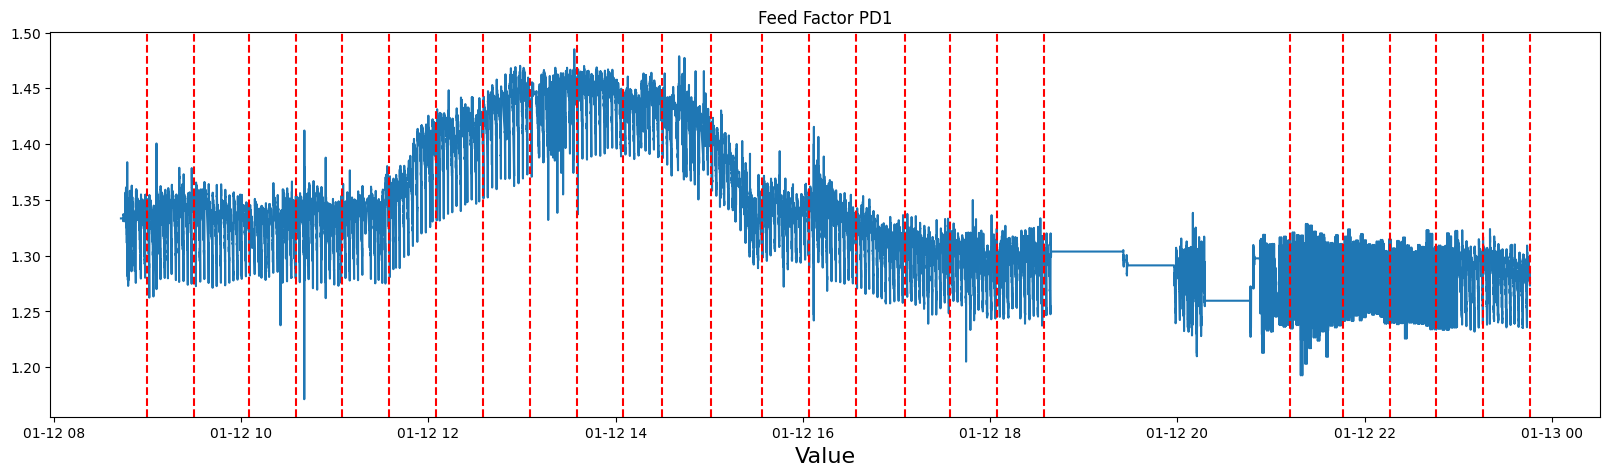

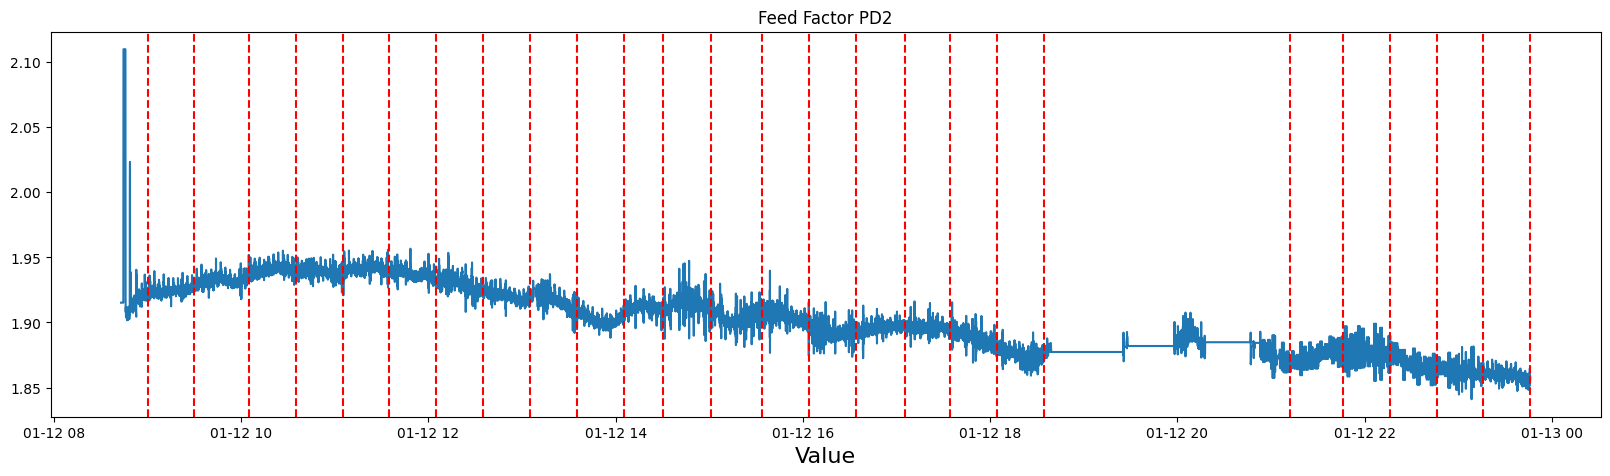

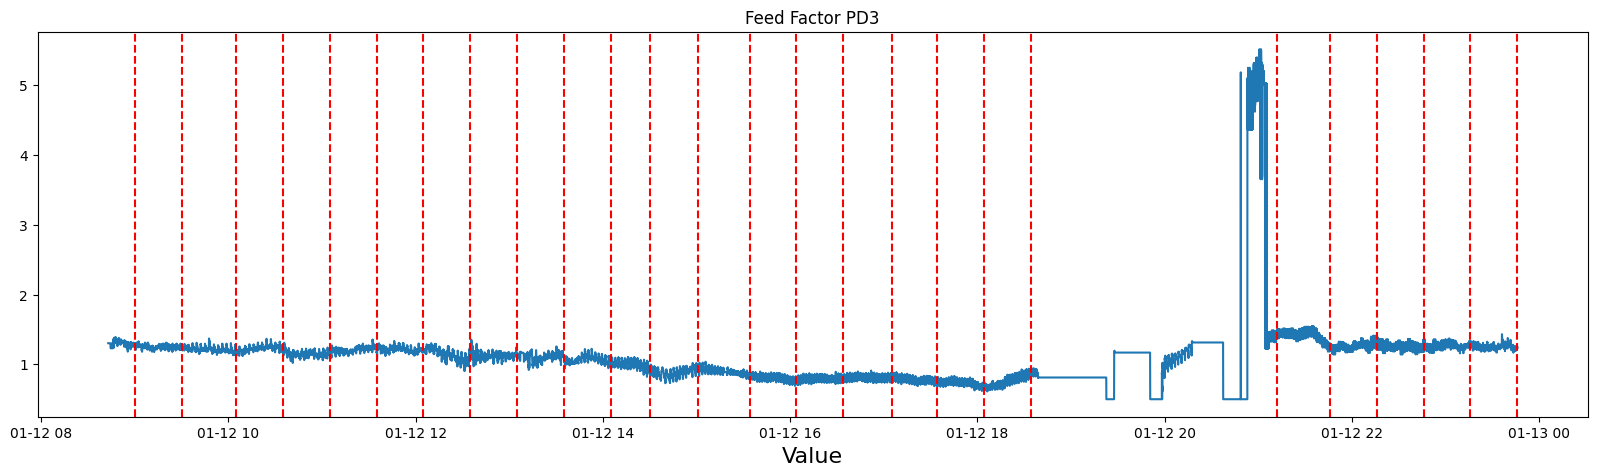

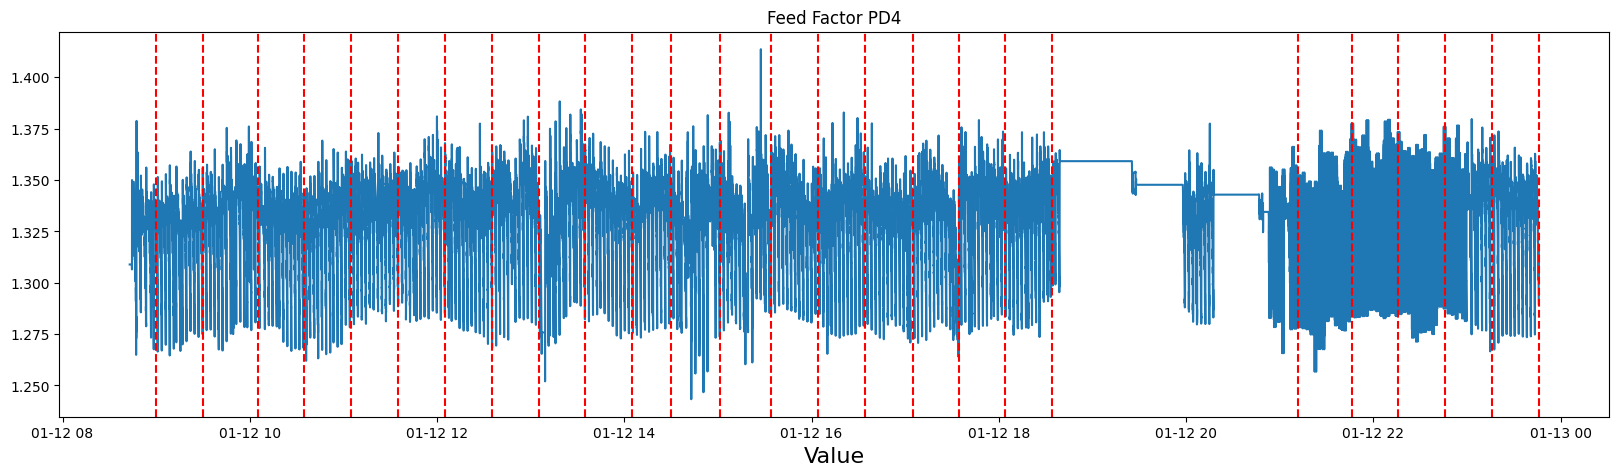

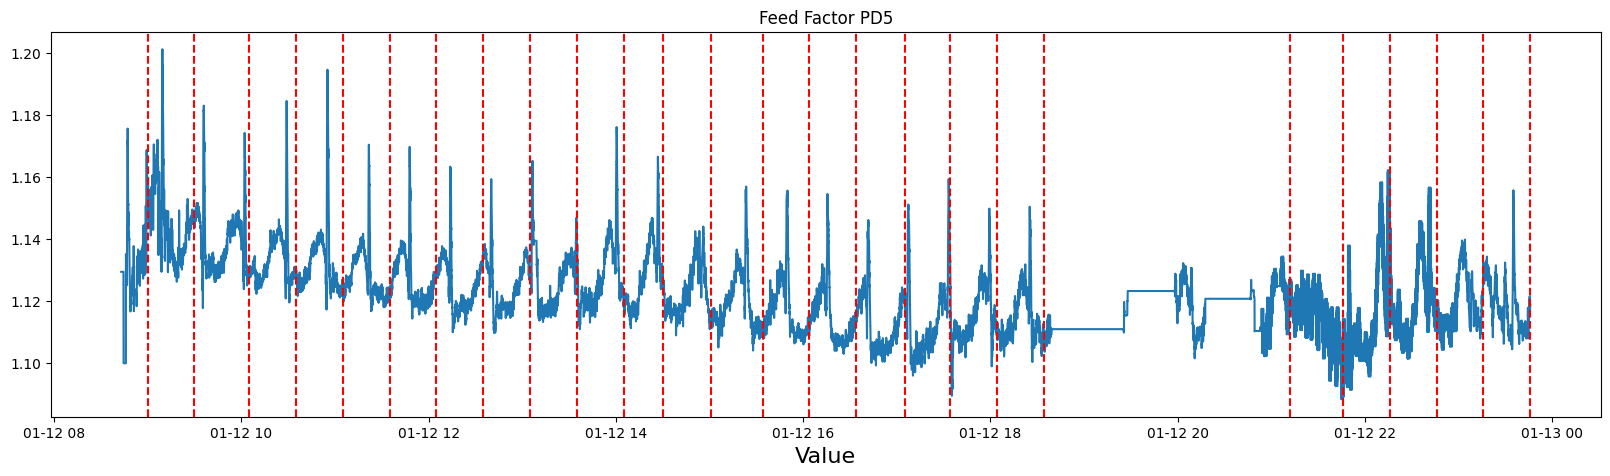

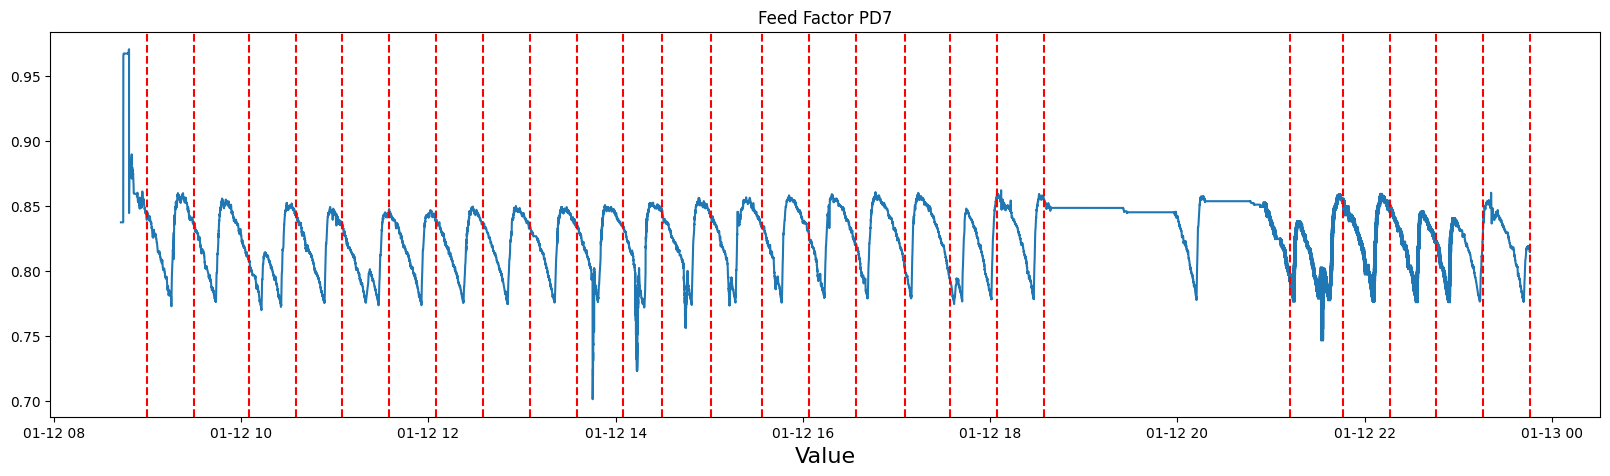

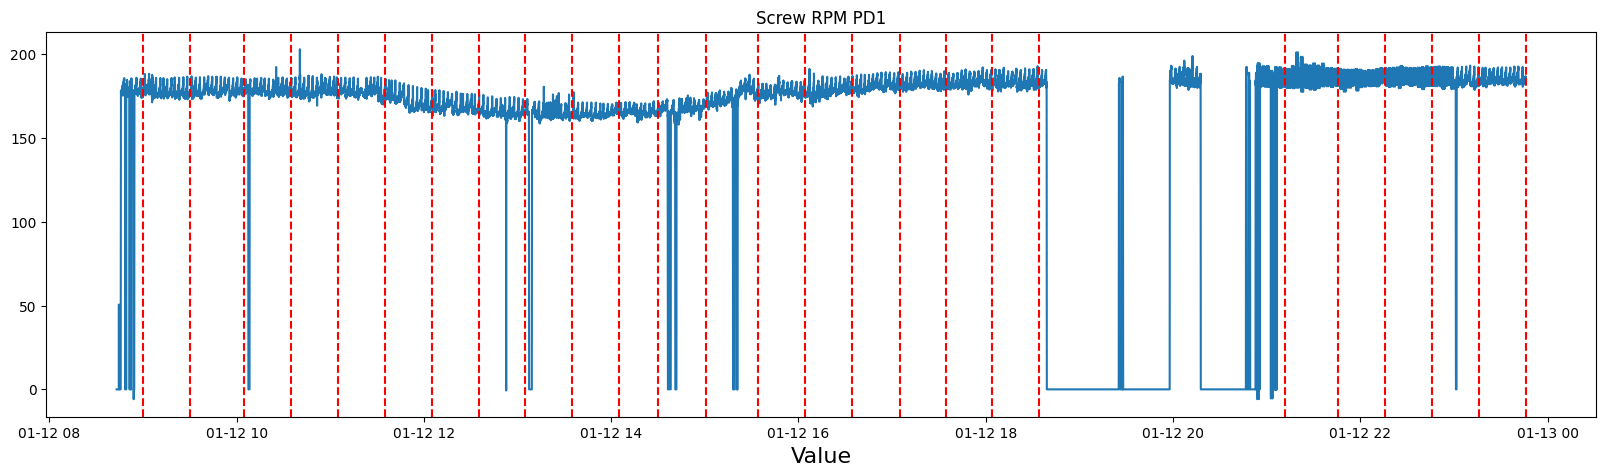

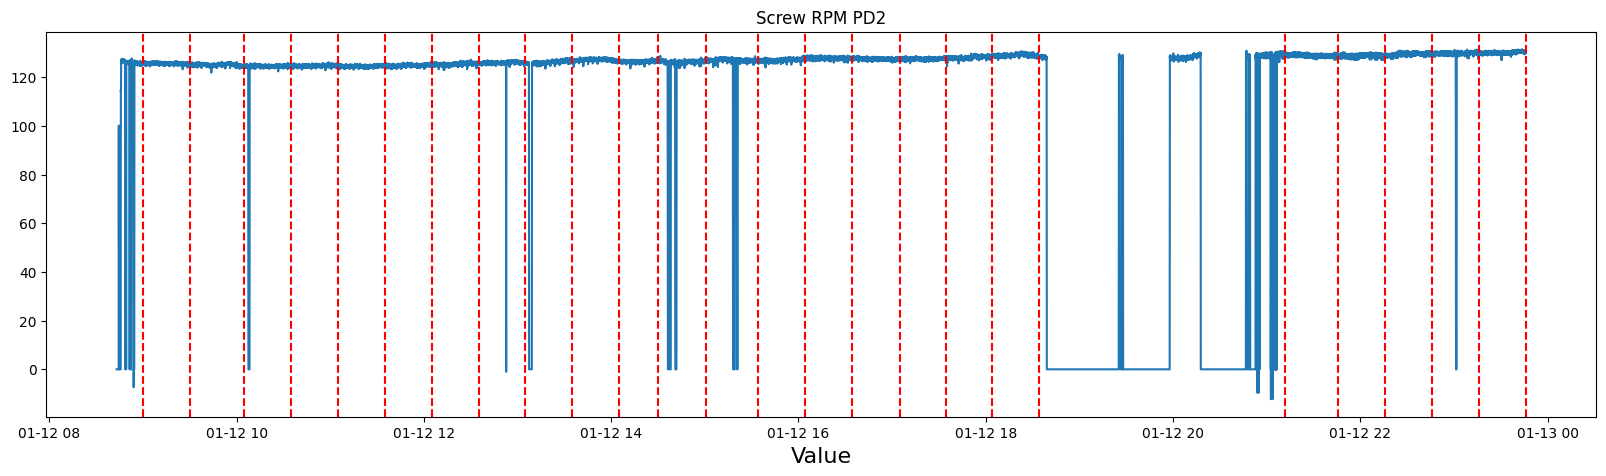

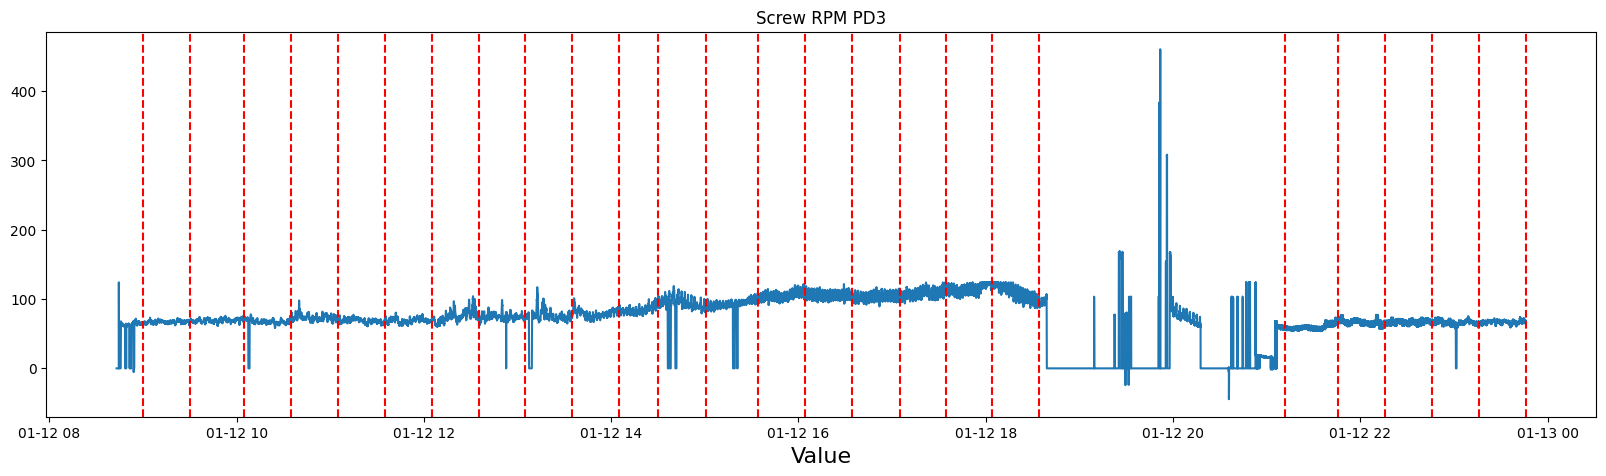

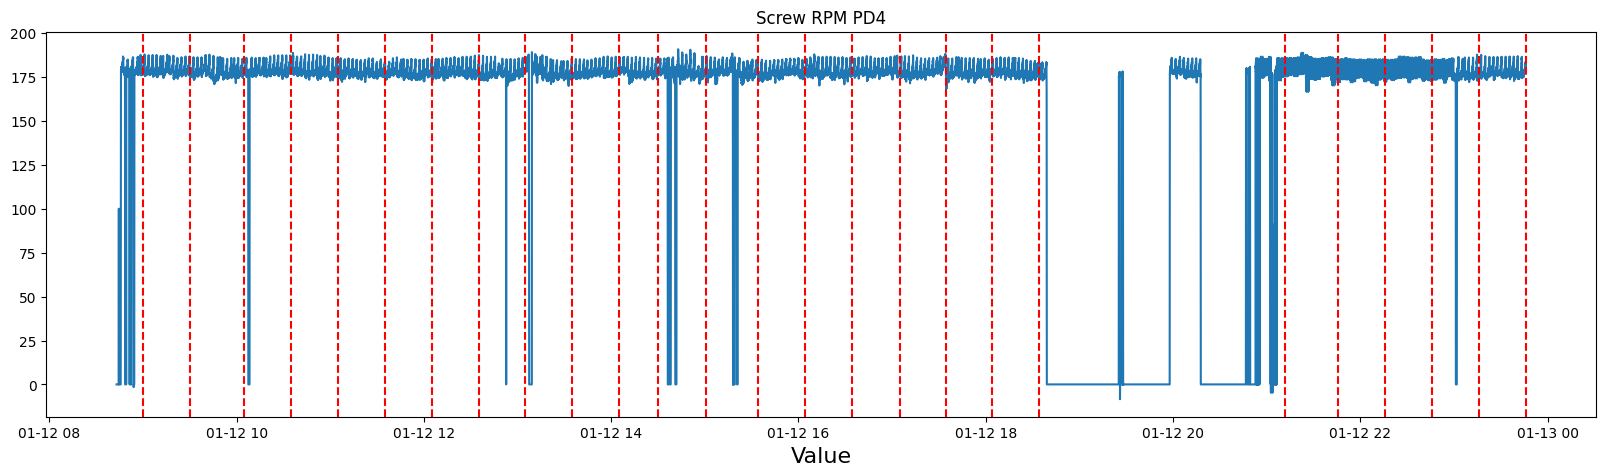

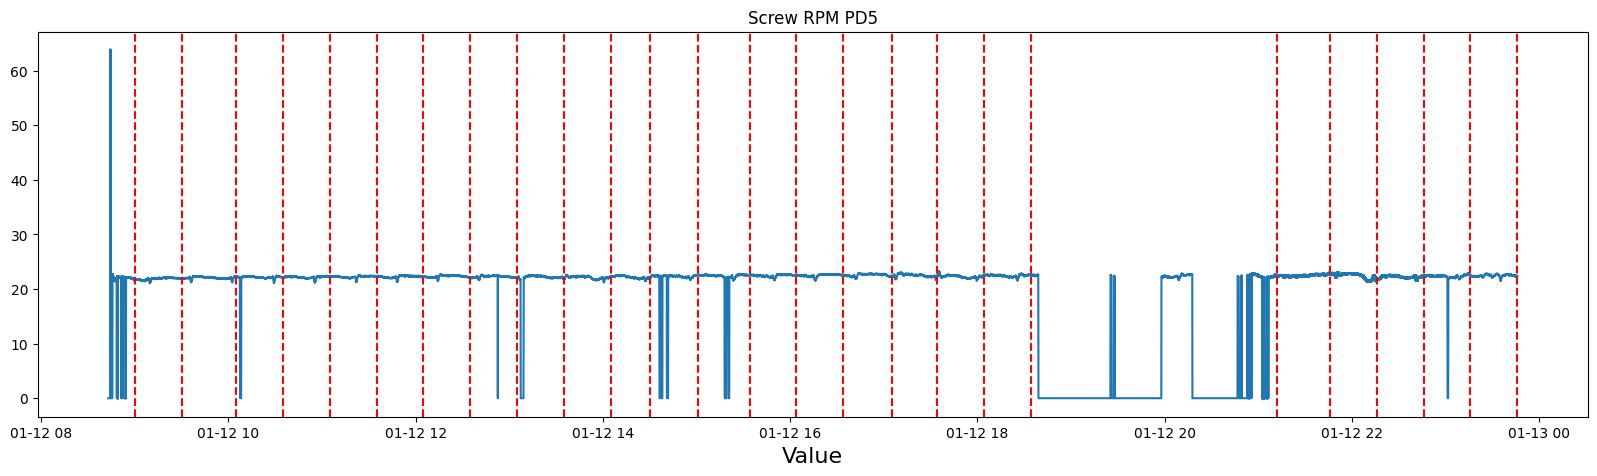

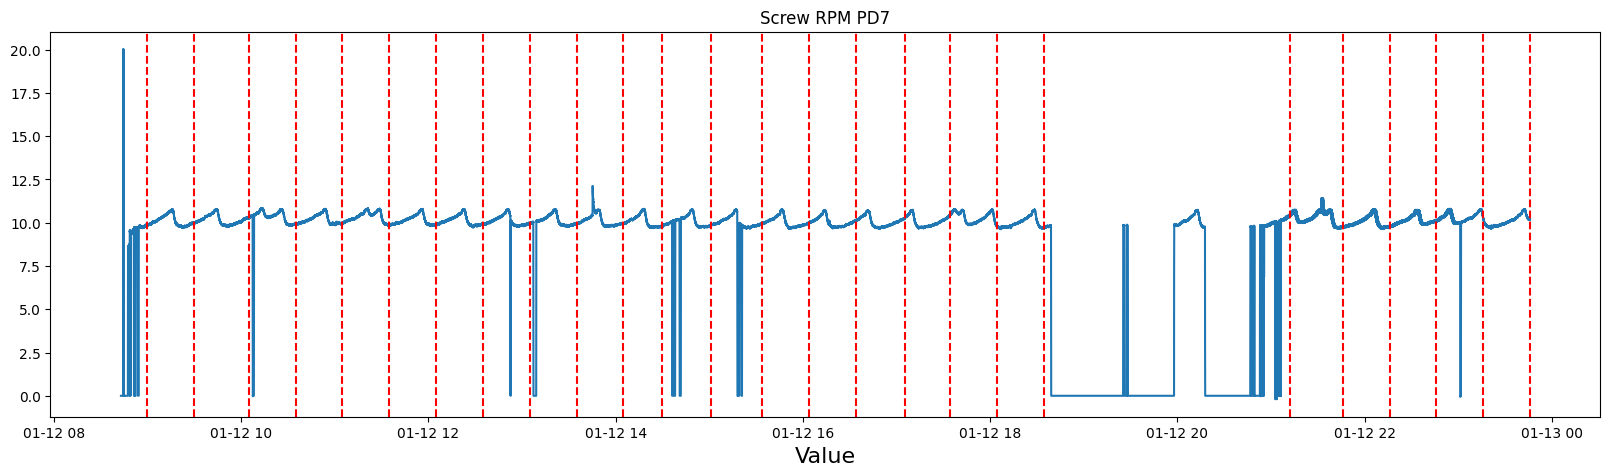

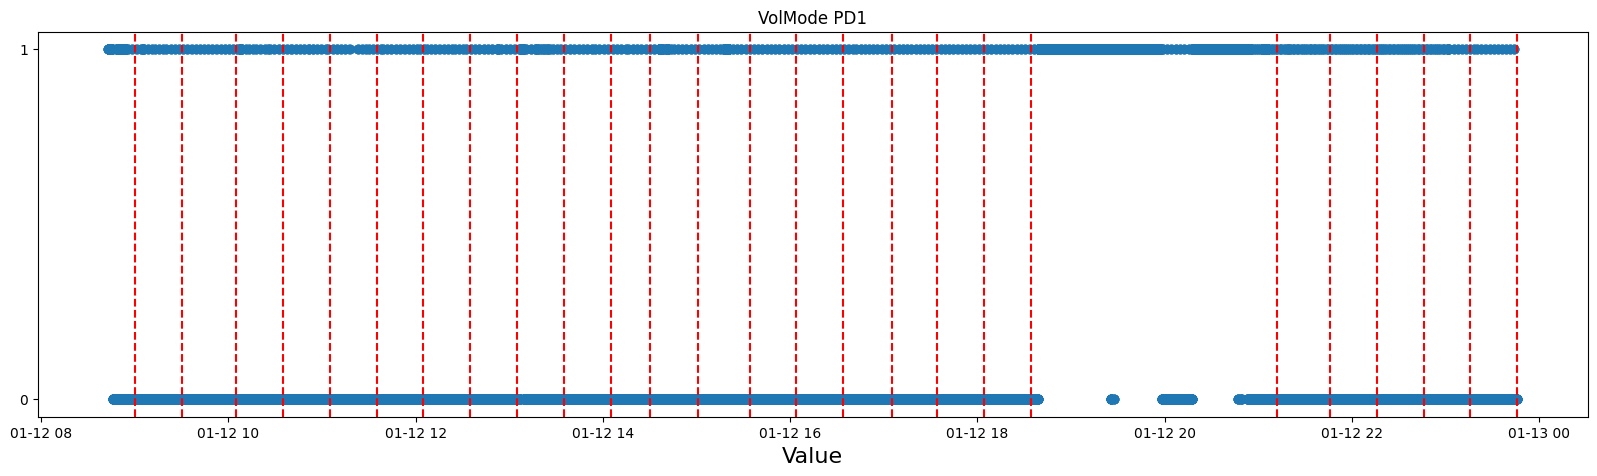

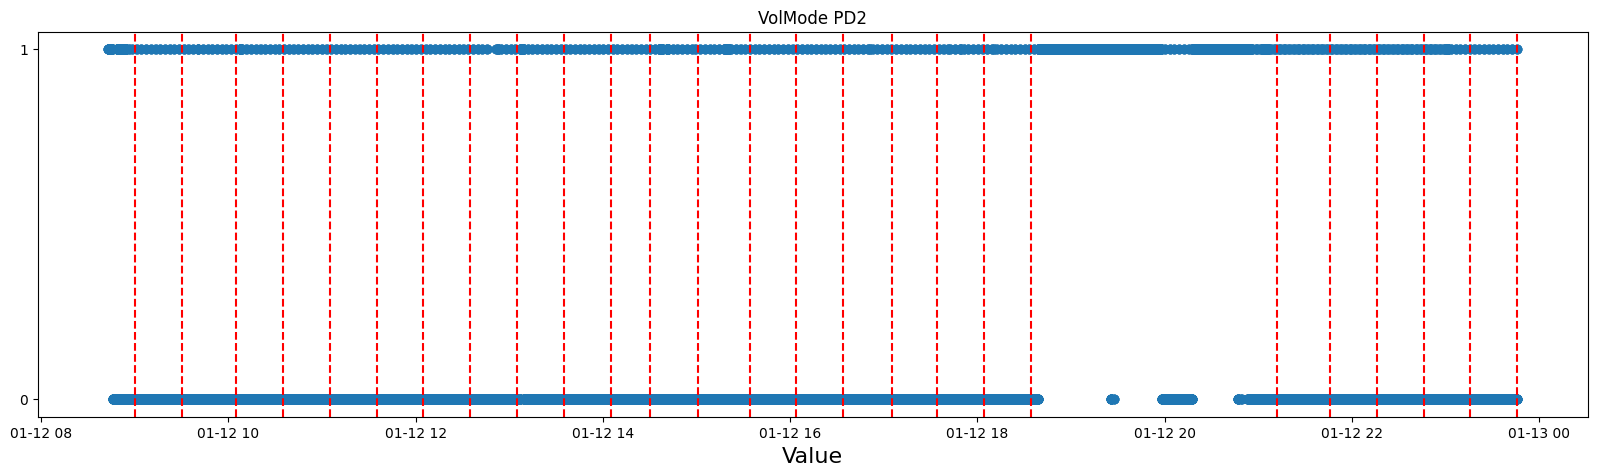

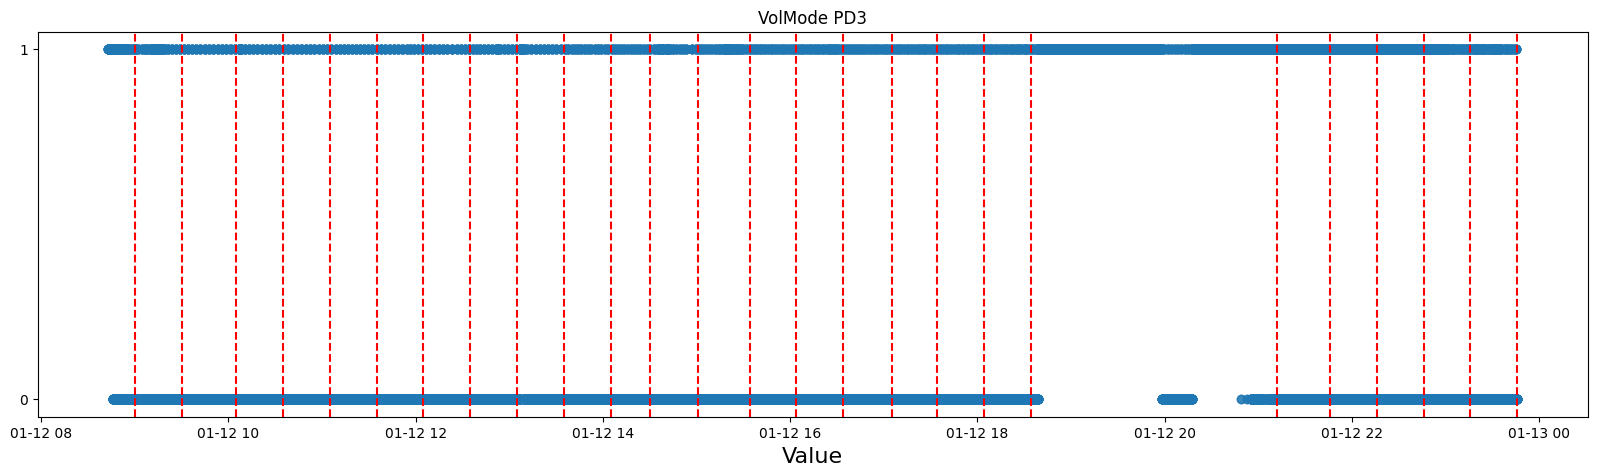

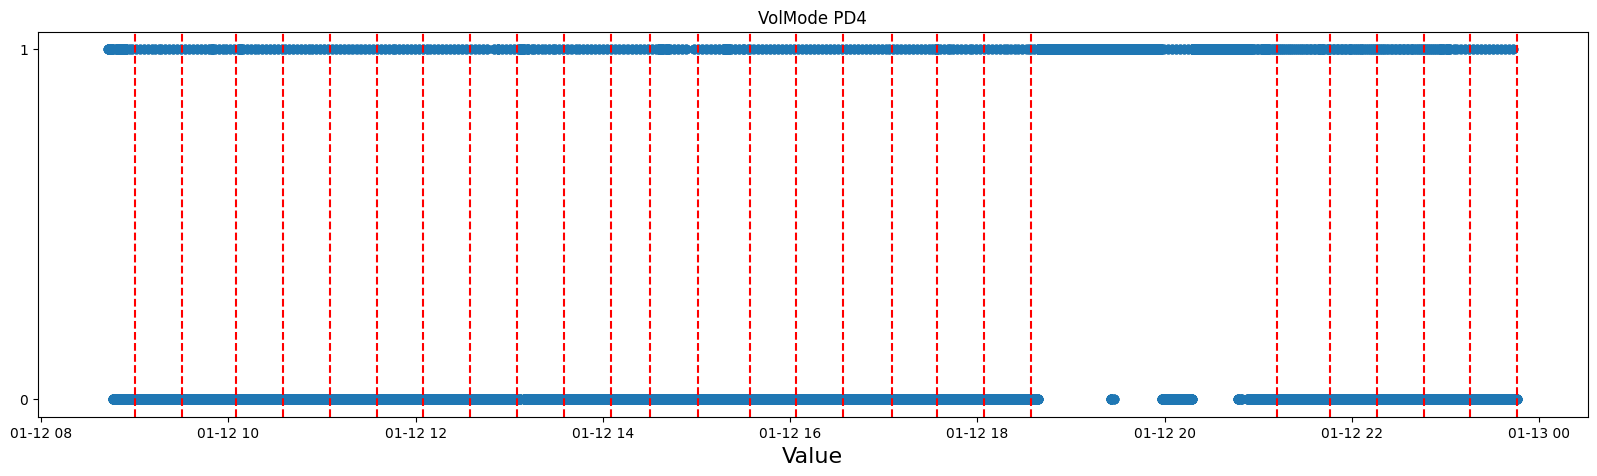

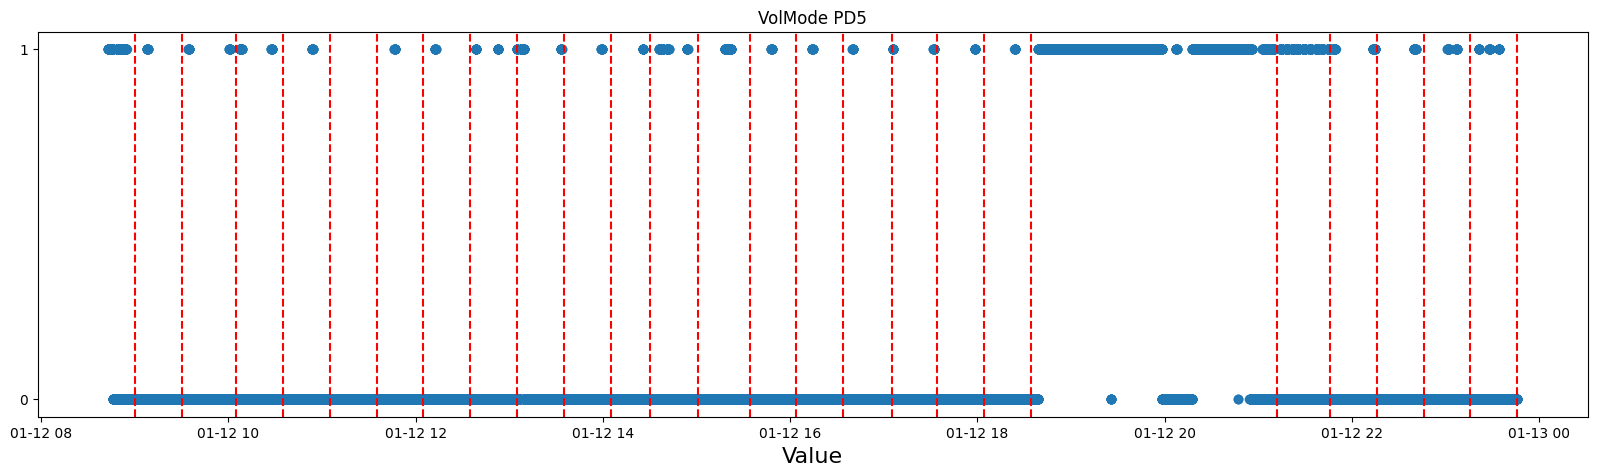

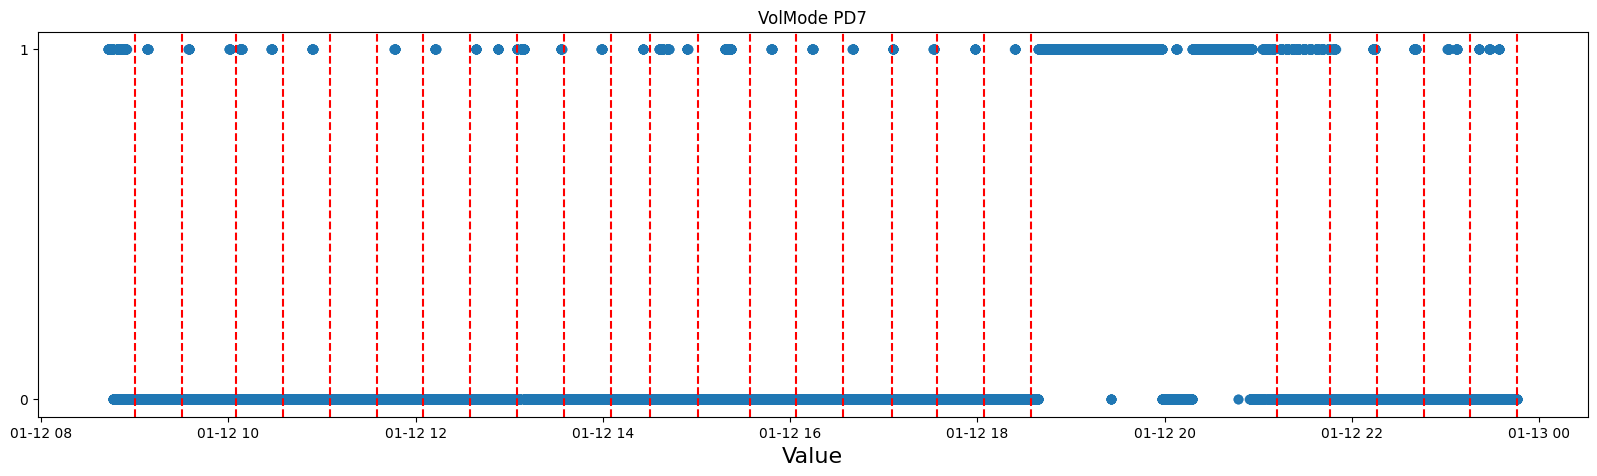

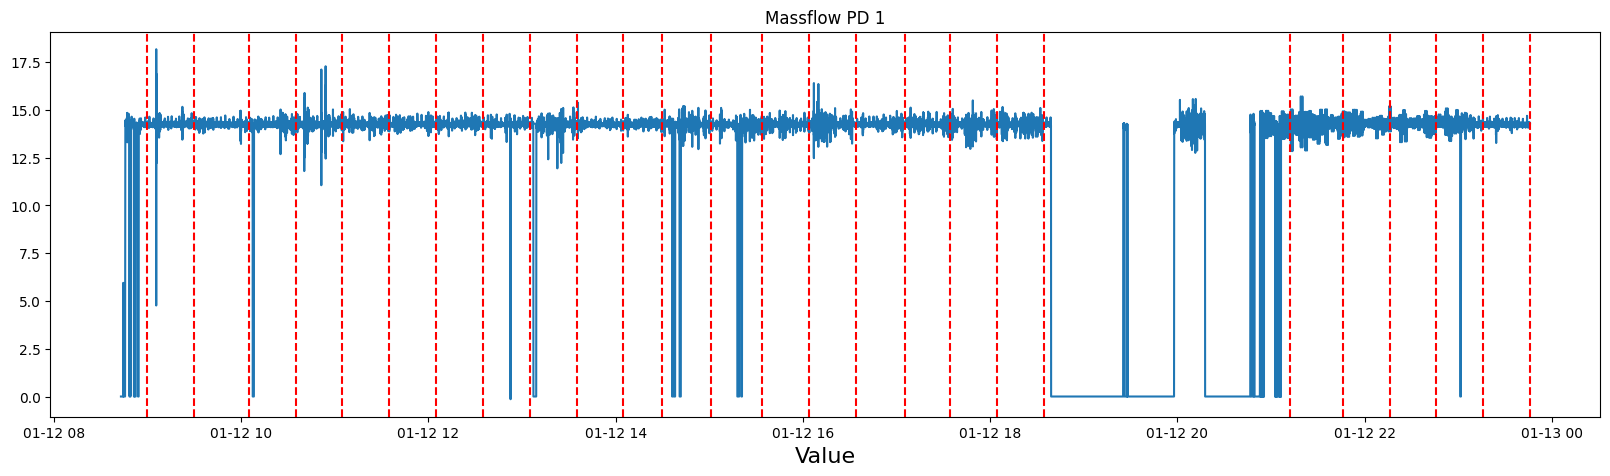

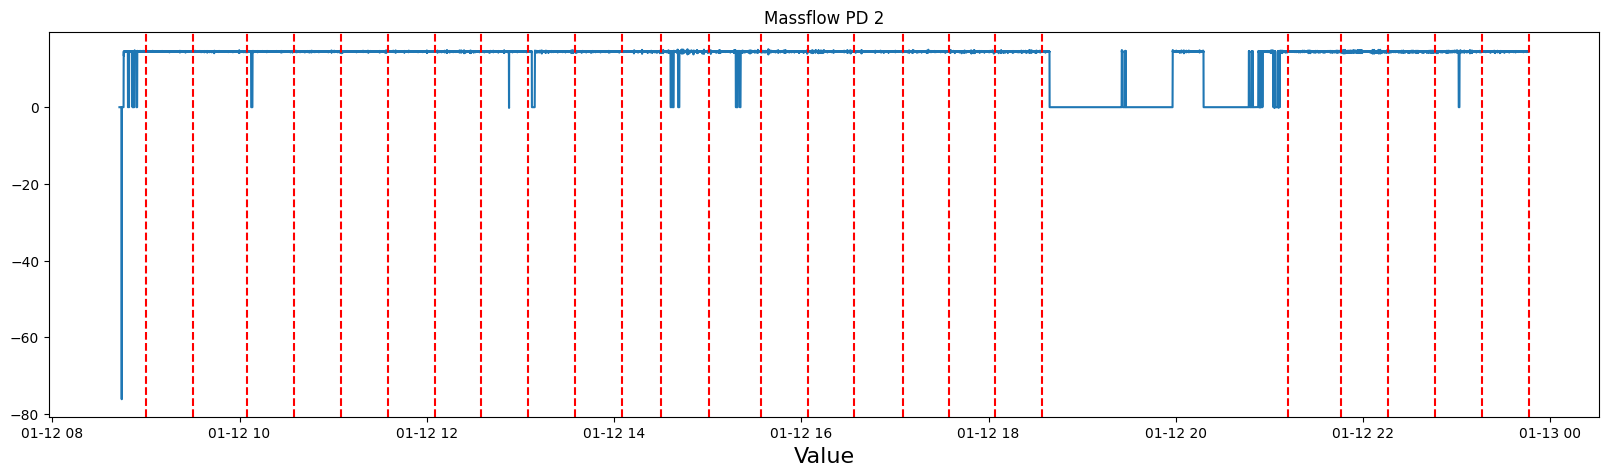

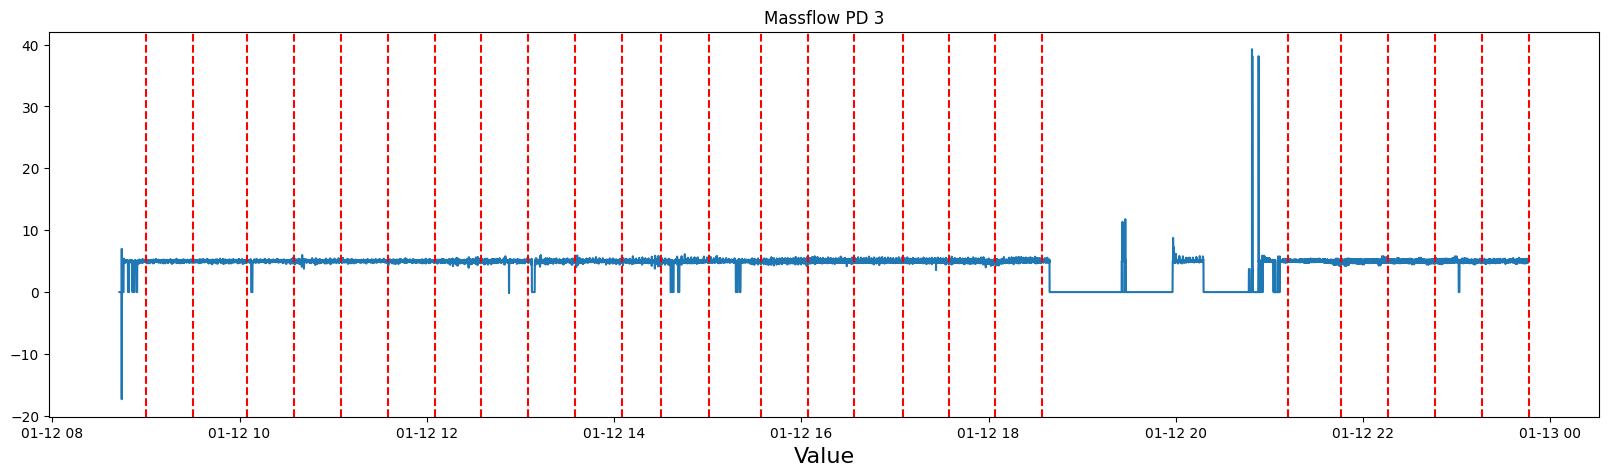

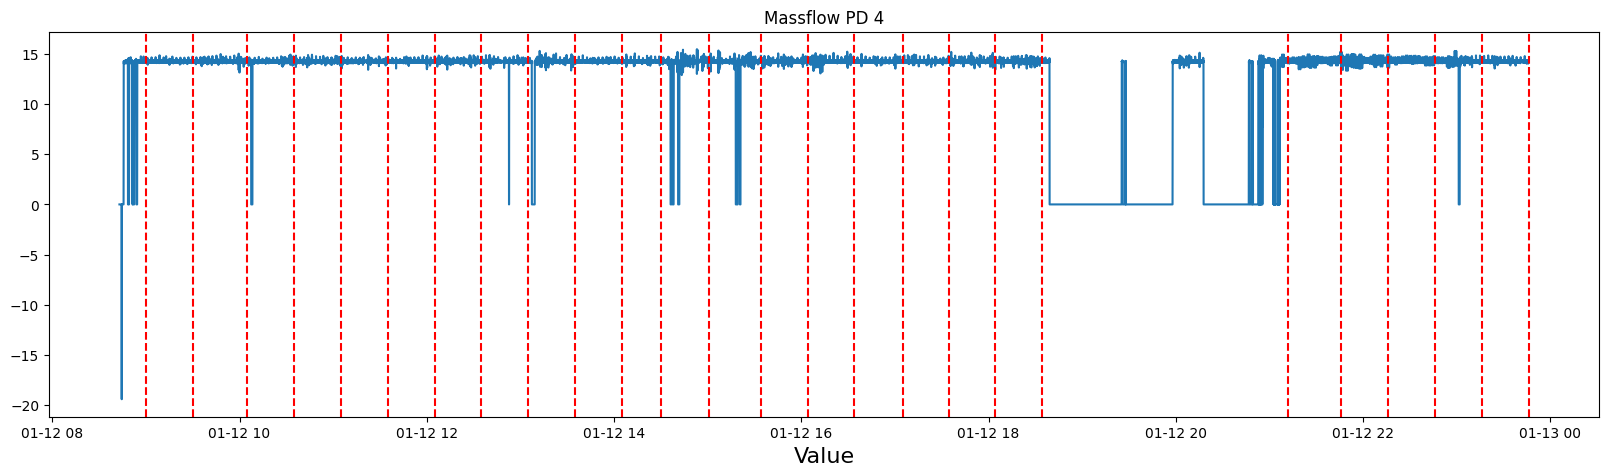

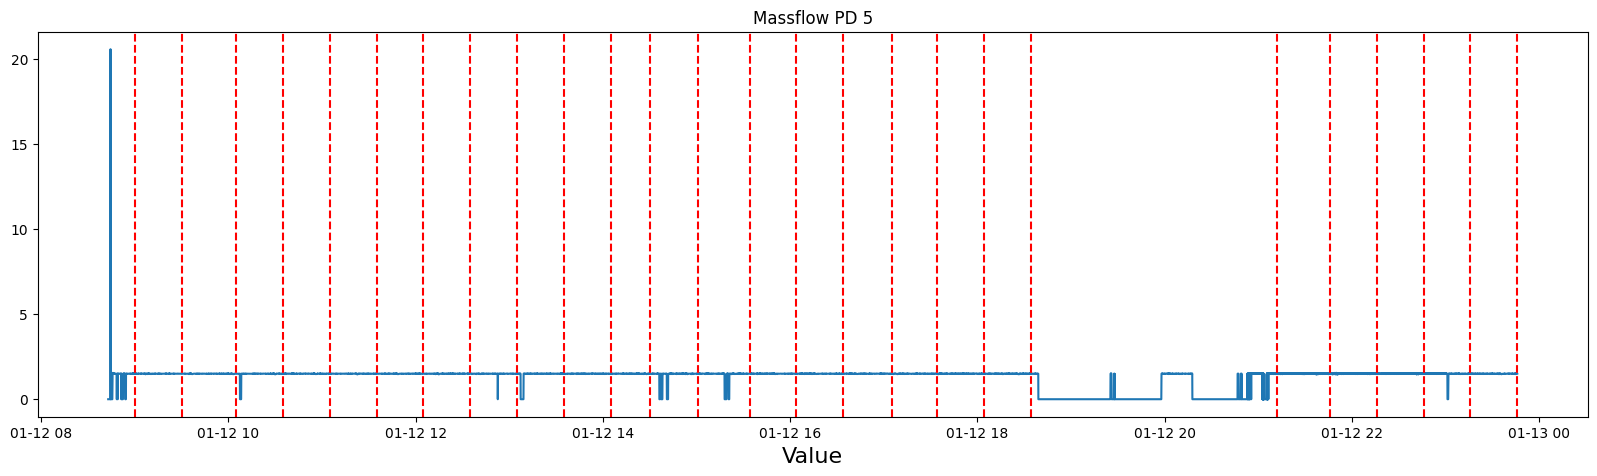

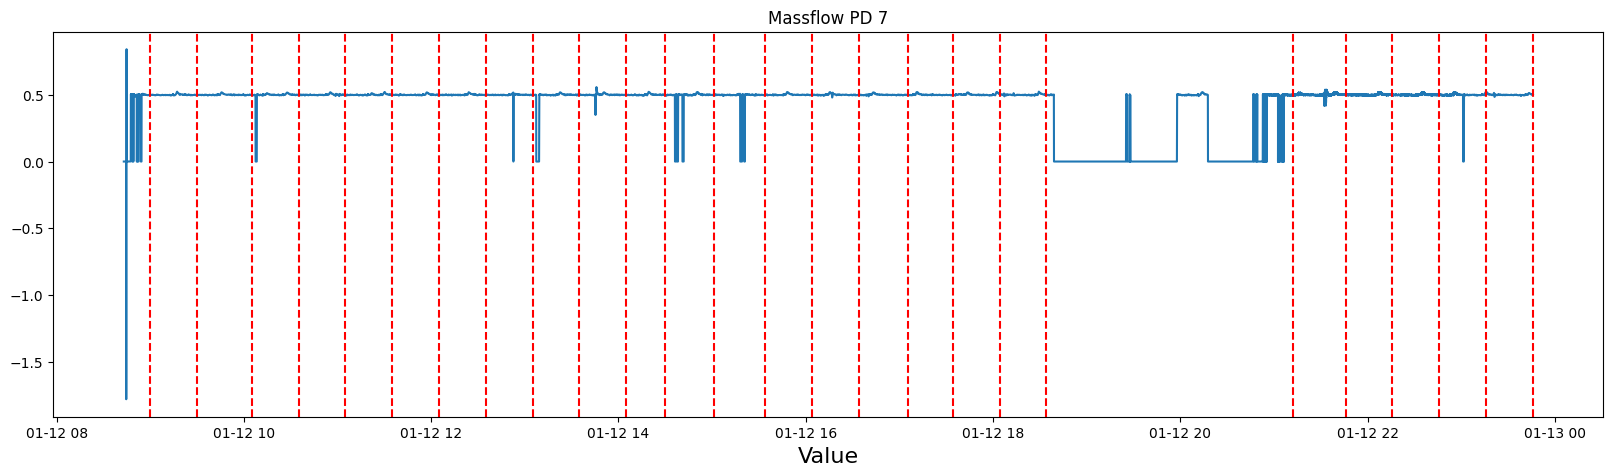

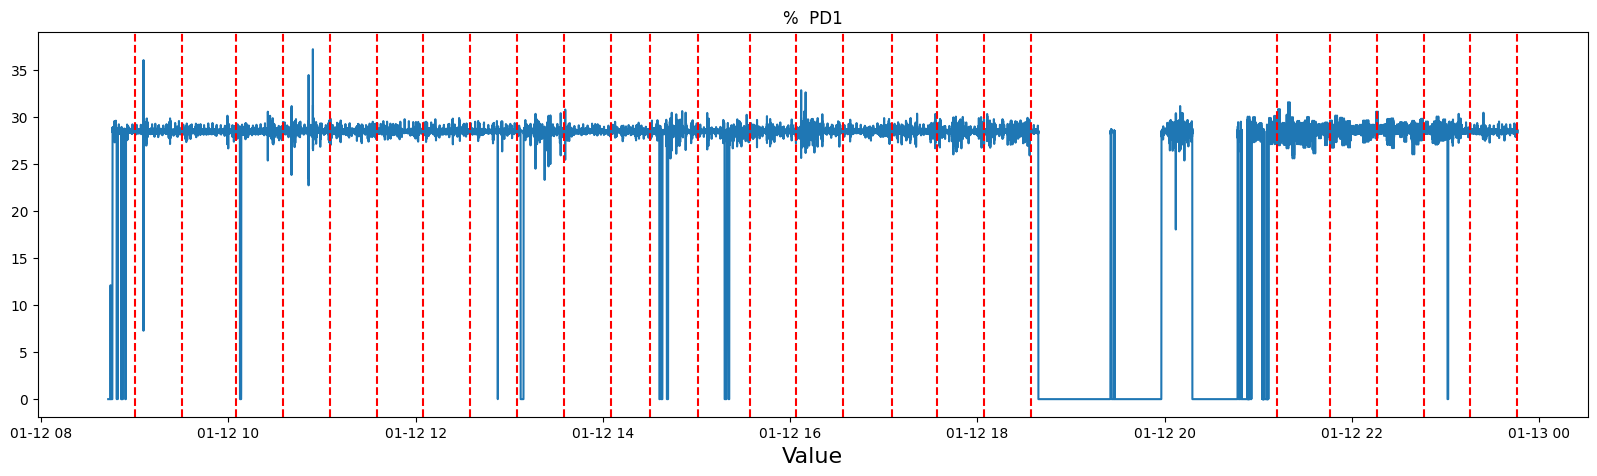

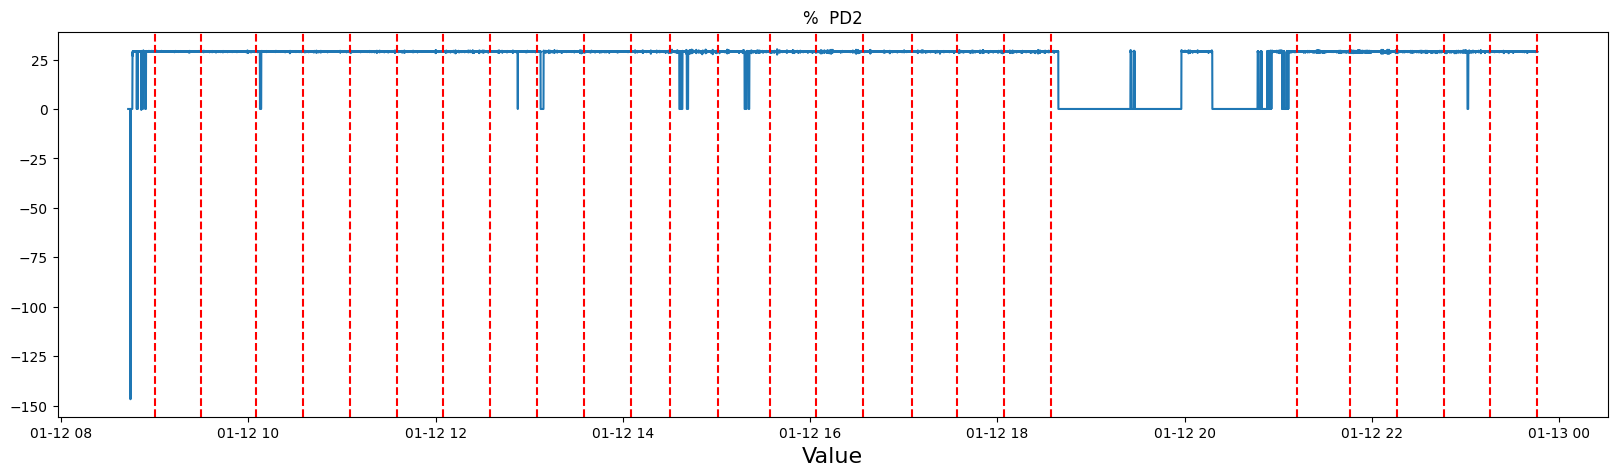

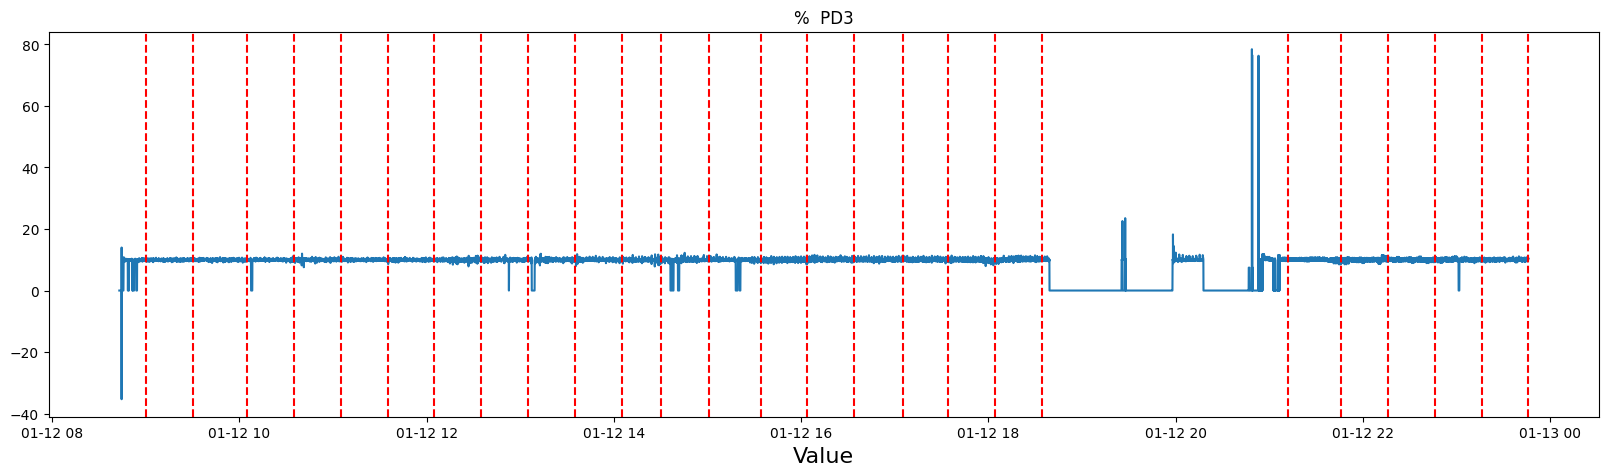

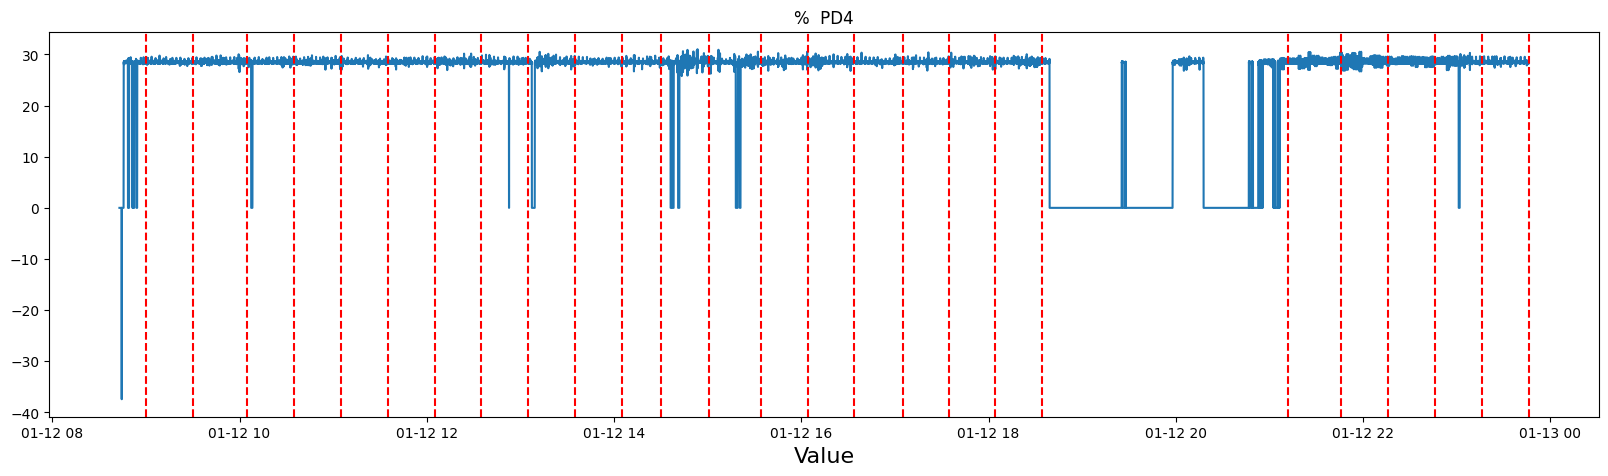

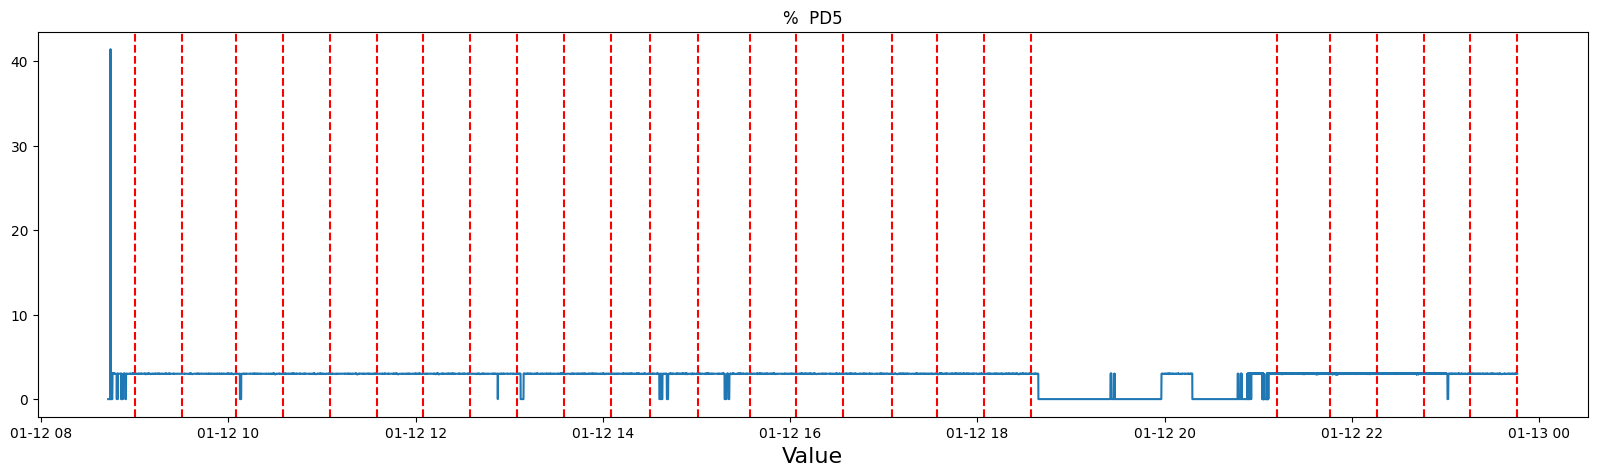

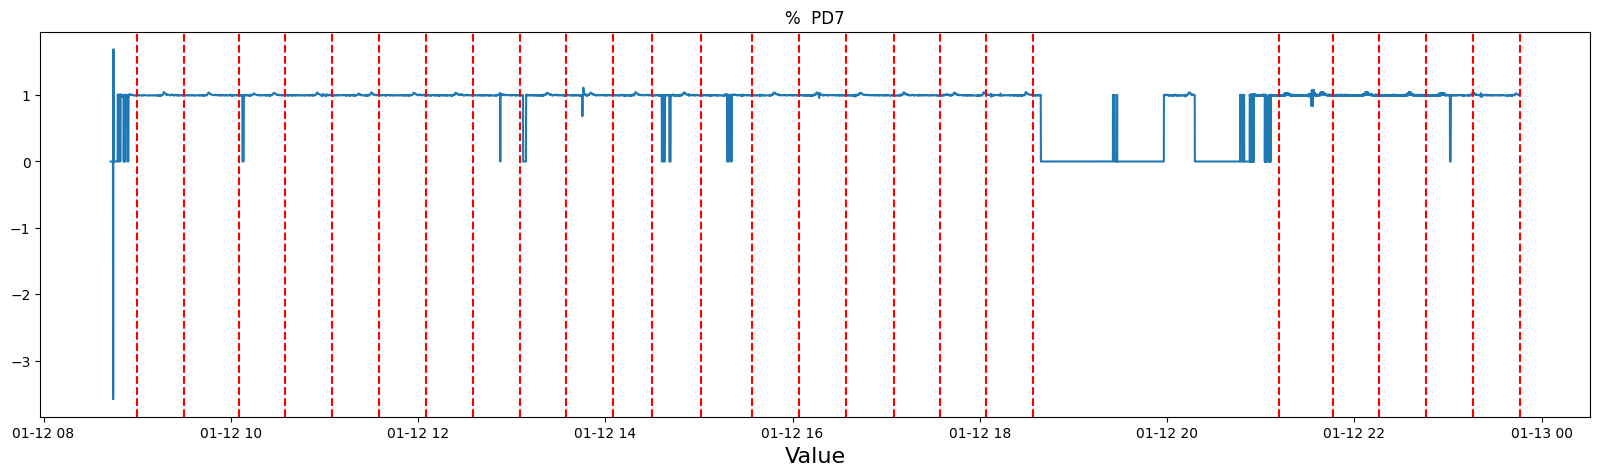

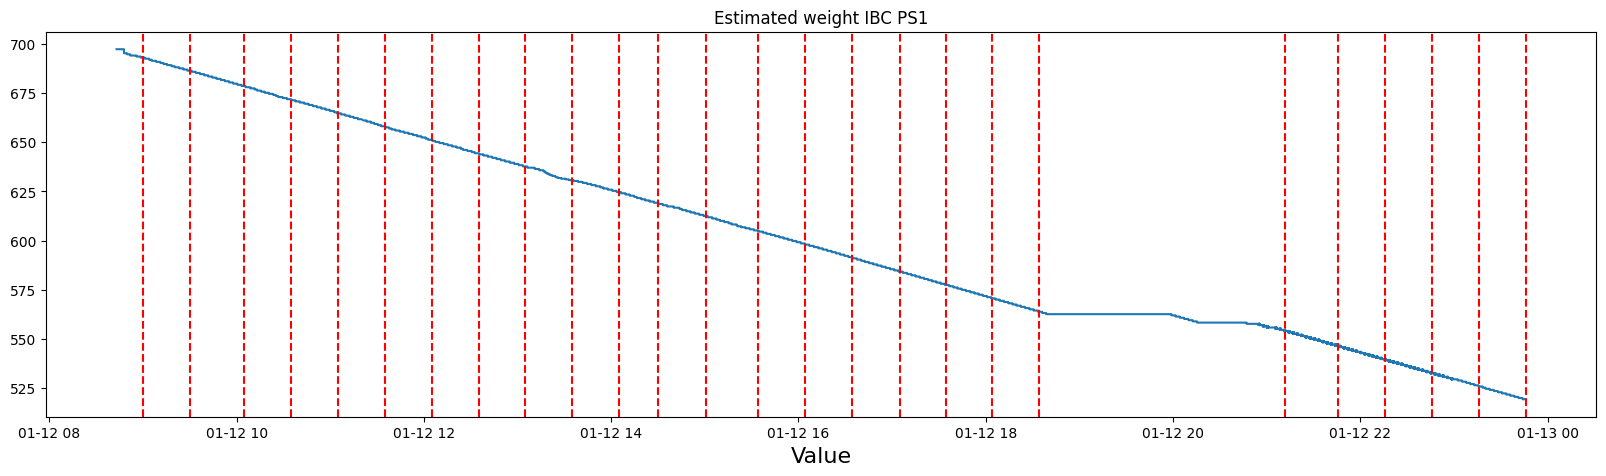

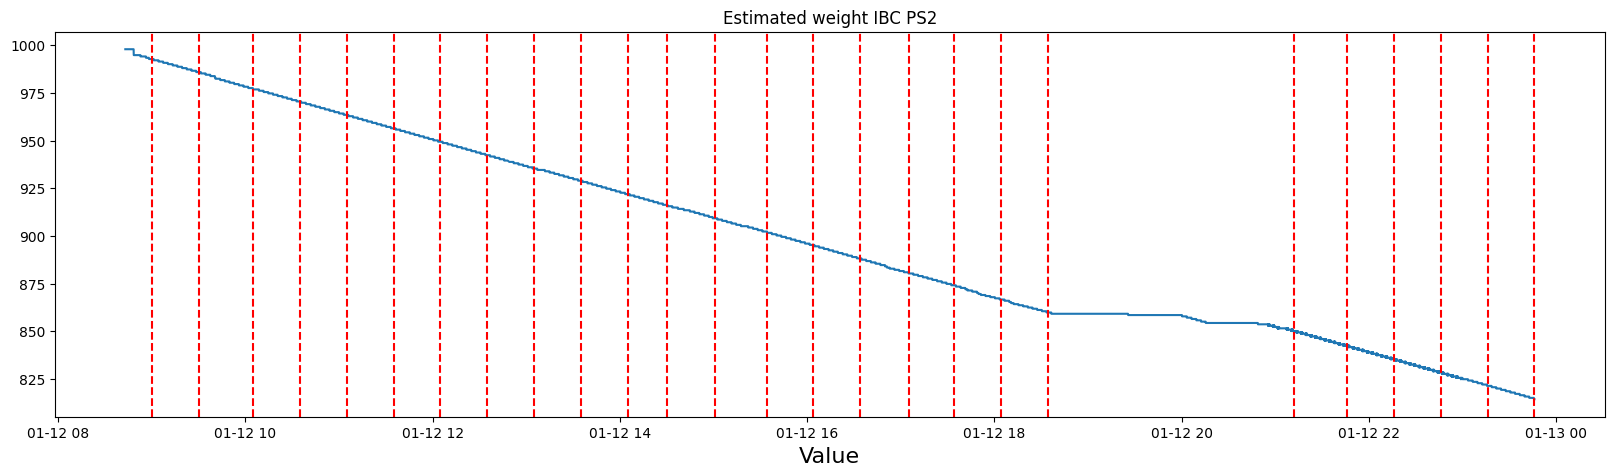

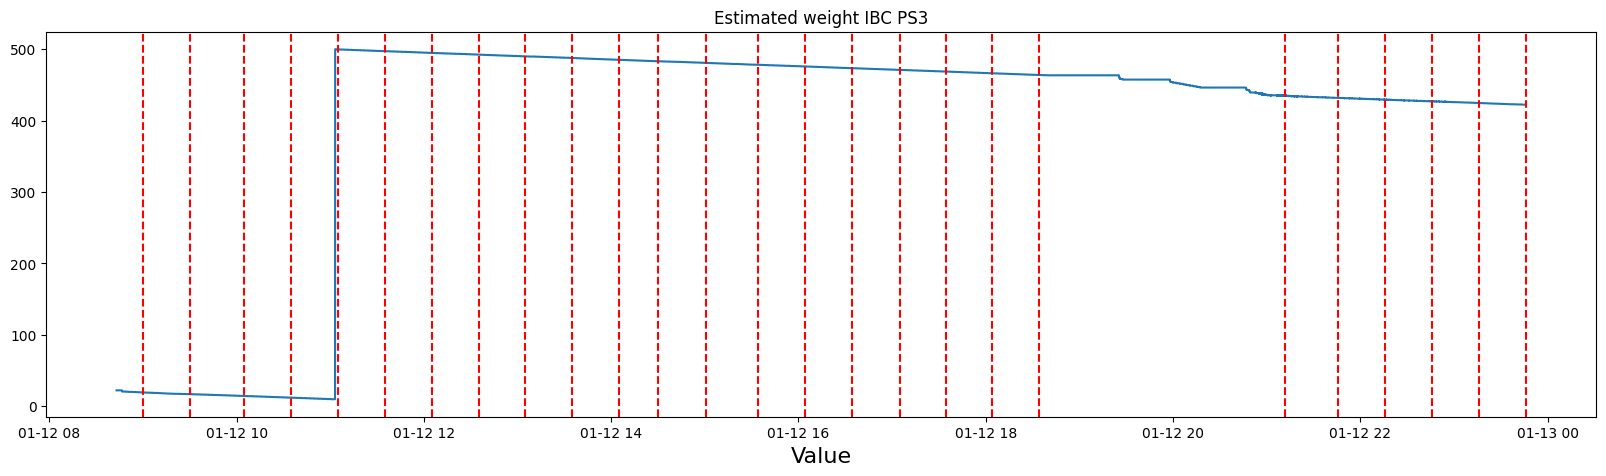

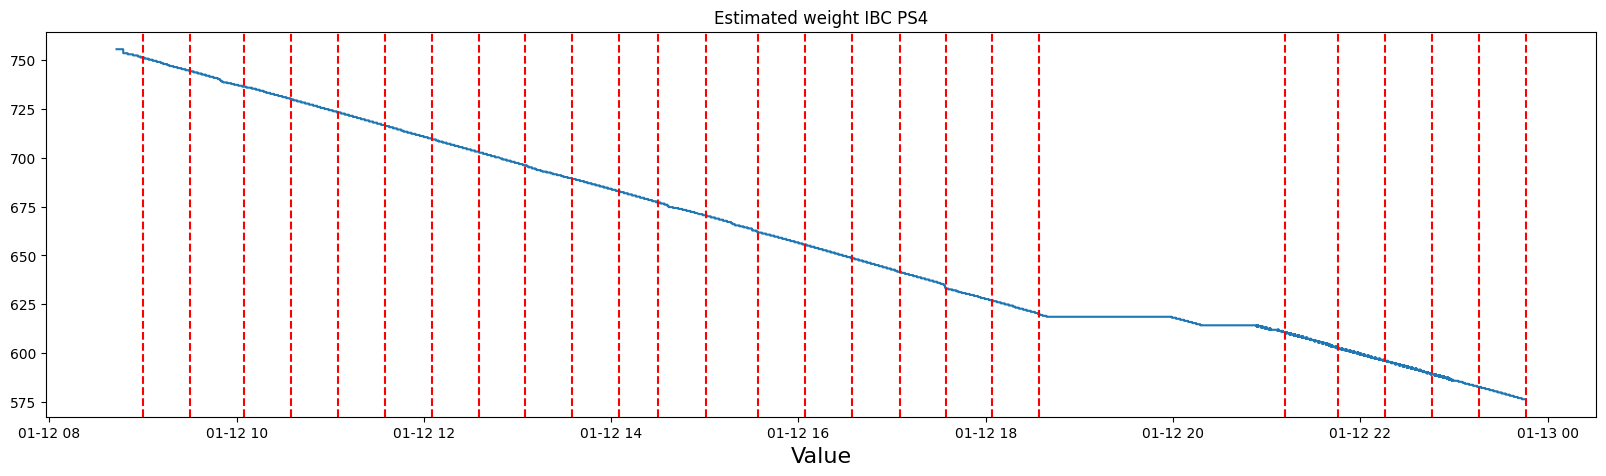

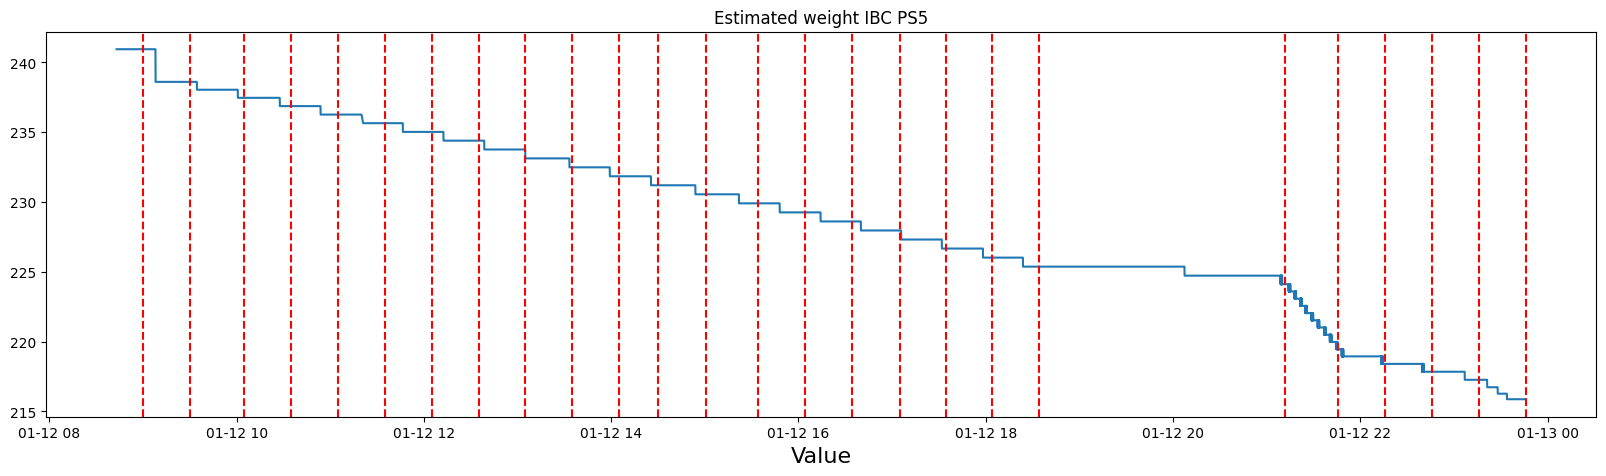

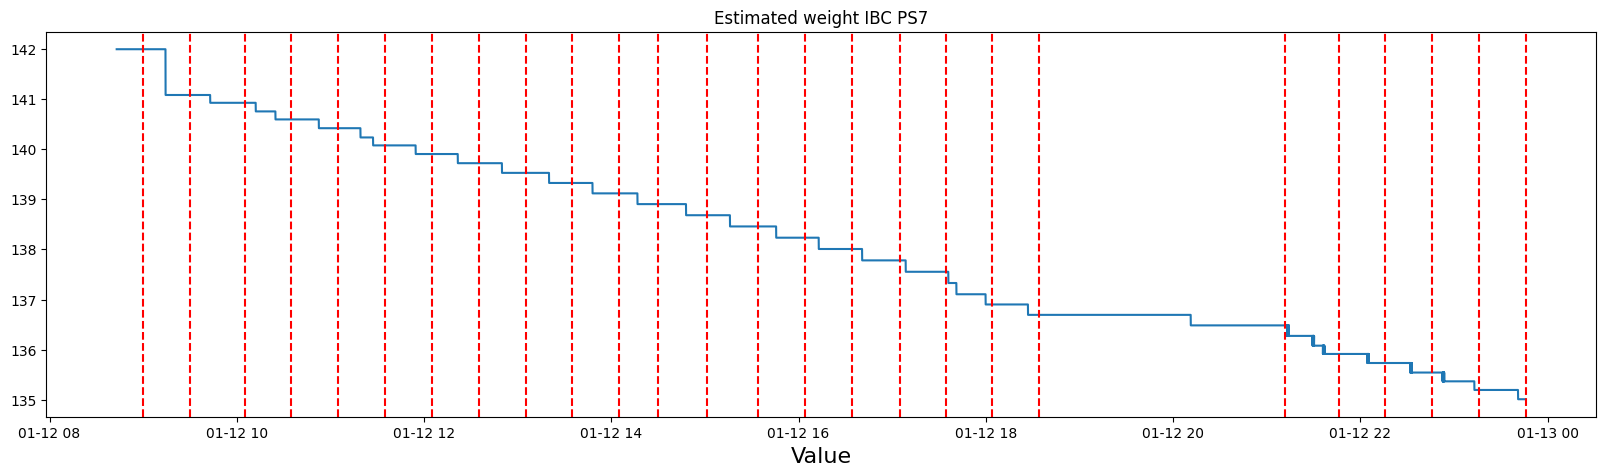

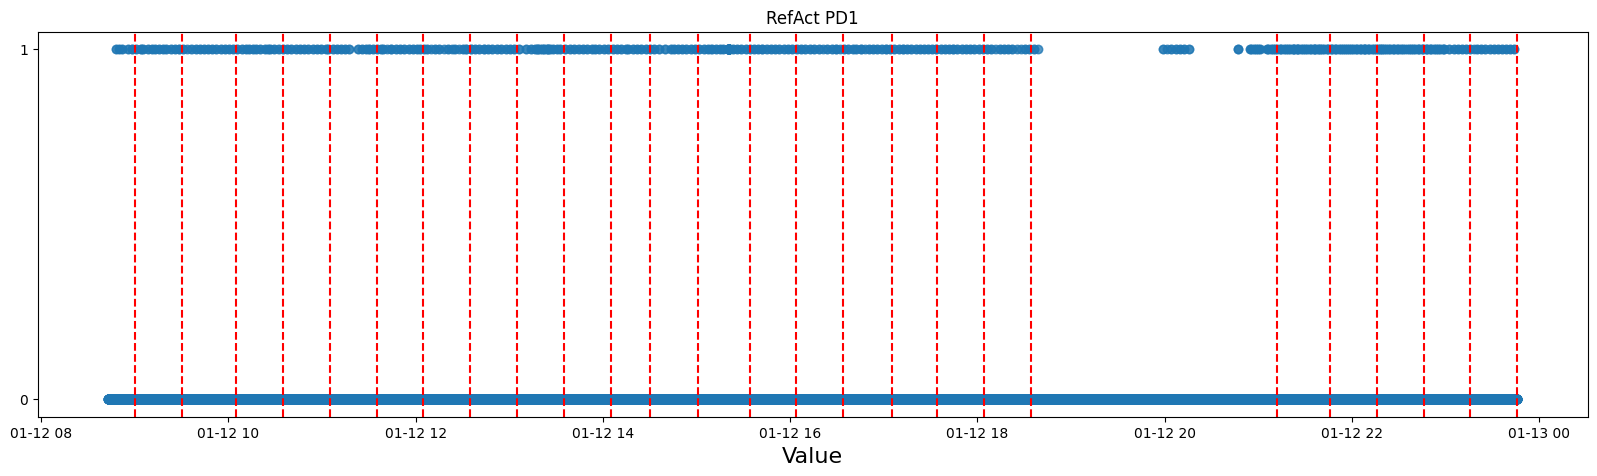

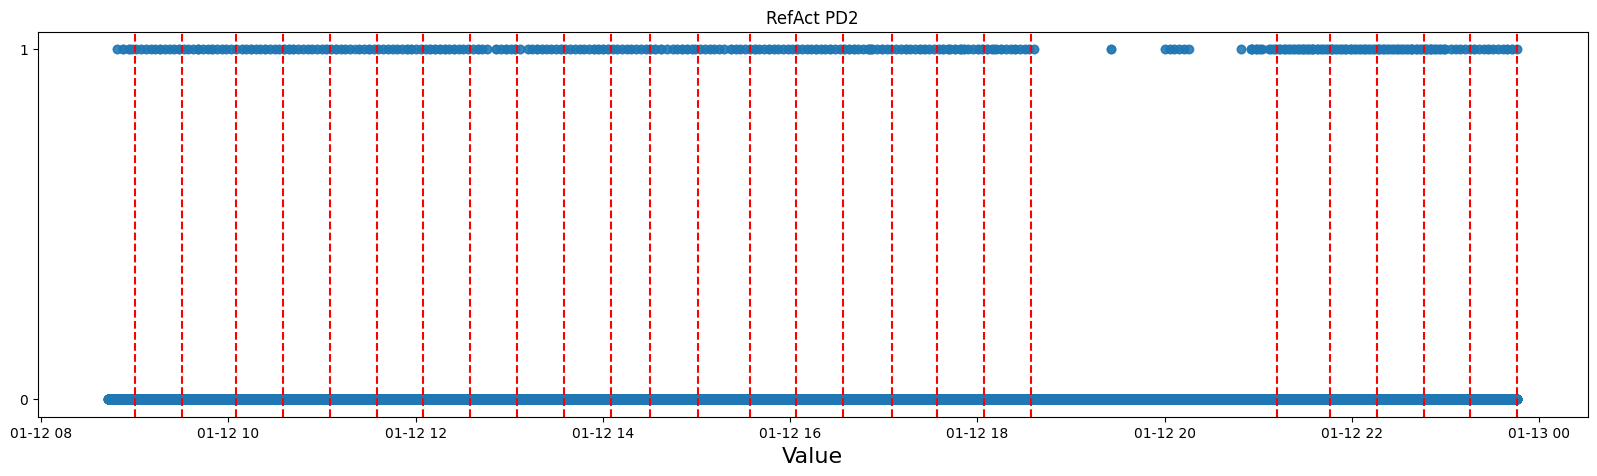

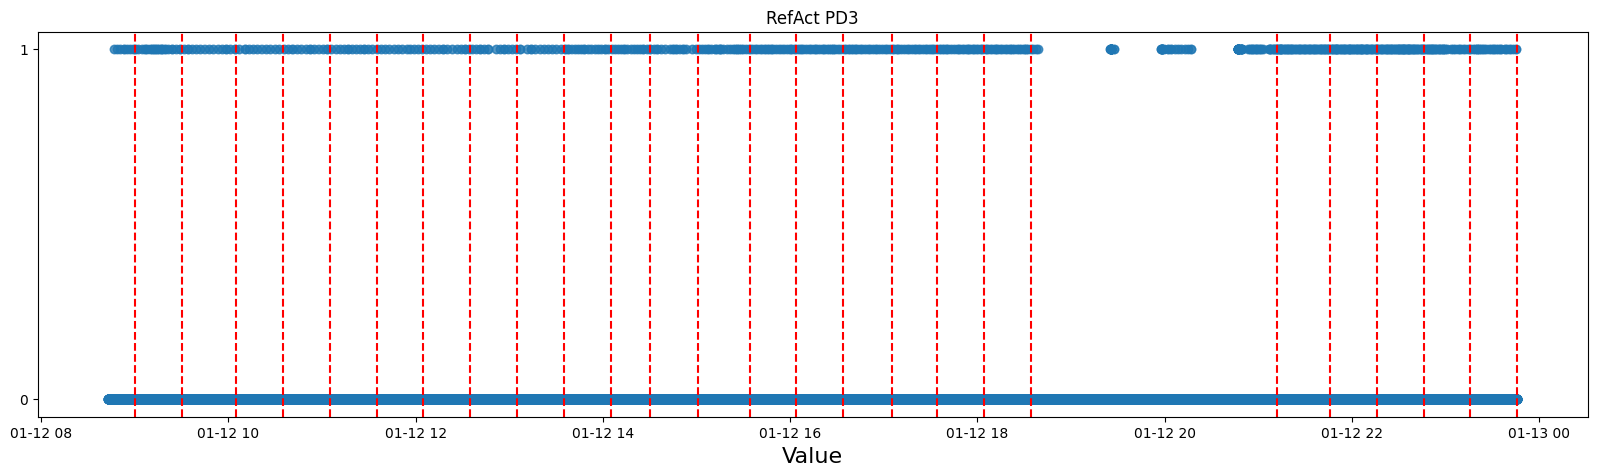

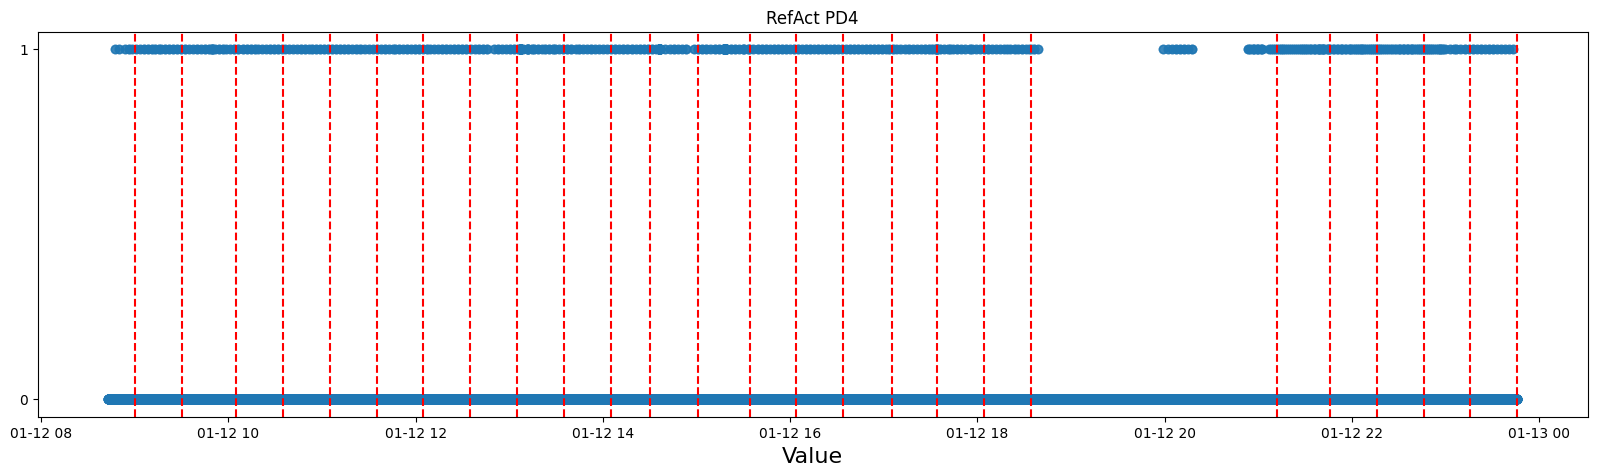

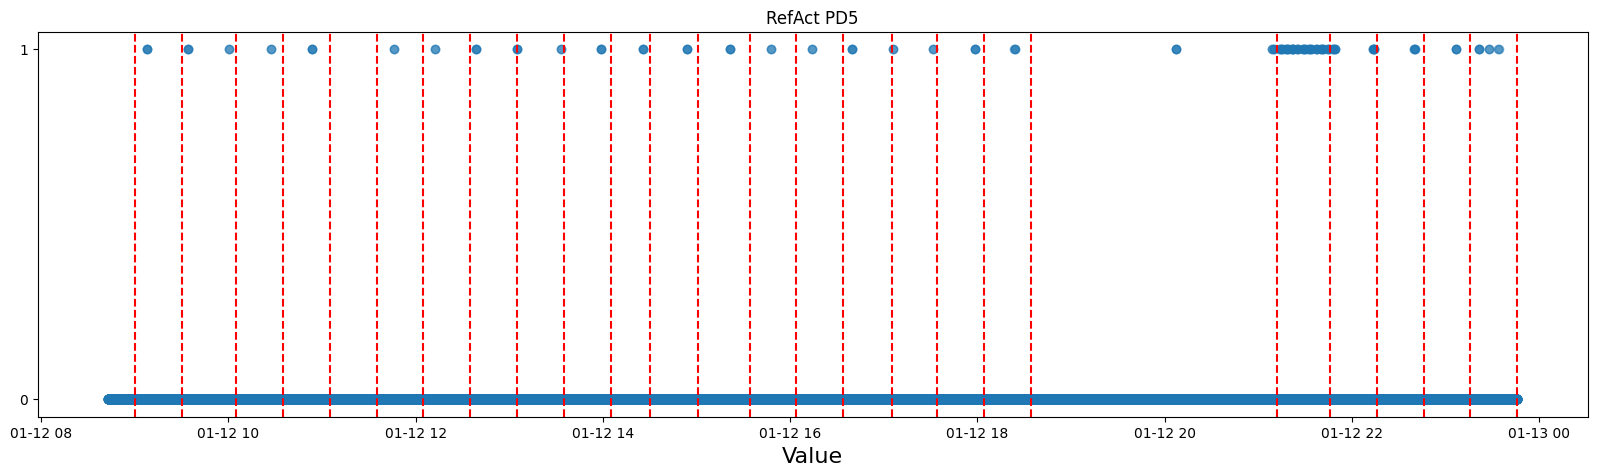

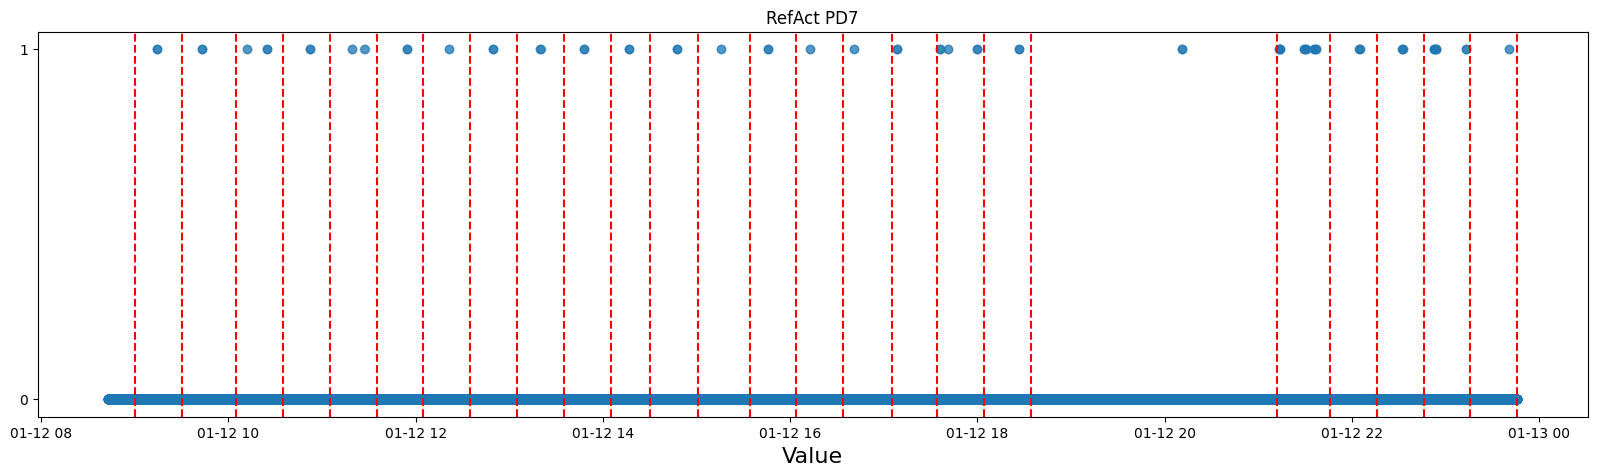

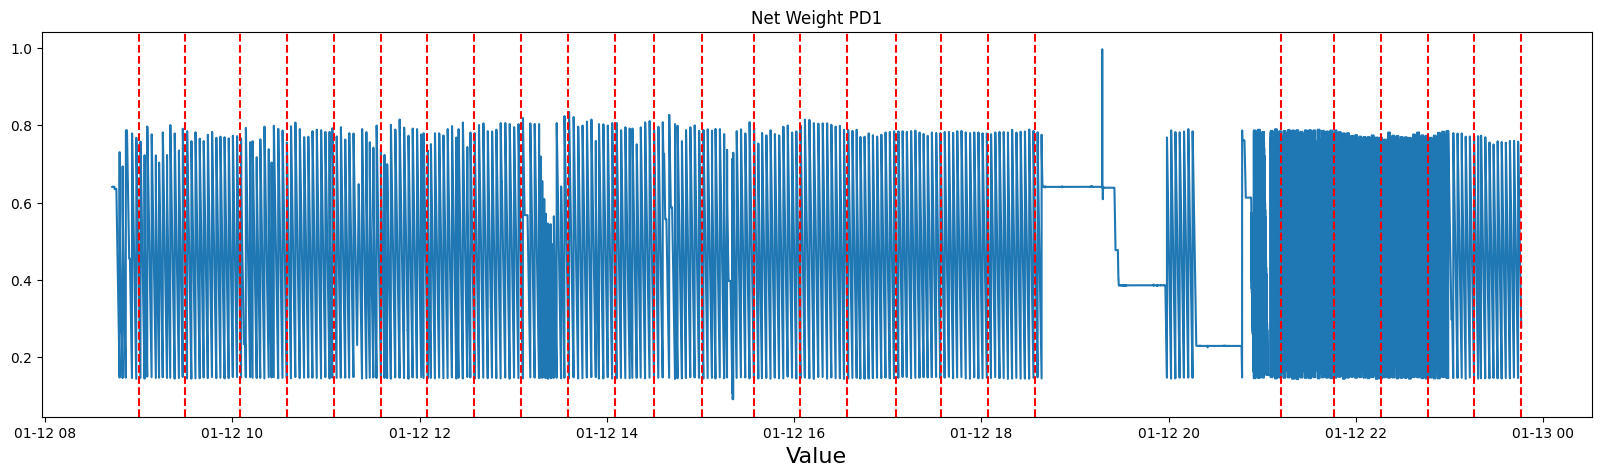

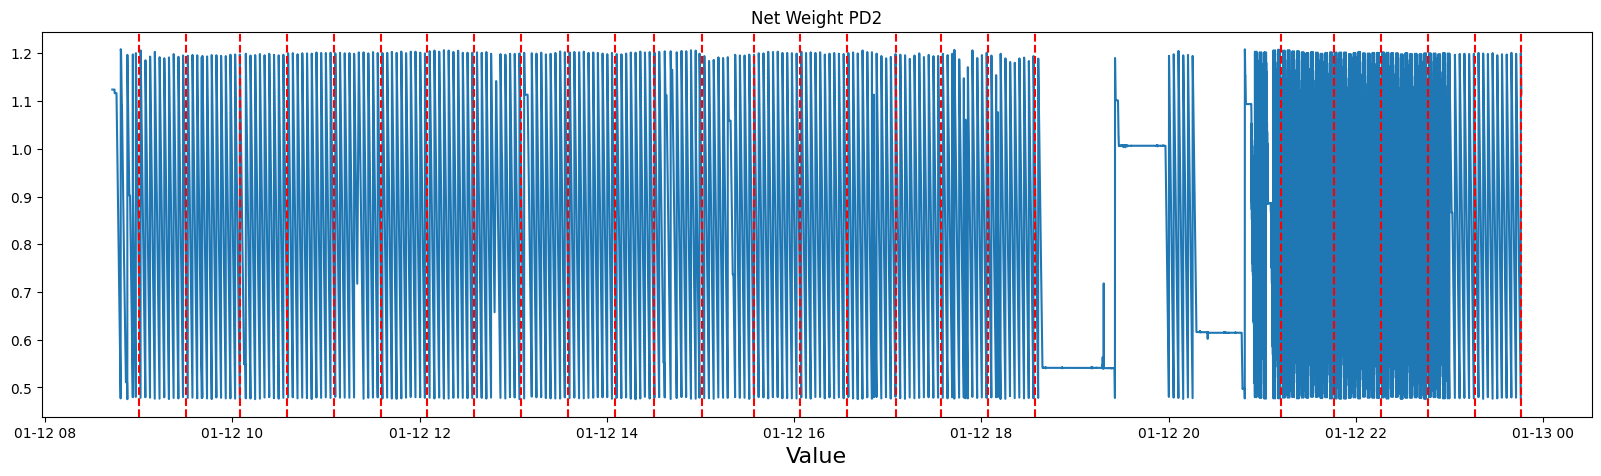

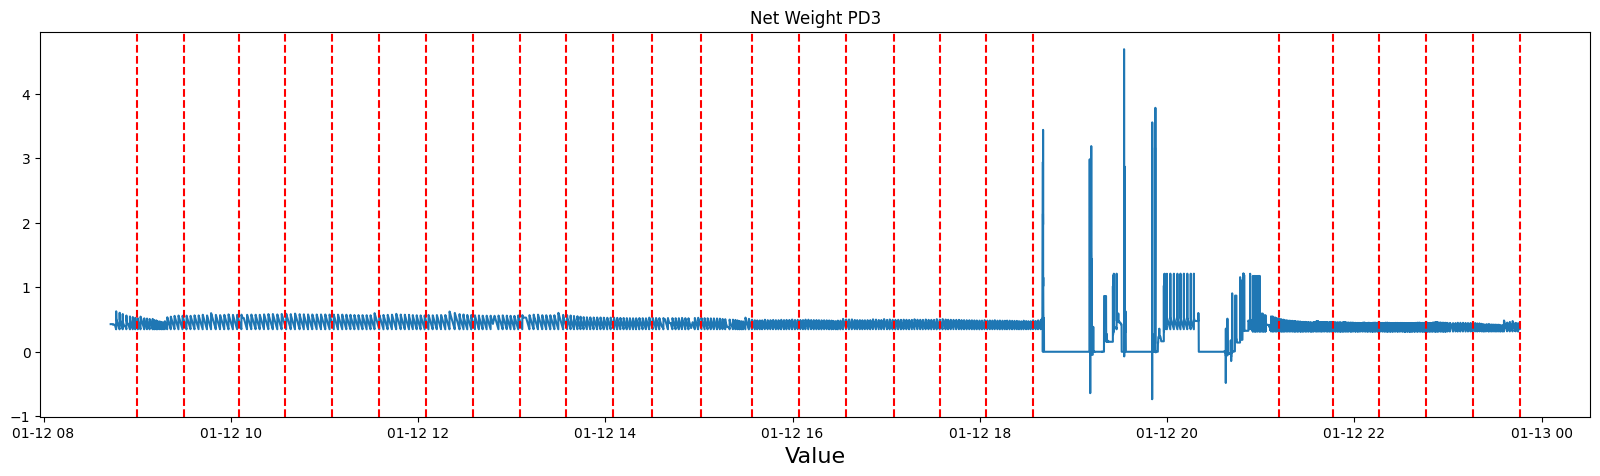

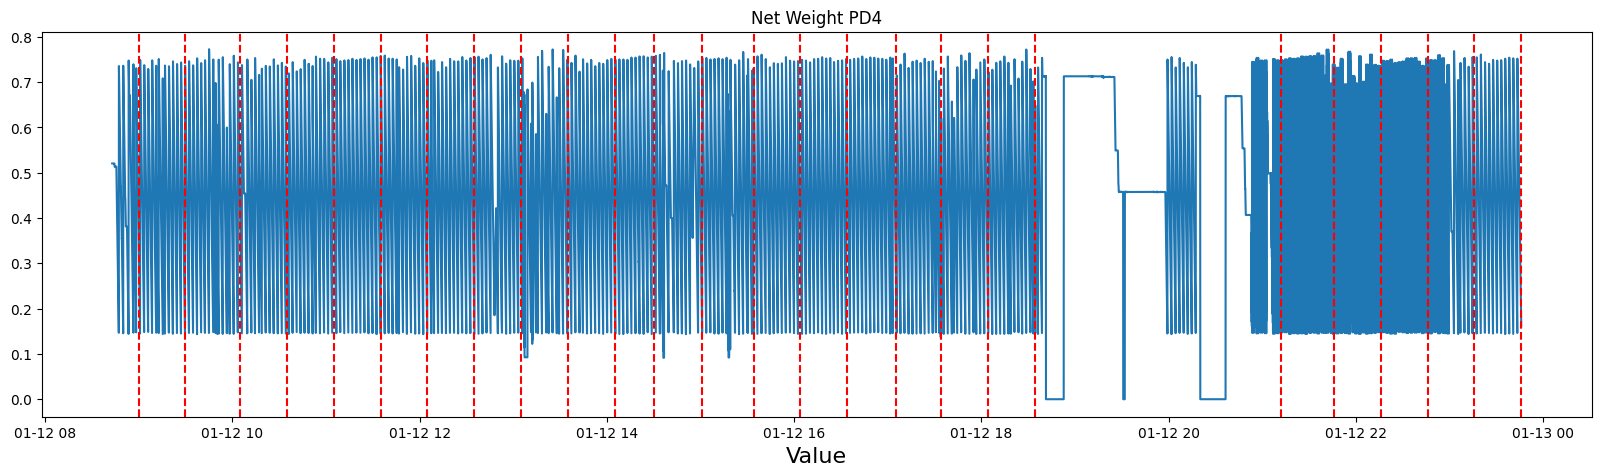

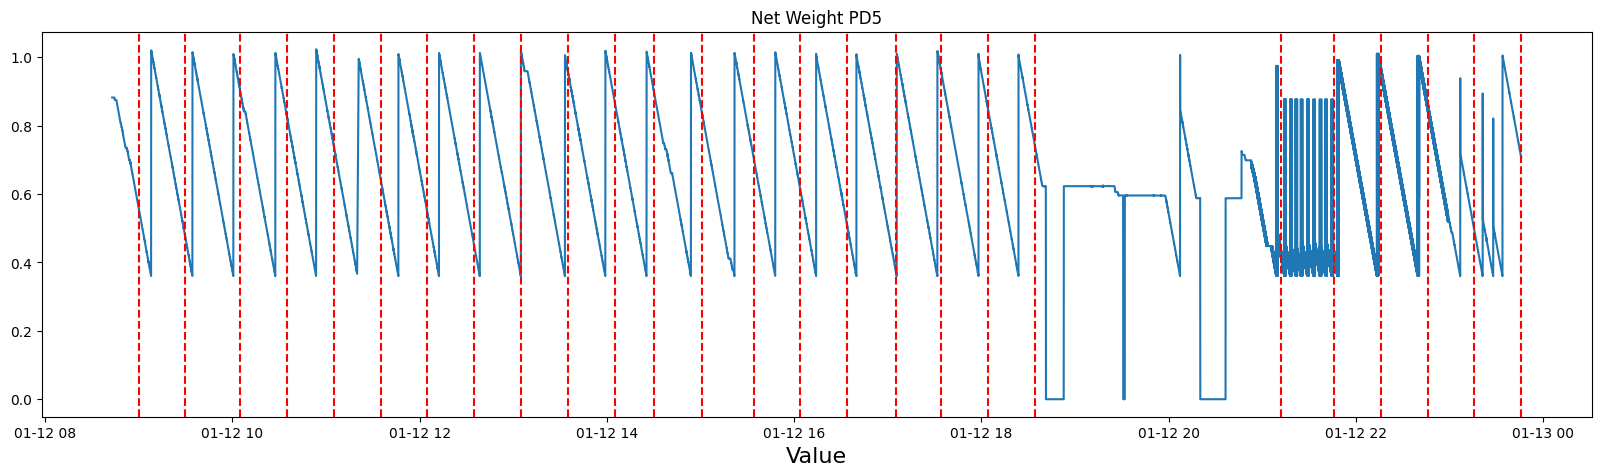

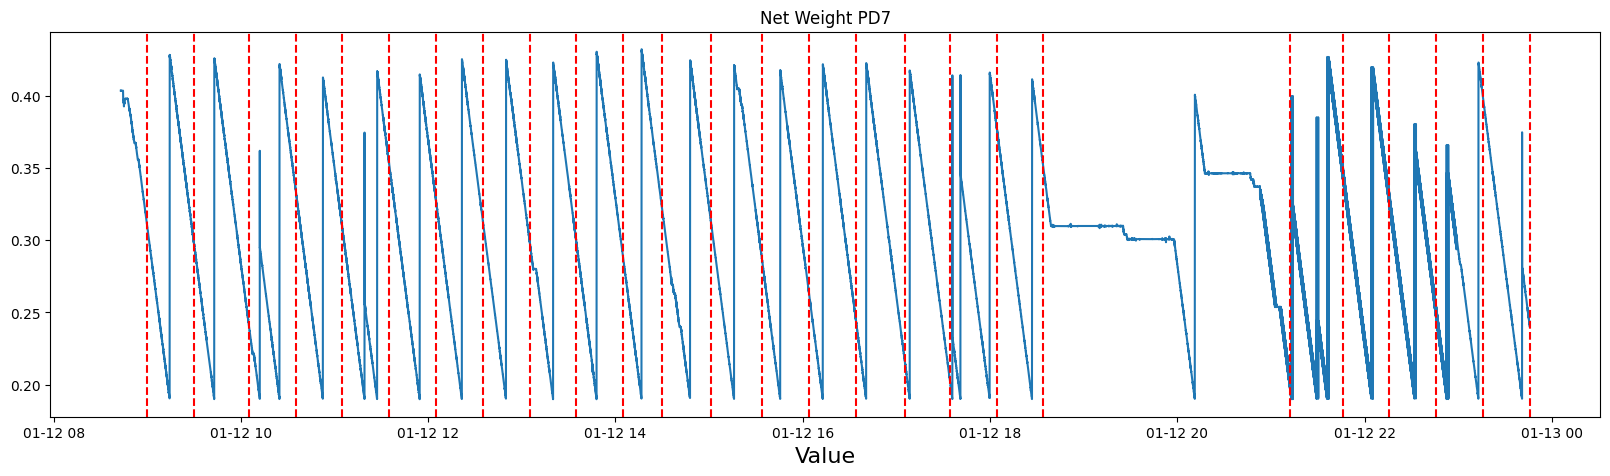

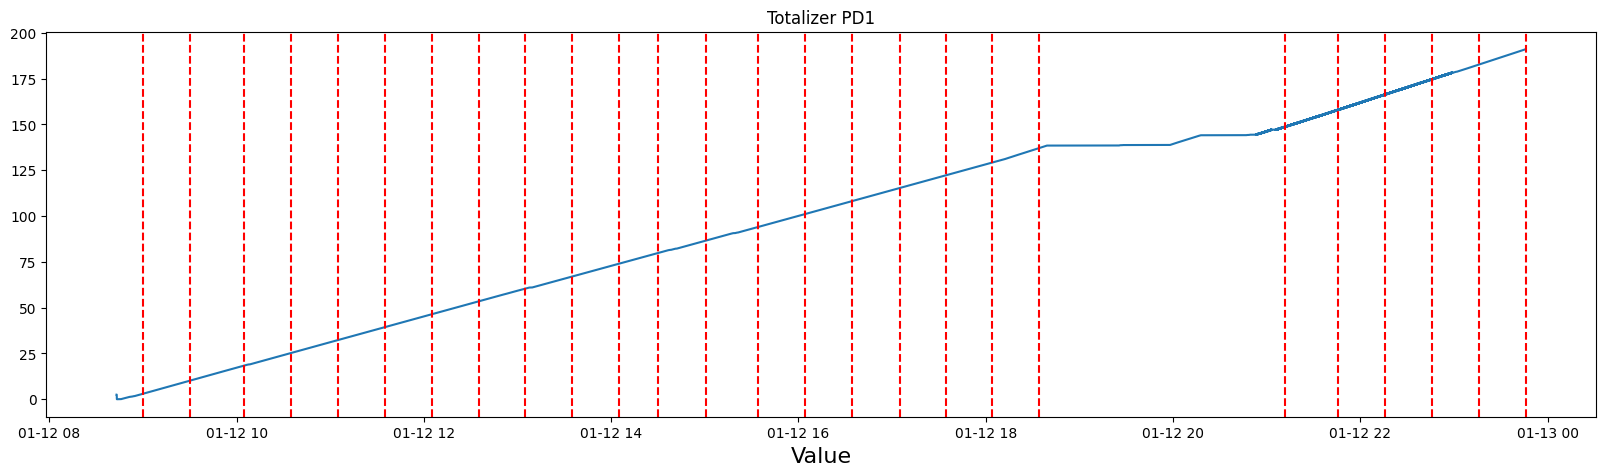

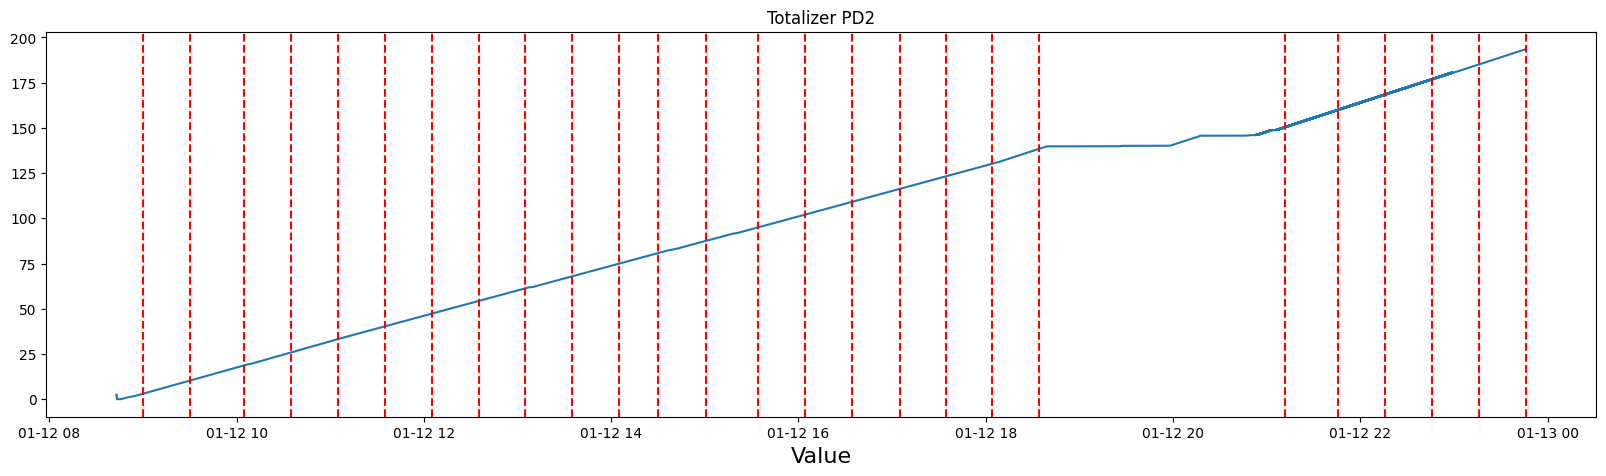

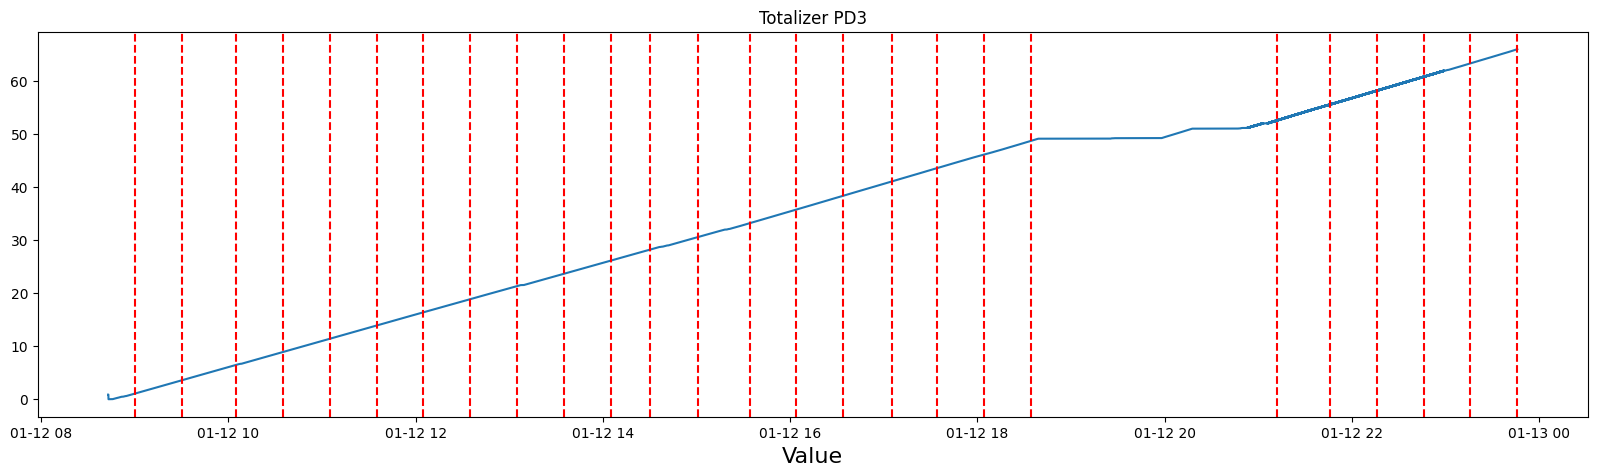

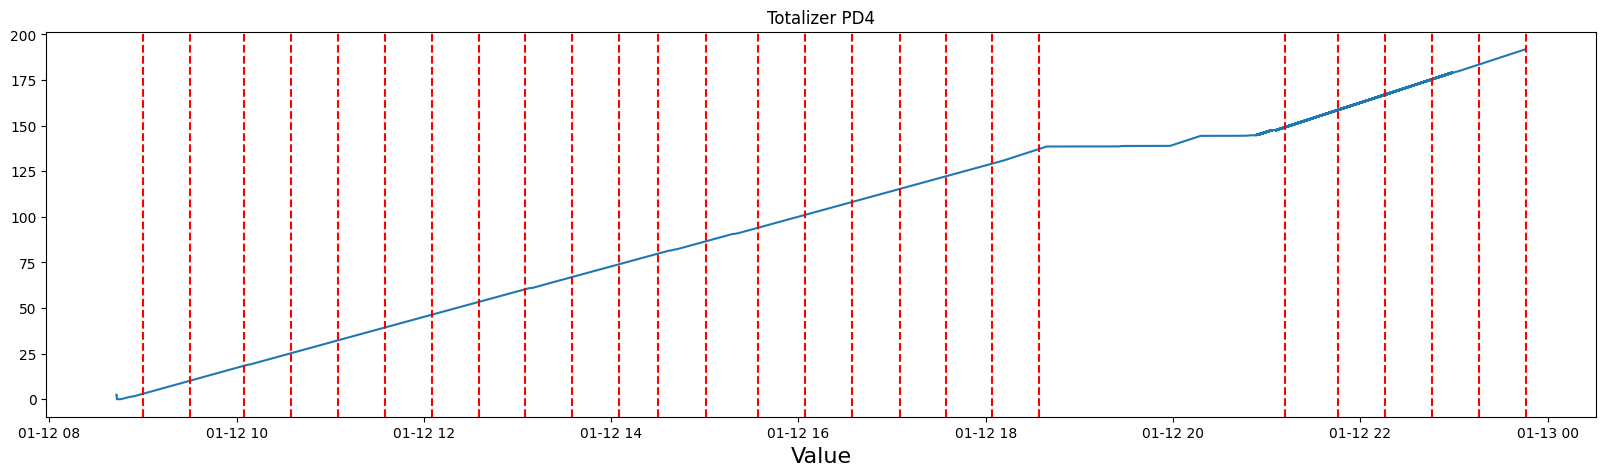

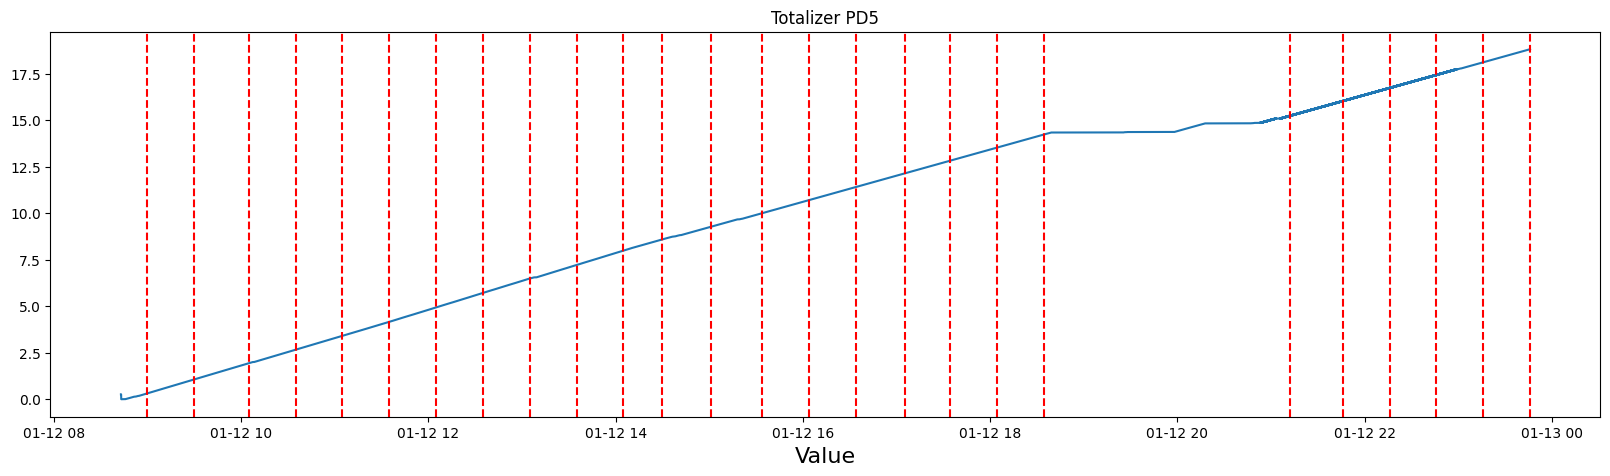

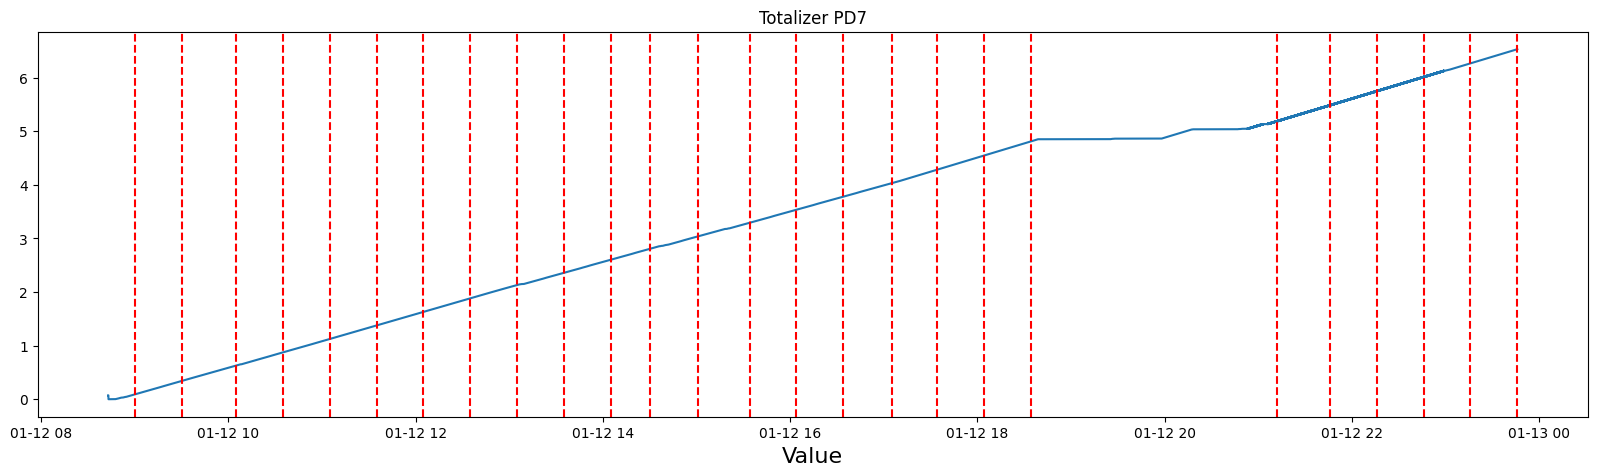

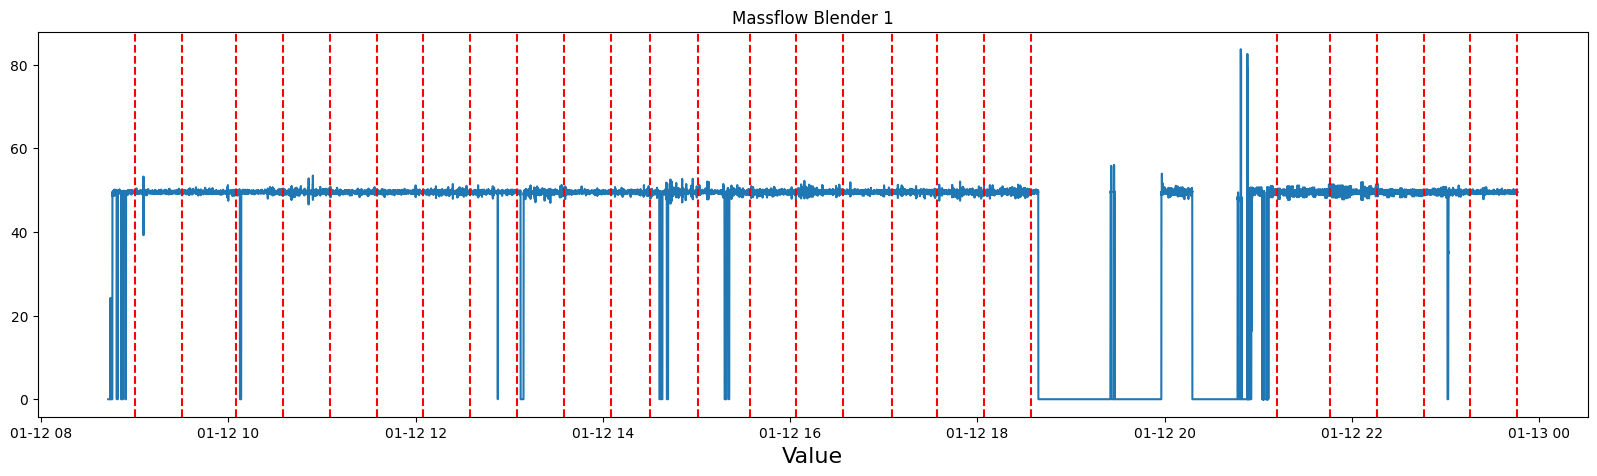

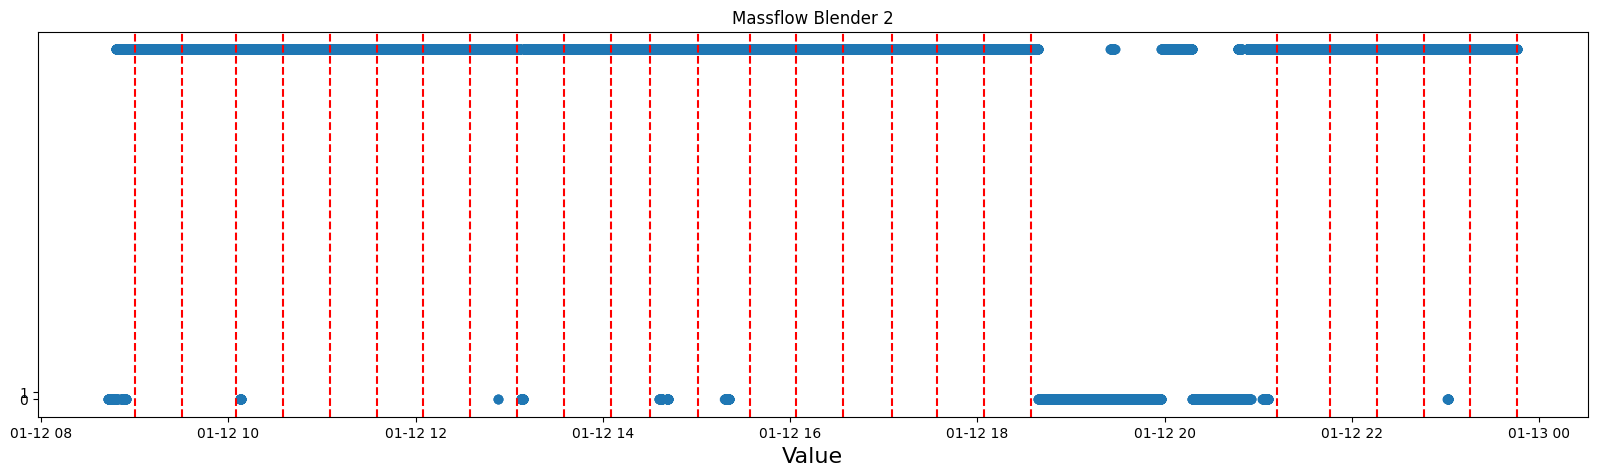

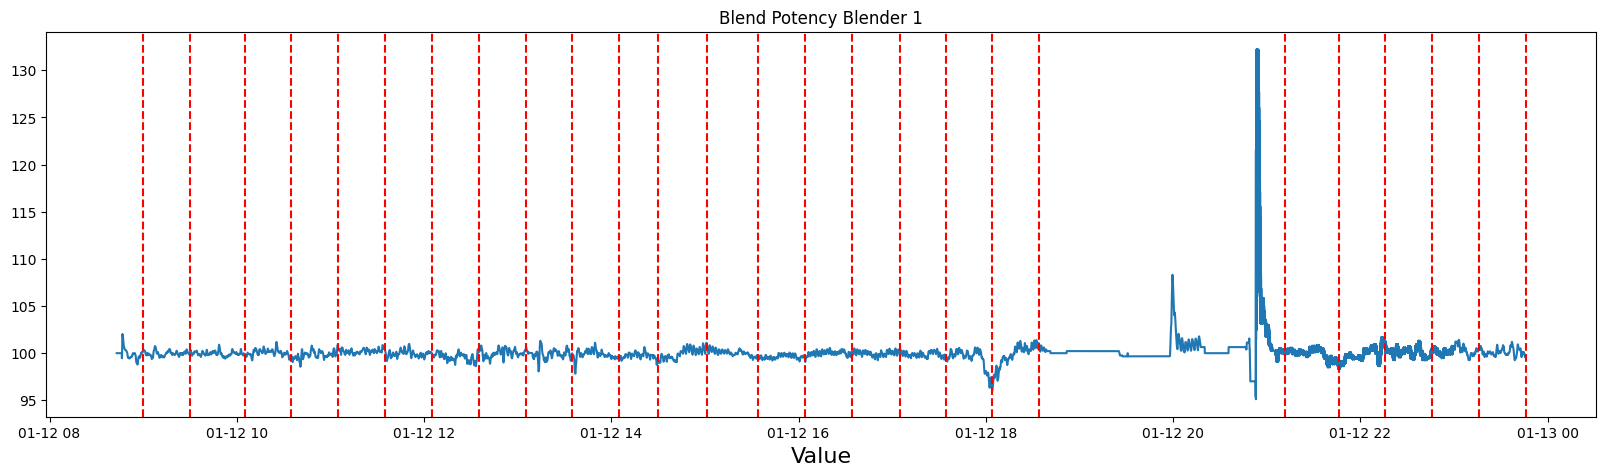

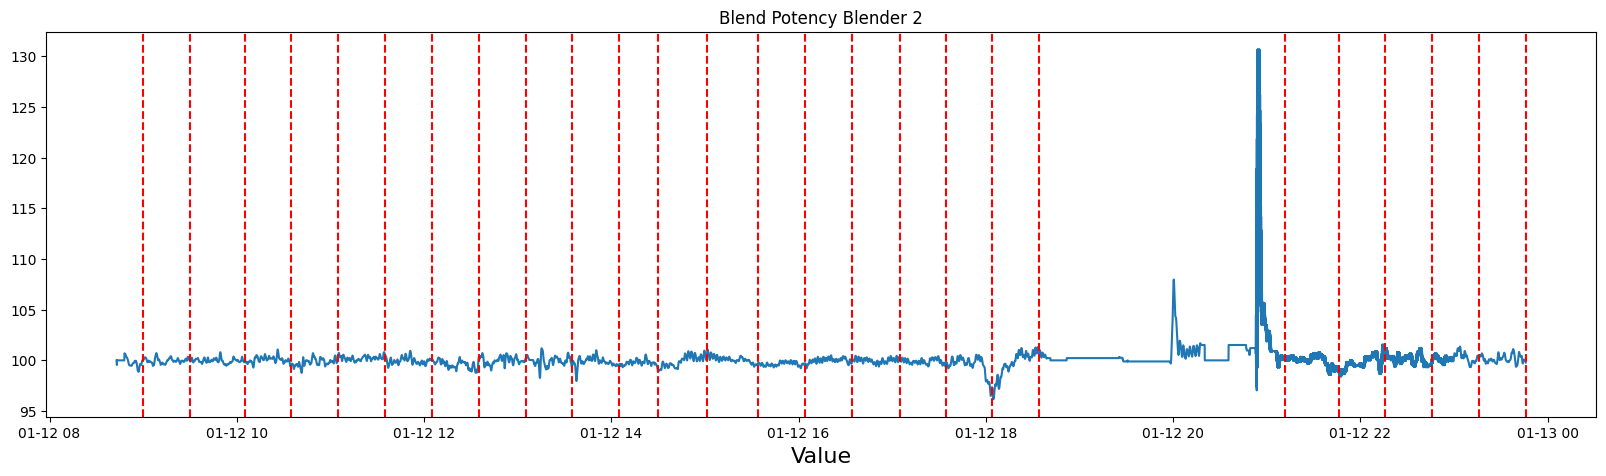

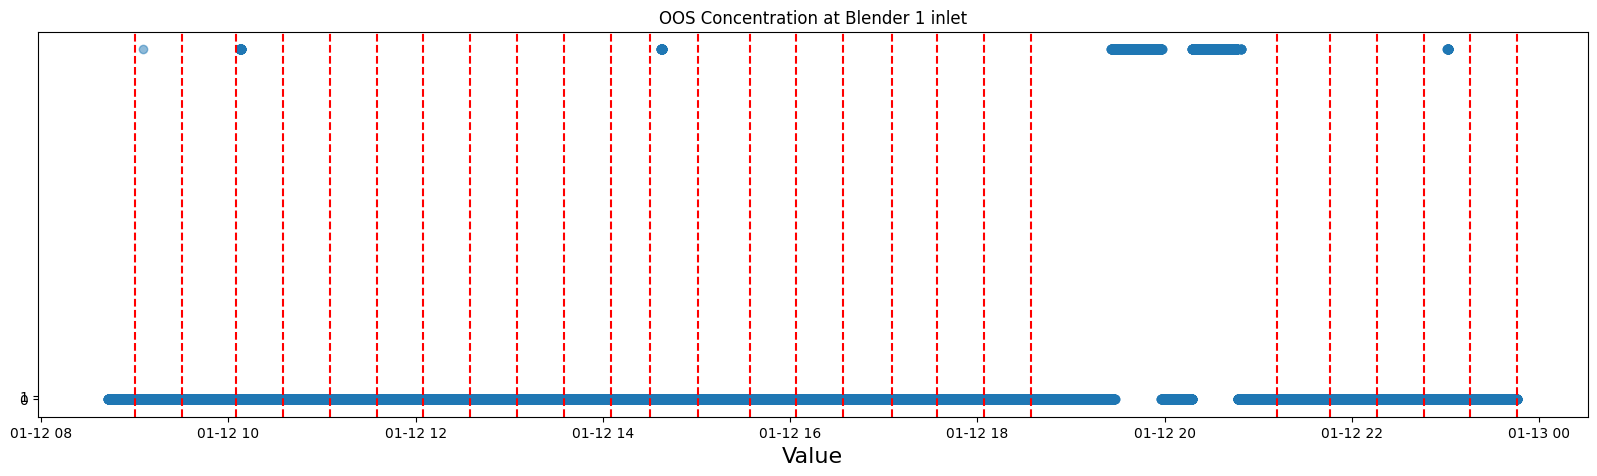

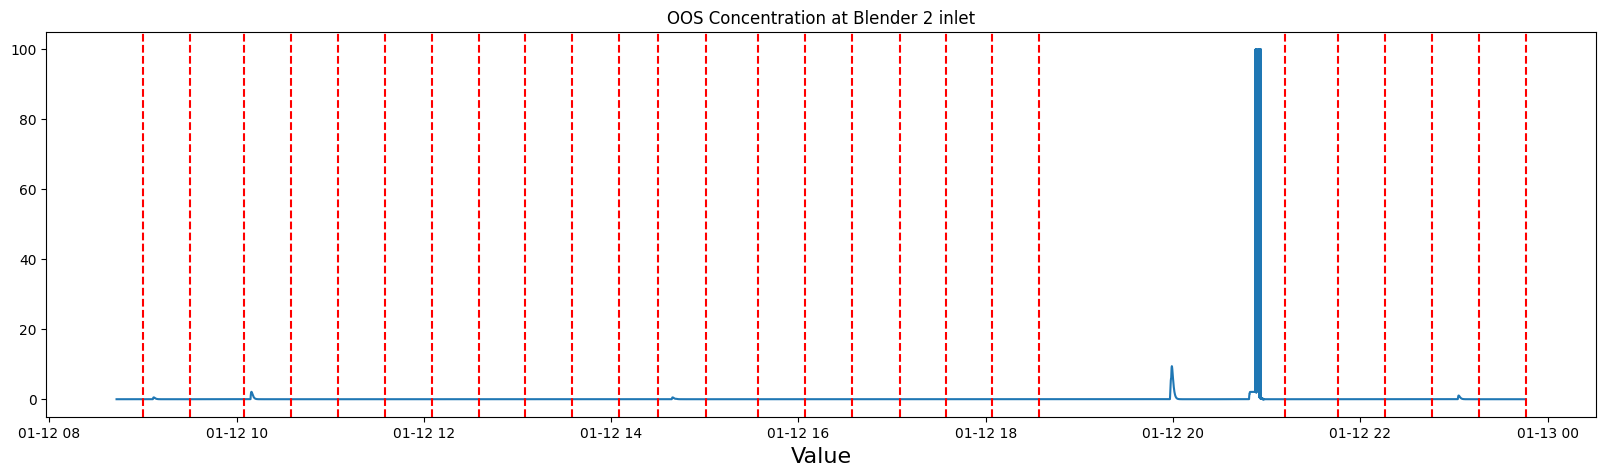

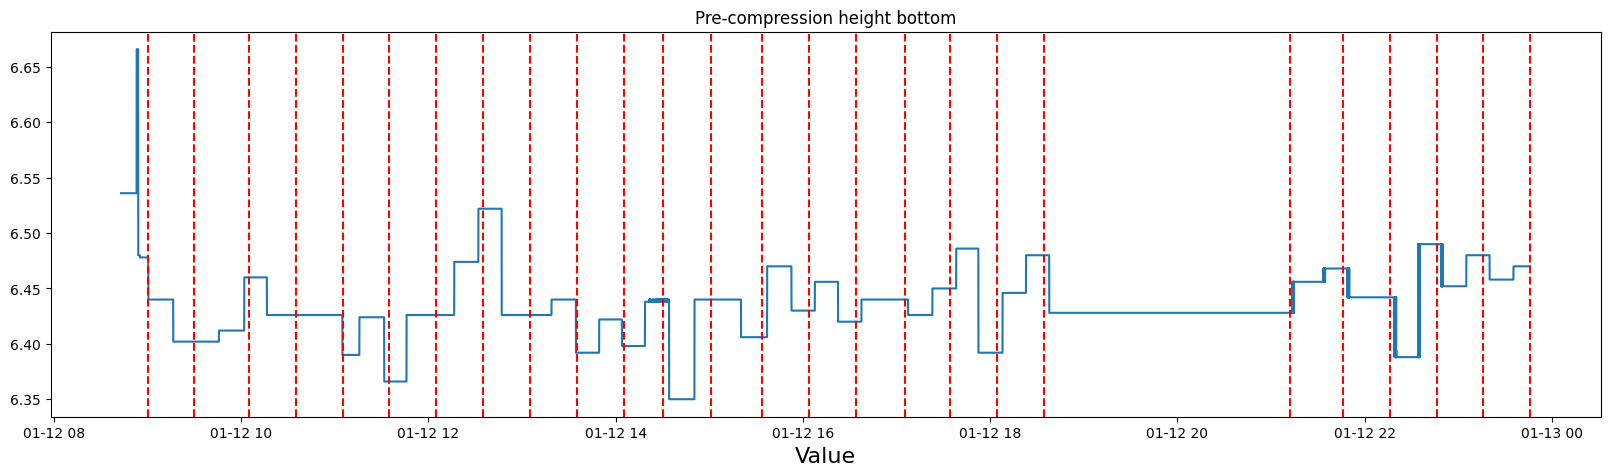

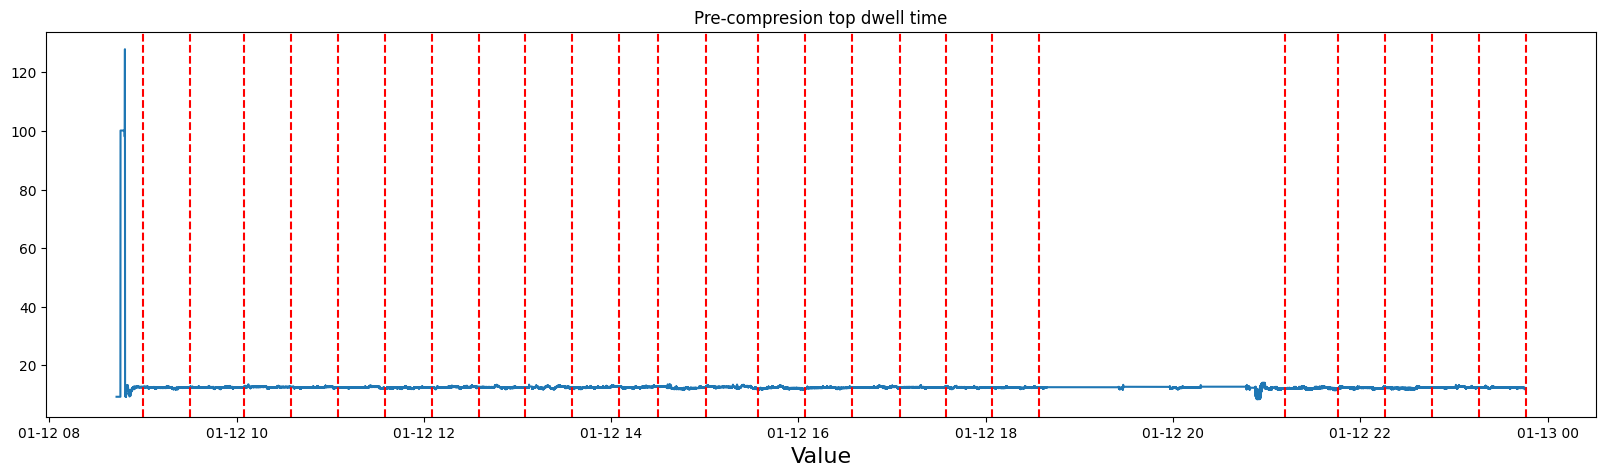

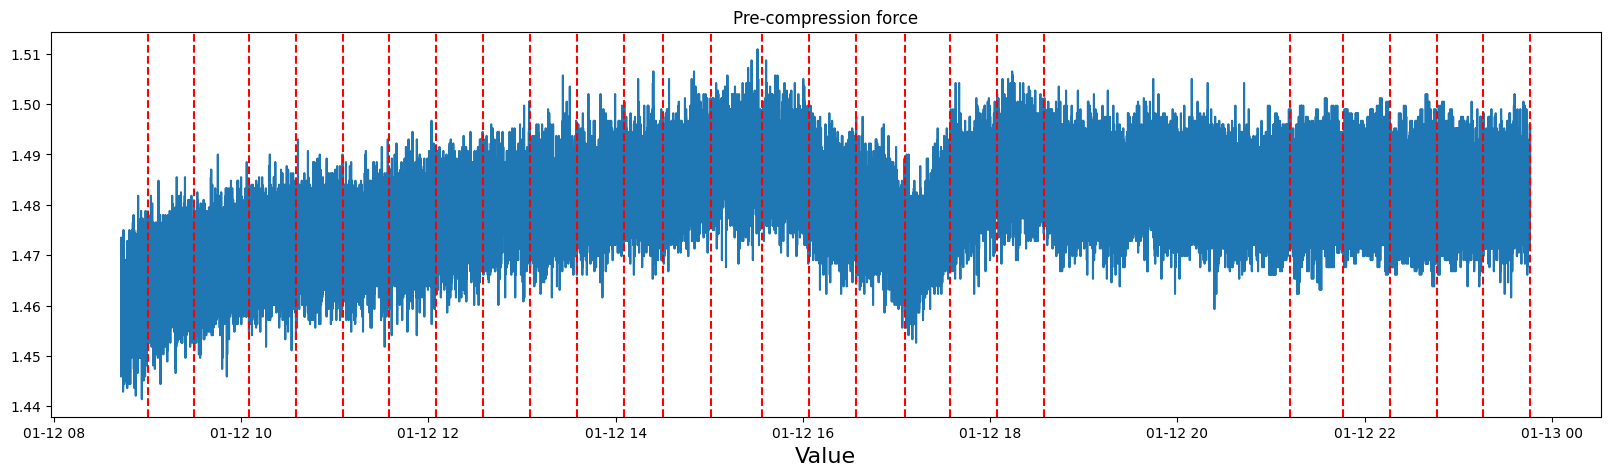

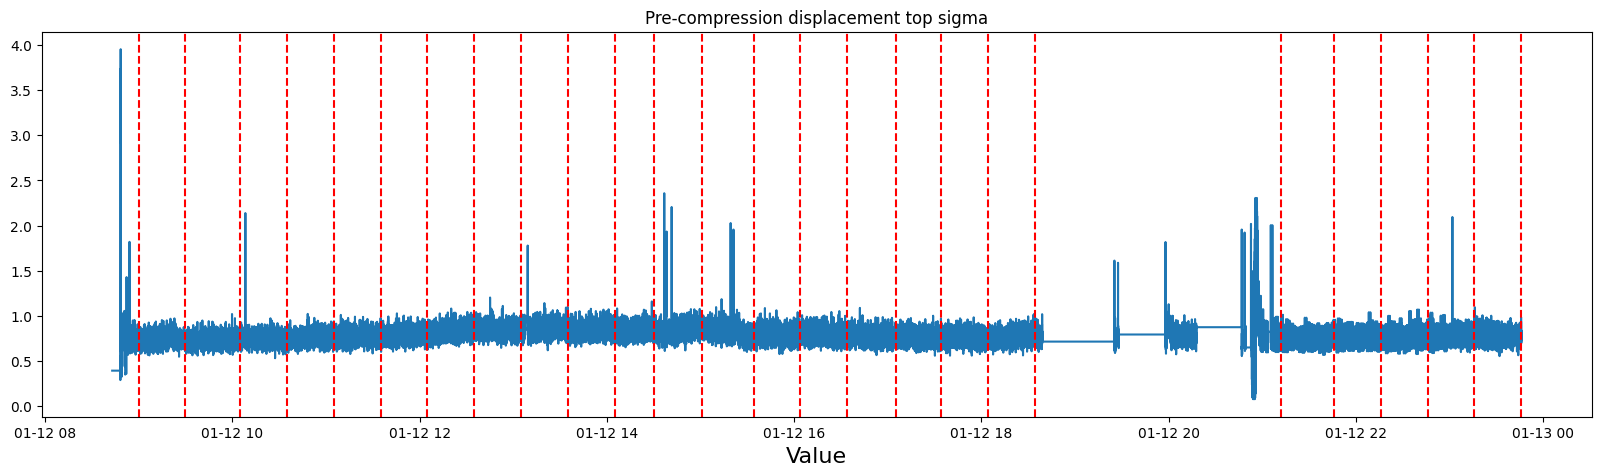

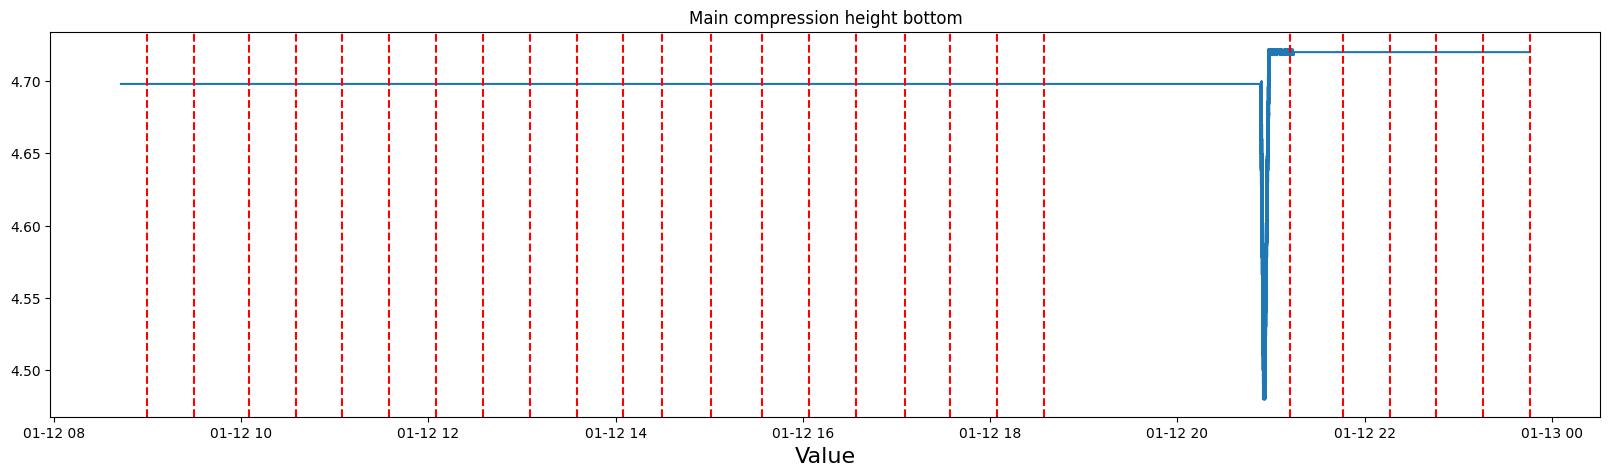

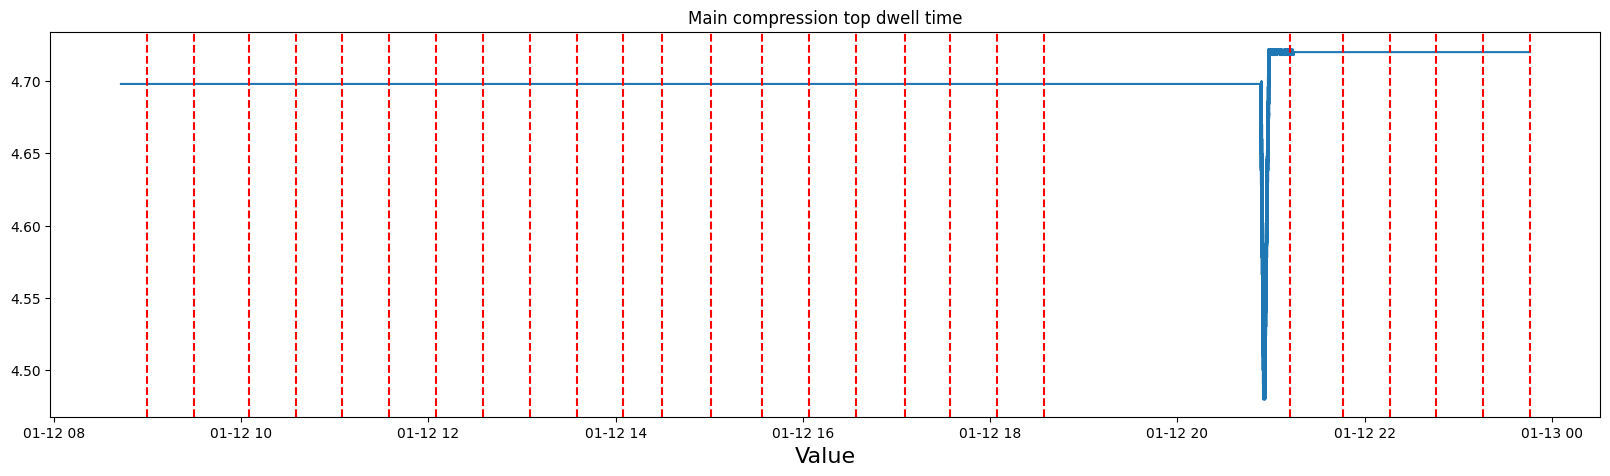

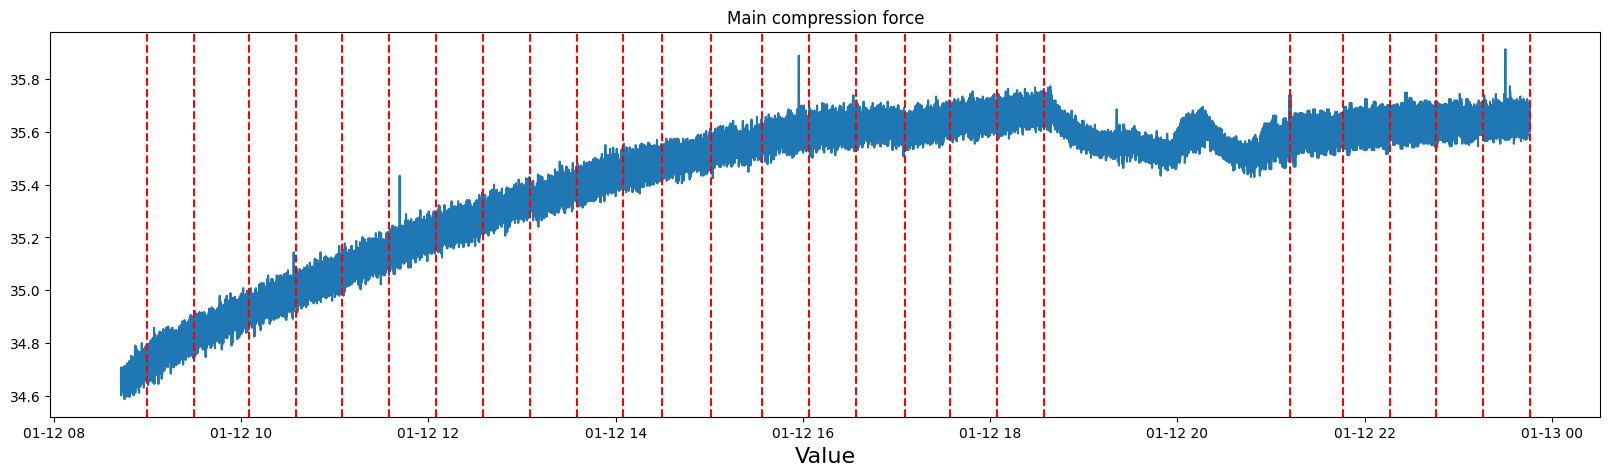

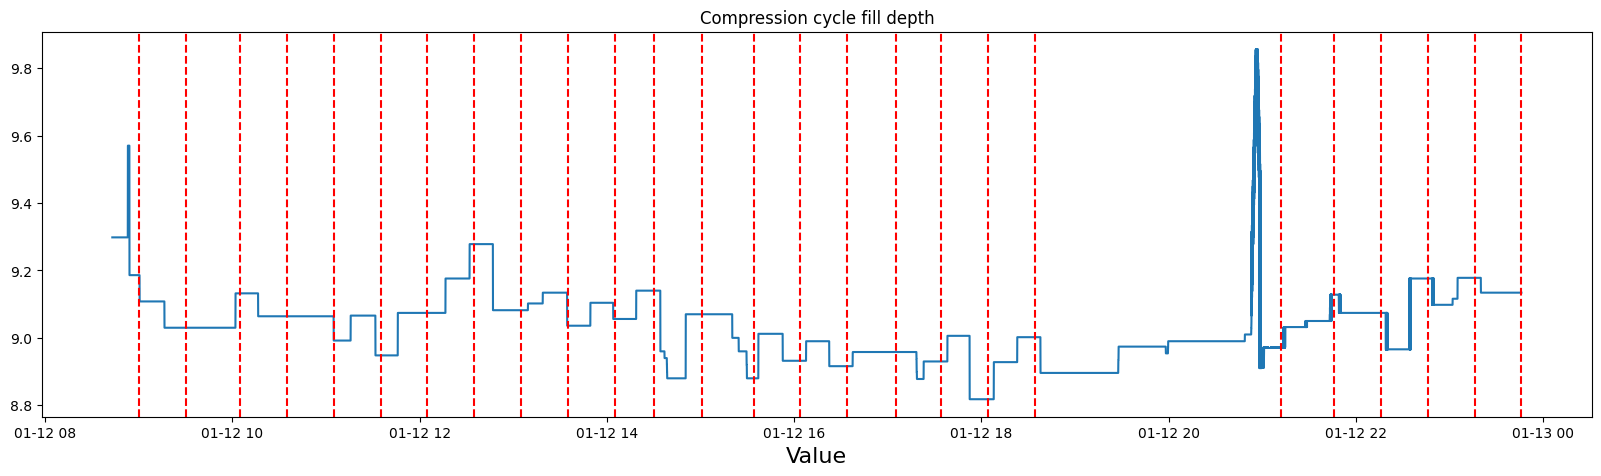

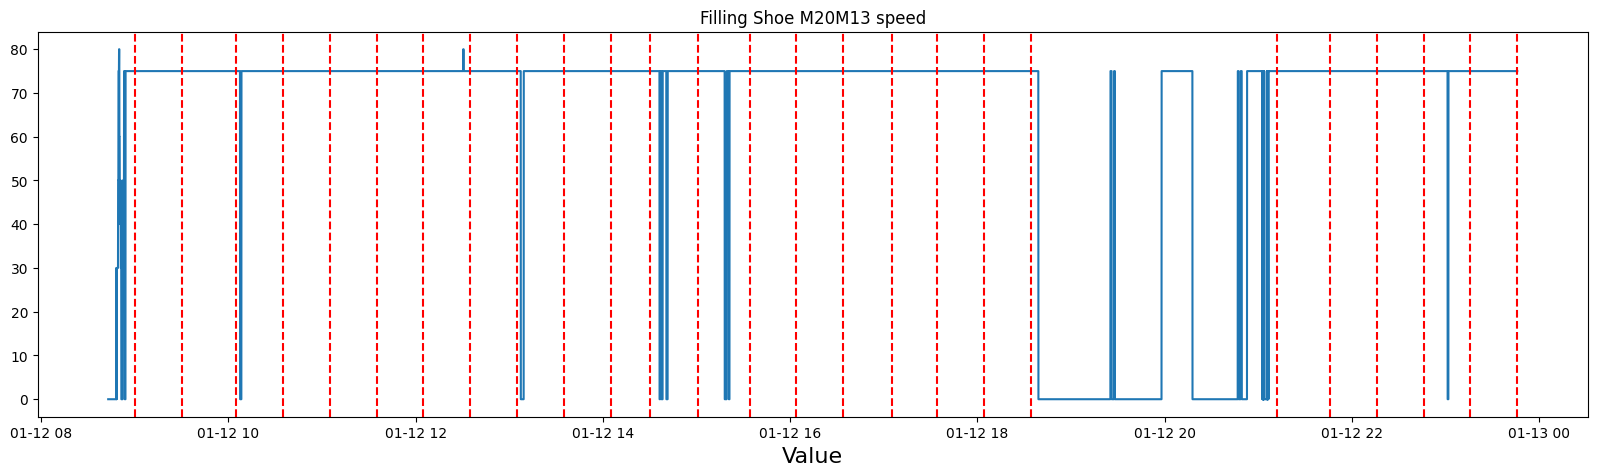

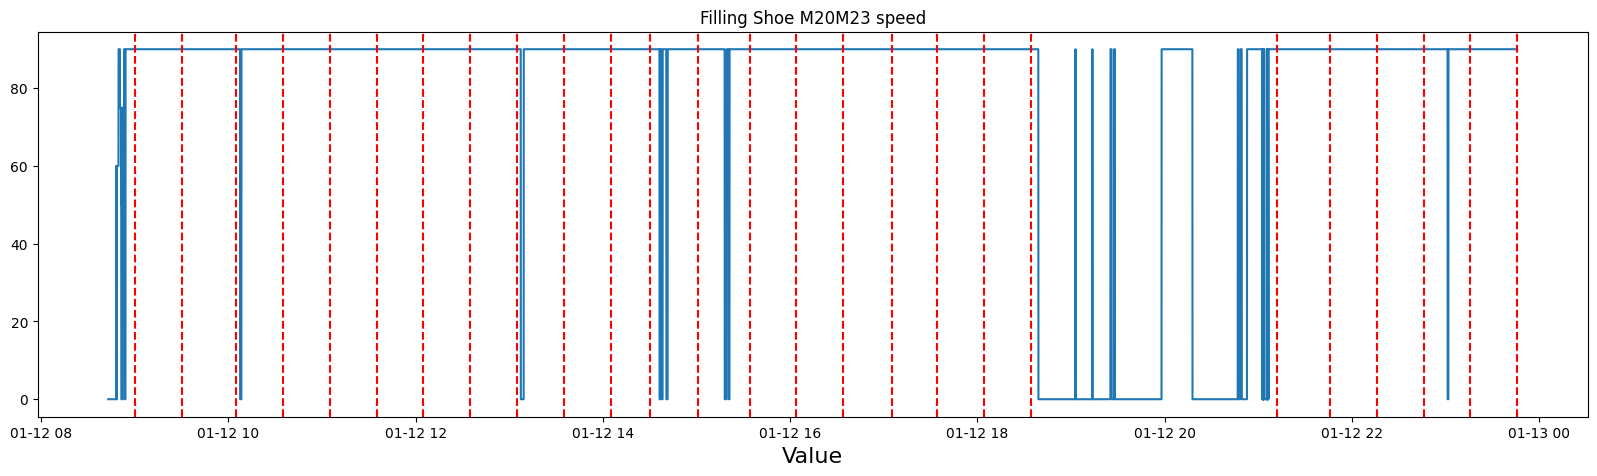

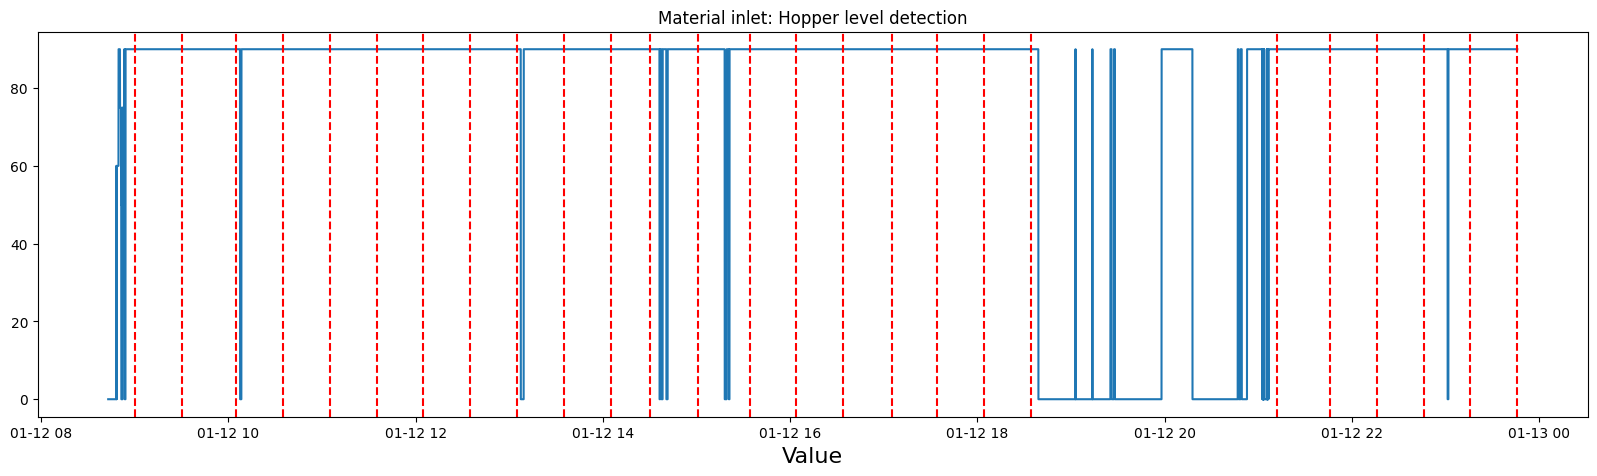

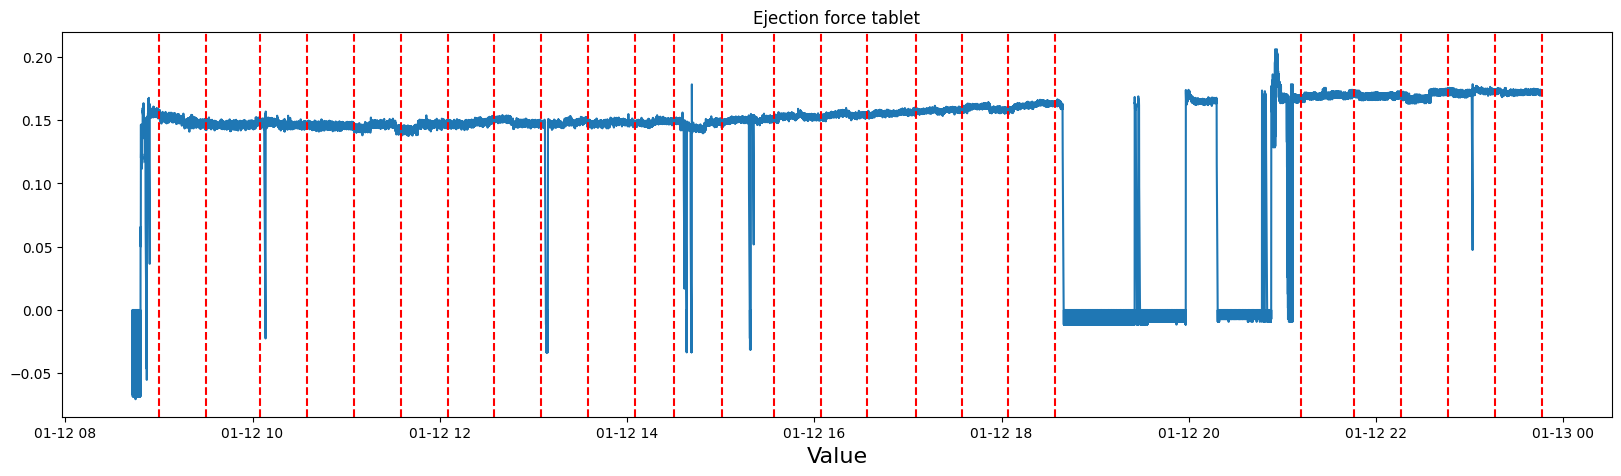

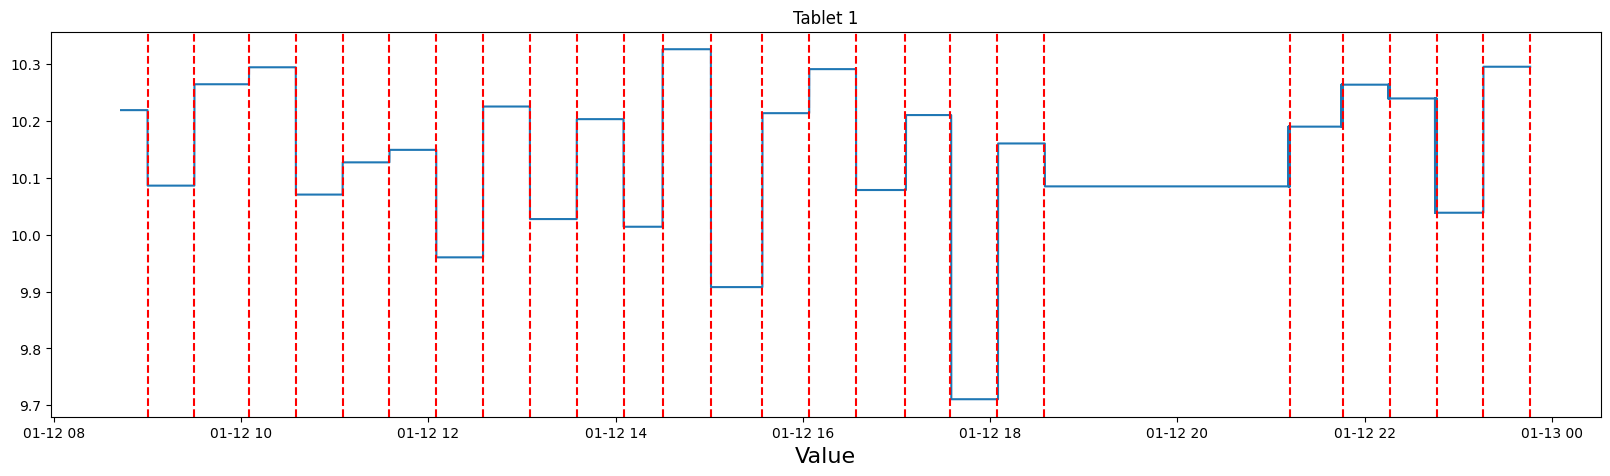

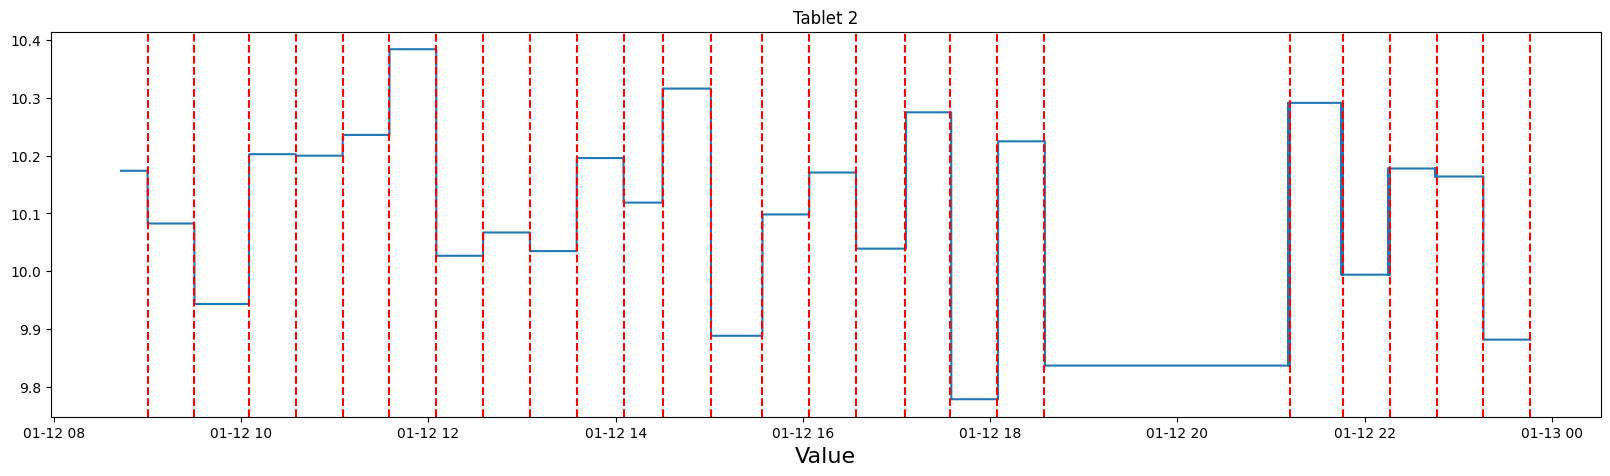

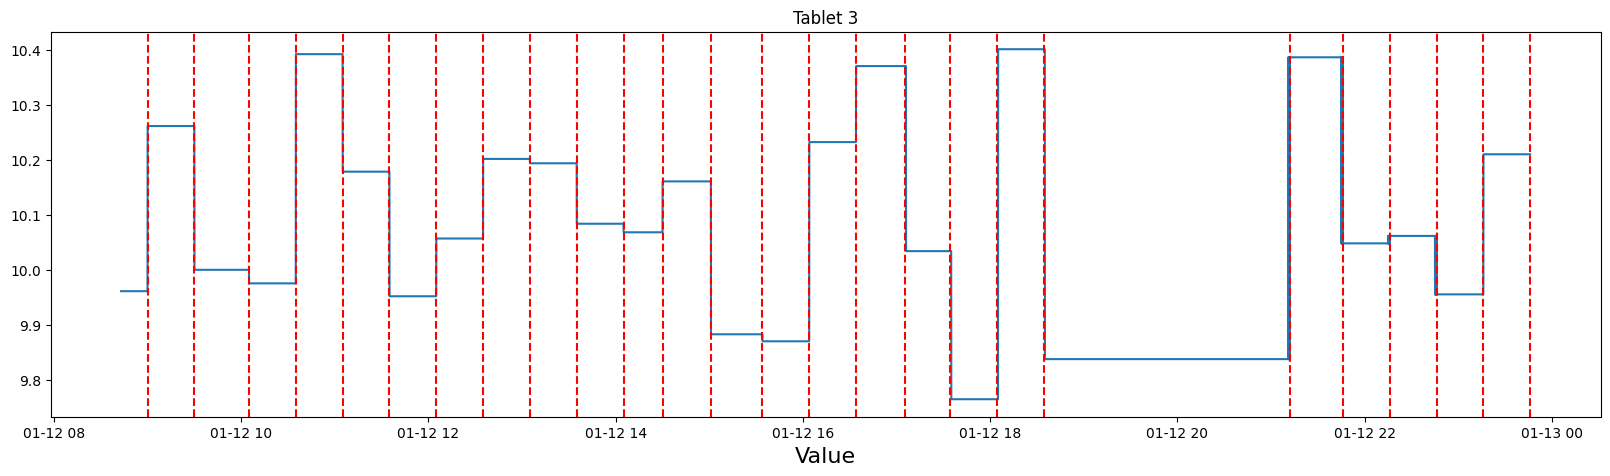

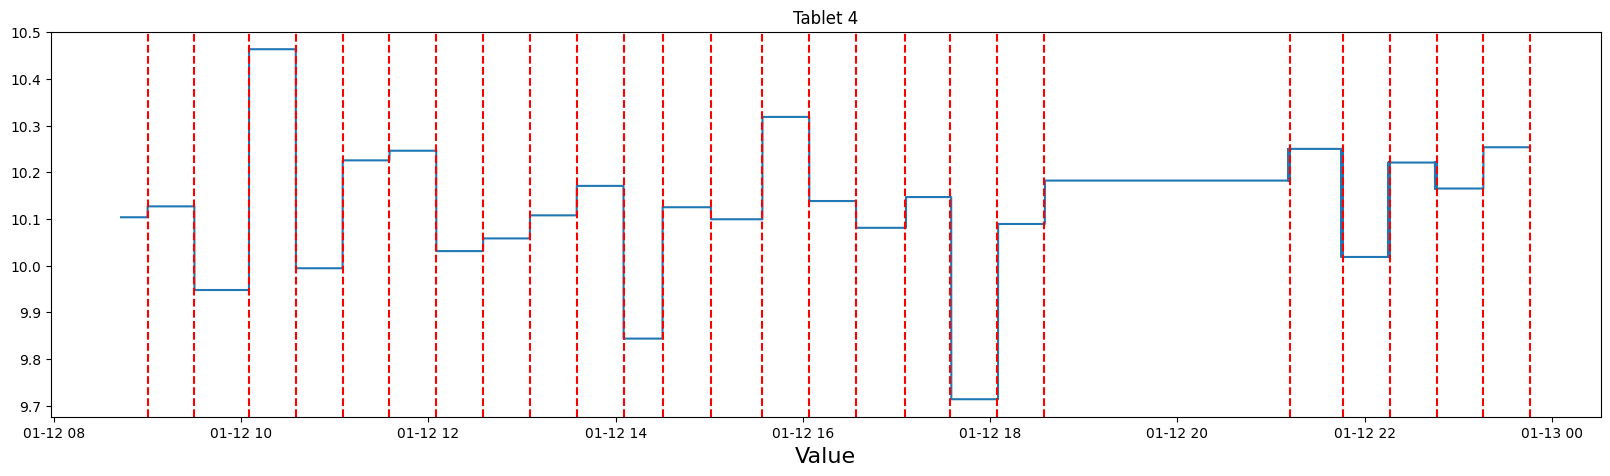

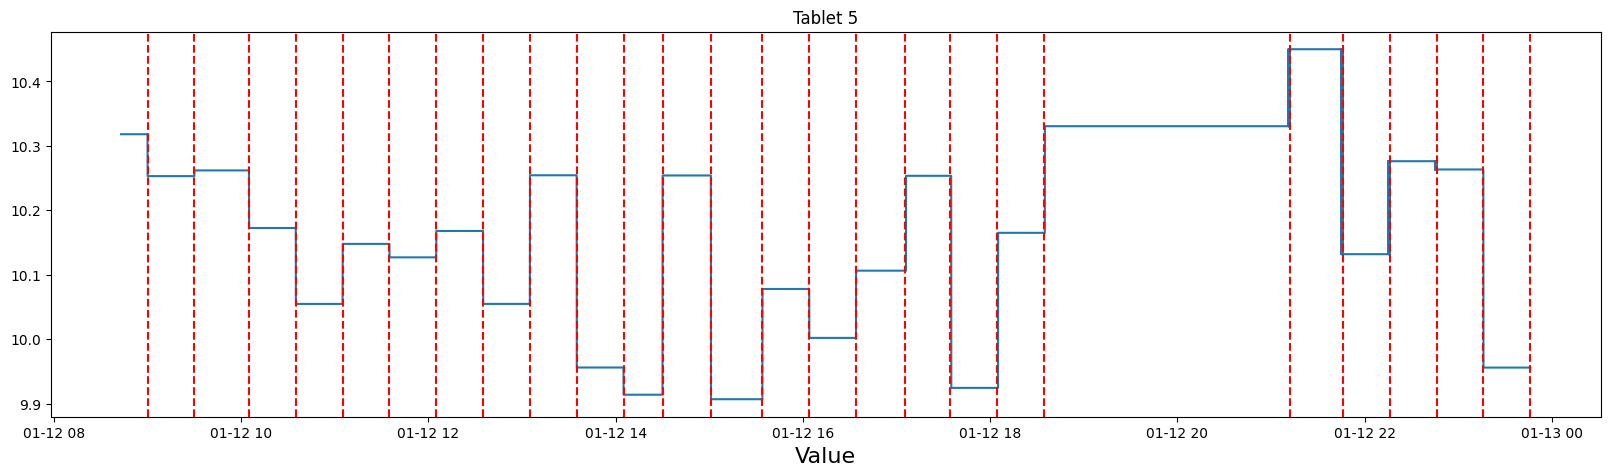

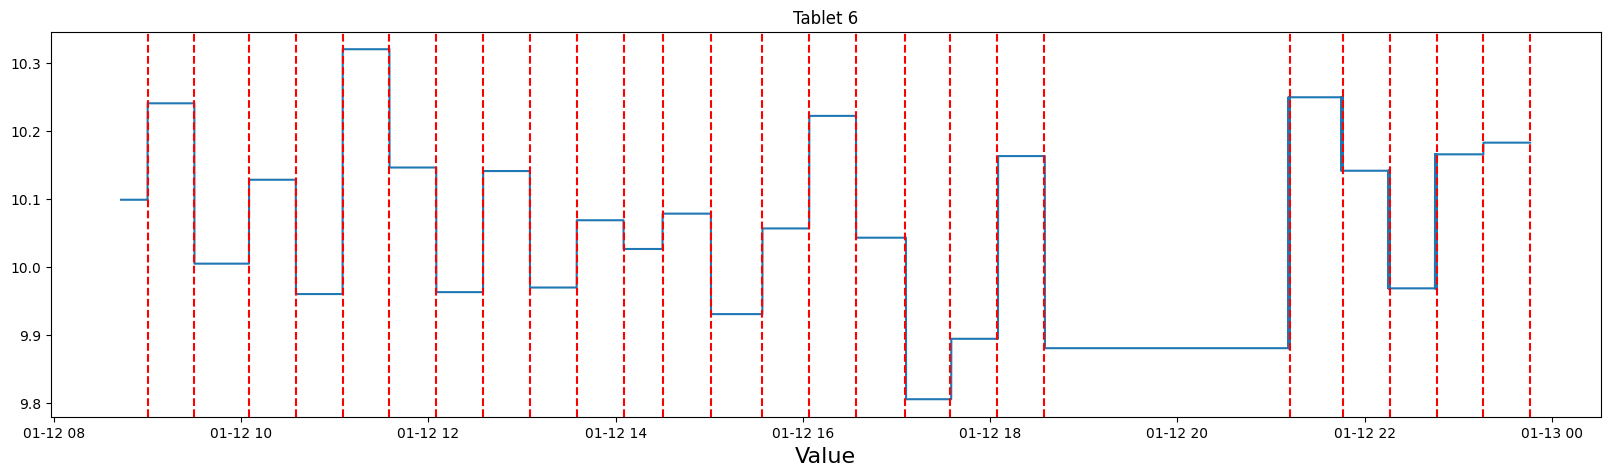

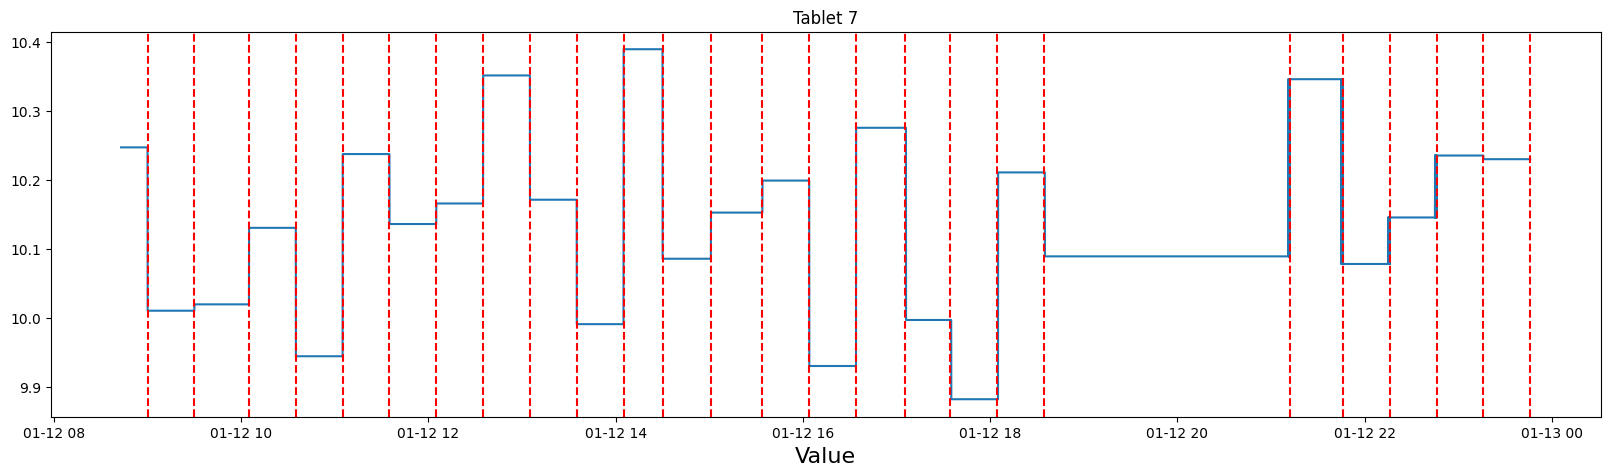

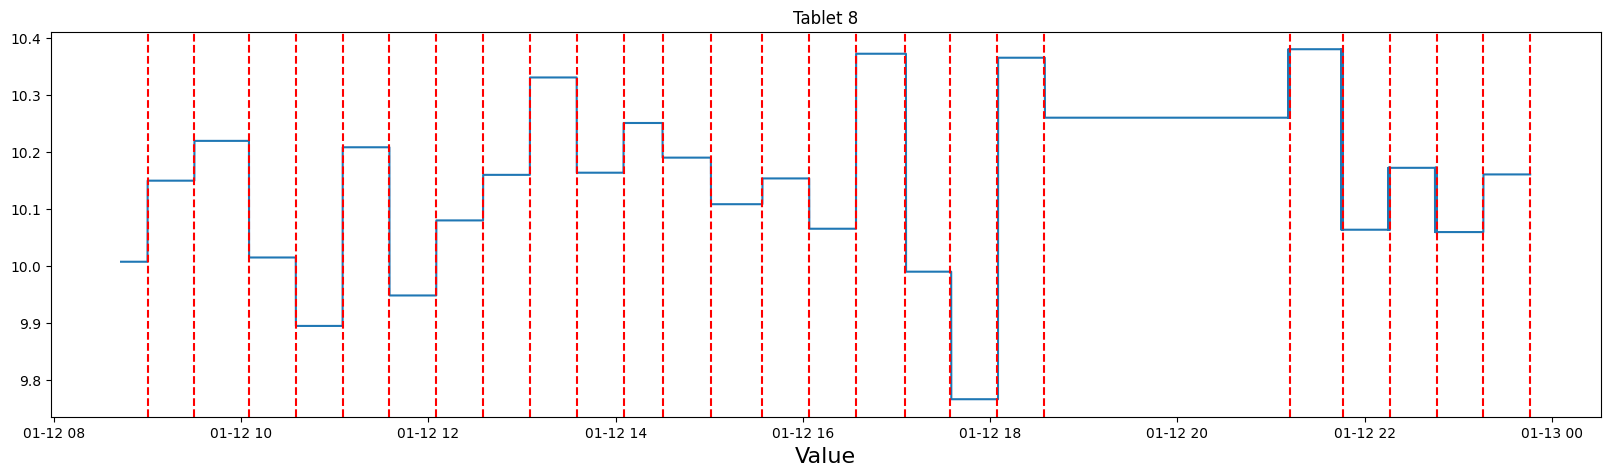

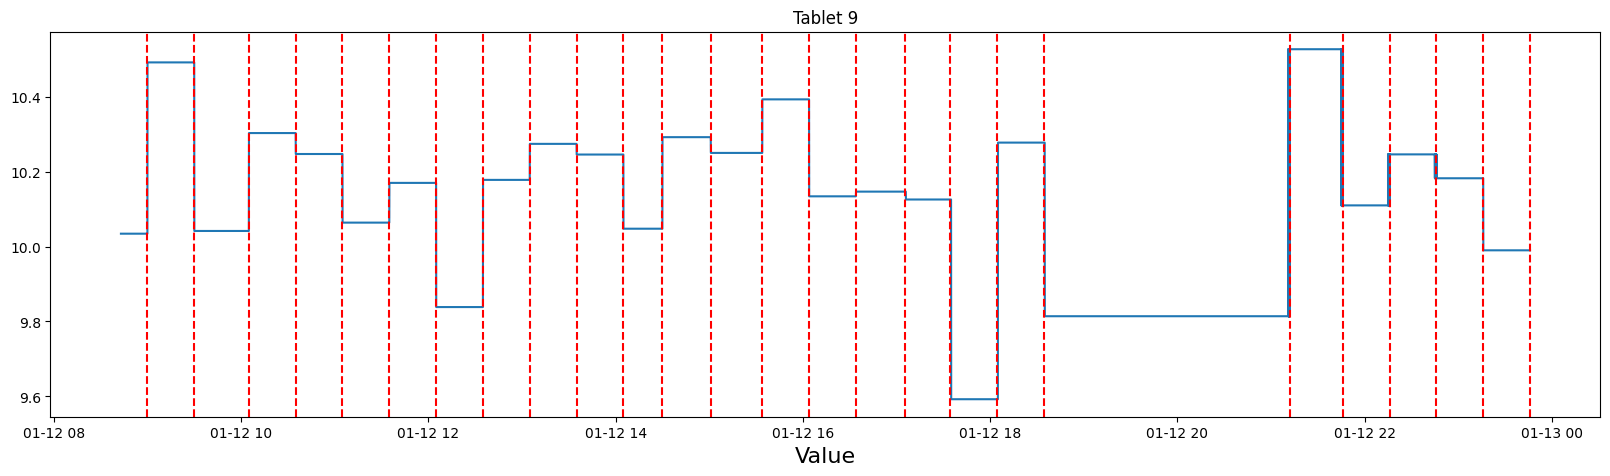

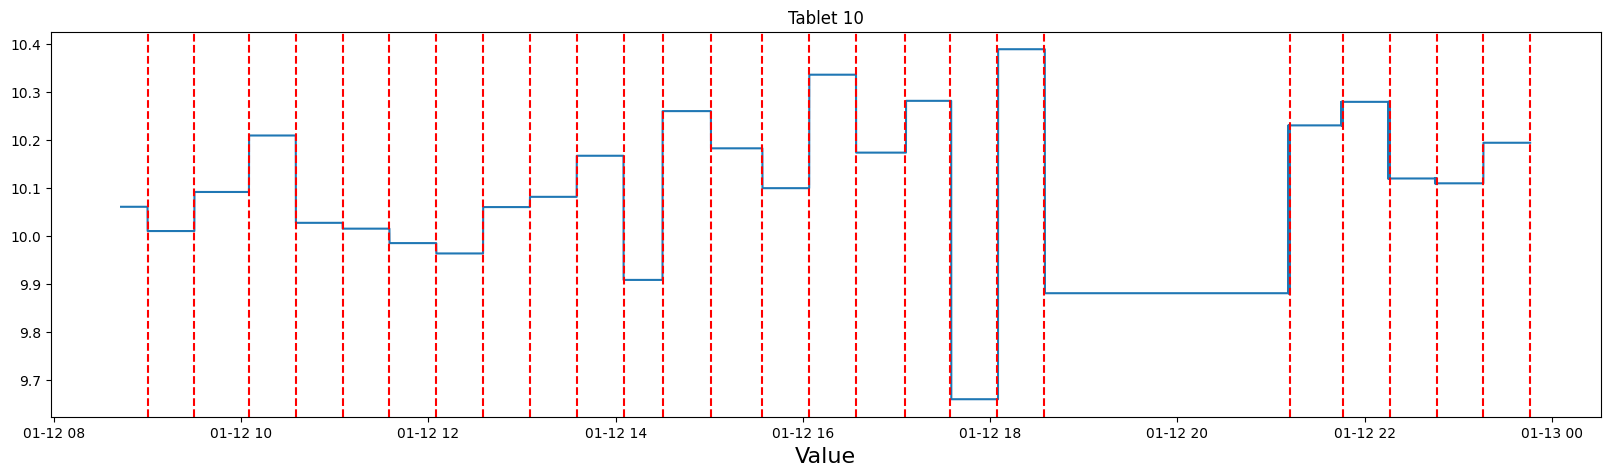

In [7]:
import matplotlib.pyplot as plt

# KDA和時間序列圖
for col in result["API"].columns:
    if col not in ["TimeStamp", "Batch", "sample_time", "sample_id"]:
        plt.figure(figsize=(20, 5))
        
        # 如果是二元值
        if result['API'][col].unique().shape[0] == 2:
            plt.scatter(result['API']['TimeStamp'], result['API'][col], alpha=0.5)  # 繪製散點圖
            plt.yticks([0, 1])  # 限制 Y 軸為 0 和 1
        else:
            plt.plot(result['API']["TimeStamp"], result['API'][col])
        
        for sample_time in sample_times:
            plt.axvline(sample_time, color='r', linestyle='--')

        plt.title(col)
        plt.xlabel('Value', fontsize=16)
        plt.show()

# 數據分析

## 策略
1. 先將資料依照sample_time分組
2. 先用F檢定來找出顯著變數，再來使用機器學習方法來做預測
3. 使用PCA作為比較基礎

## 機器學習方法
1. 隨機森林回歸
2. XGboot

In [75]:
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

In [77]:
df = result['API']
target = ['Tablet 1', 'Tablet 2', 'Tablet 3', 'Tablet 4', 'Tablet 5', 'Tablet 6', 'Tablet 7', 'Tablet 8', 'Tablet 9', 'Tablet 10']
# 1. 選擇特徵
X = df.drop(columns=['TimeStamp', 'Batch', 'sample_id'] + target)
y = df[['sample_time'] + target]

# 2. 將data依照sample time分組
X_group = X.groupby('sample_time')
y = y.apply(lambda col: col.unique(), axis=0)

In [106]:
for sample_time in sample_times:
    group_X = X_group.get_group(sample_time)
    print(y[y.loc[:, 'sample_time'] == sample_time].drop(columns=['sample_time']).values.flatten())

[10.21902  10.17375   9.961281 10.1037   10.31806  10.09846  10.247
 10.00731  10.03426  10.06077 ]
[10.08629 10.08254 10.26188 10.12708 10.25302 10.24025 10.01045 10.14981
 10.49131 10.01035]
[10.26451   9.943297 10.0002    9.947901 10.26186  10.00452  10.01965
 10.21976  10.04153  10.09156 ]
[10.29434  10.20244   9.975531 10.46366  10.1725   10.12787  10.13046
 10.01478  10.30276  10.20896 ]
[10.07056  10.19985  10.39272   9.994505 10.05464   9.959817  9.94449
  9.89448  10.24687  10.02742 ]
[10.12721 10.23577 10.17884 10.22562 10.14779 10.31977 10.23731 10.20852
 10.06378 10.01531]
[10.14918  10.38398   9.952027 10.24624  10.12693  10.14585  10.13599
  9.94803  10.16979   9.985278]
[ 9.960211 10.02673  10.05718  10.03125  10.16788   9.962654 10.16574
 10.07995   9.838468  9.963766]
[10.22536 10.06703 10.20206 10.0584  10.05467 10.14067 10.35116 10.16003
 10.17781 10.06016]
[10.02752  10.03483  10.1941   10.10784  10.25433   9.969406 10.17119
 10.33122  10.27393  10.08145 ]
[10.20318

In [133]:
class TimeSeriesRandomForestRegressor:
    def __init__(self, model_name, df: pd.DataFrame, target: list[str], feature: list[str] = None, folds: int = 5, n_estimators=10, random_state=42):
        self.df = df.sort_values(by="TimeStamp")  # ✅ 確保數據按照時間排序
        self.target = target
        self.feature = feature
        self.model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
        self.model_name = model_name
        self.folds = folds

    def train(self) -> None:
        # 1. 選擇特徵
        feature_df = self.df

        # 轉換時間戳記為特徵
        feature_df['hour'] = feature_df["TimeStamp"].dt.hour
        feature_df['minute'] = feature_df["TimeStamp"].dt.minute
        feature_df['second'] = feature_df["TimeStamp"].dt.second
        feature_df['day_of_week'] = feature_df["TimeStamp"].dt.dayofweek
        feature_df['day_of_year'] = feature_df["TimeStamp"].dt.dayofyear

        # drop不會使用到的特徵
        feature_df = feature_df.drop(columns=["TimeStamp", 'Batch', 'sample_id'] + self.target)

        y = self.df[['sample_time'] + self.target]

        # 2. 將data依照sample time分組
        X_group = feature_df.groupby('sample_time')
        y = y.apply(lambda col: col.unique(), axis=0)

        _sample_times = list(y['sample_time'])

        X_list = []
        y_list = []

        lookback = min([len(X_group.get_group(_sample_time)) for _sample_time in _sample_times])
        
        # 3. 使用lookback得分組資料分批訓練模型
        for sample_time in _sample_times:
            group_X = X_group.get_group(sample_time).drop(columns=['sample_time']) # 取得該時間點的所有X
            group_X = group_X.iloc[len(group_X) - lookback:,:] # 取得lookback筆數據
            group_y = y[y.loc[:, 'sample_time'] == sample_time].drop(columns=['sample_time']).values # 取得該sample的目標陣列

            # 加入train_list中
            X_list.append(group_X.values.flatten()) # 展成一維數據
            y_list.append(group_y.flatten()) # 展成一維數據

        # 4. 將feature和target轉換成np.array
        X = np.array(X_list)
        y = np.array(y_list)
        
        X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
        y_train, y_test = train_test_split(y, test_size=0.2, random_state=42)

        # 設定時間序列交叉驗證
        tscv = TimeSeriesSplit(n_splits=self.folds)

        mse_scores = []
        r2_scores = []

        # 進行時間序列交叉驗證
        for fold, (train_index, test_index) in enumerate(tqdm(tscv.split(X_train), total=self.folds, desc="Time Series Cross Validation"), start=1):
            X_train_fold, X_test_fold = X_train[train_index], X_train[test_index]
            y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]

            self.model.fit(X_train_fold, y_train_fold)
            y_pred_fold = self.model.predict(X_test_fold)
            mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
            r2_fold = r2_score(y_test_fold, y_pred_fold)
            mse_scores.append(mse_fold)
            r2_scores.append(r2_fold)

        print(f"Time Series Cross Validation MSE Mean: {np.mean(mse_scores)}")
        print(f"Time Series Cross Validation R² Mean: {np.mean(r2_scores)}")

        # **4. 使用最終訓練集來訓練模型**
        self.model.fit(X_train, y_train)
        y_pred = self.model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Final Test MSE: {mse}")
        print(f"Final Test R²: {r2}")

        # **5. 將預測點與實際點視覺化**
        for i in range(len(self.target)):
            y_pred_temp = y_pred[:, i]
            y_test_temp = y_test[:, i]
            self.diagram(y_pred_temp, y_test_temp, i)

        # **6. 將model儲存
        joblib.dump(self.model, f"./model/{self.model_name}.pkl")
        print(f"Model saved to ./model/{self.model_name}.pkl") 

    # 丟進一些資料，透過這些資料預測結果
    def diagram(self, y_pred: np.ndarray, y_test: np.ndarray, index: int) -> None:        
        plt.figure(figsize=(20, 5))
        _sample_times = self.df["sample_time"].unique() # return date array

        _sample_times = _sample_times[-len(y_test):]

        # **確保 sample_times 為 X 軸**
        plt.plot(_sample_times, y_pred, label="Predicted Value", linestyle="--", marker="o")
        plt.plot(_sample_times, y_test, label="Actual Value", linestyle="-", marker="x")

        plt.xlabel("Sample Time")
        plt.ylabel("Value")
        plt.xticks(rotation=45)  # 旋轉 X 軸標籤，方便閱讀
        plt.title(f"Tablet {index+1}")
        plt.legend()
        plt.grid()
        plt.show()


In [134]:
targets = ['Tablet 1', 'Tablet 2', 'Tablet 3', 'Tablet 4', 'Tablet 5', 'Tablet 6', 'Tablet 7', 'Tablet 8', 'Tablet 9', 'Tablet 10']

Time Series Cross Validation: 100%|██████████| 5/5 [00:52<00:00, 10.55s/it]


Time Series Cross Validation MSE Mean: 0.03391420593816621
Time Series Cross Validation R² Mean: -4.8532828572510835
Final Test MSE: 0.01705579890708197
Final Test R²: -0.9543588401717147


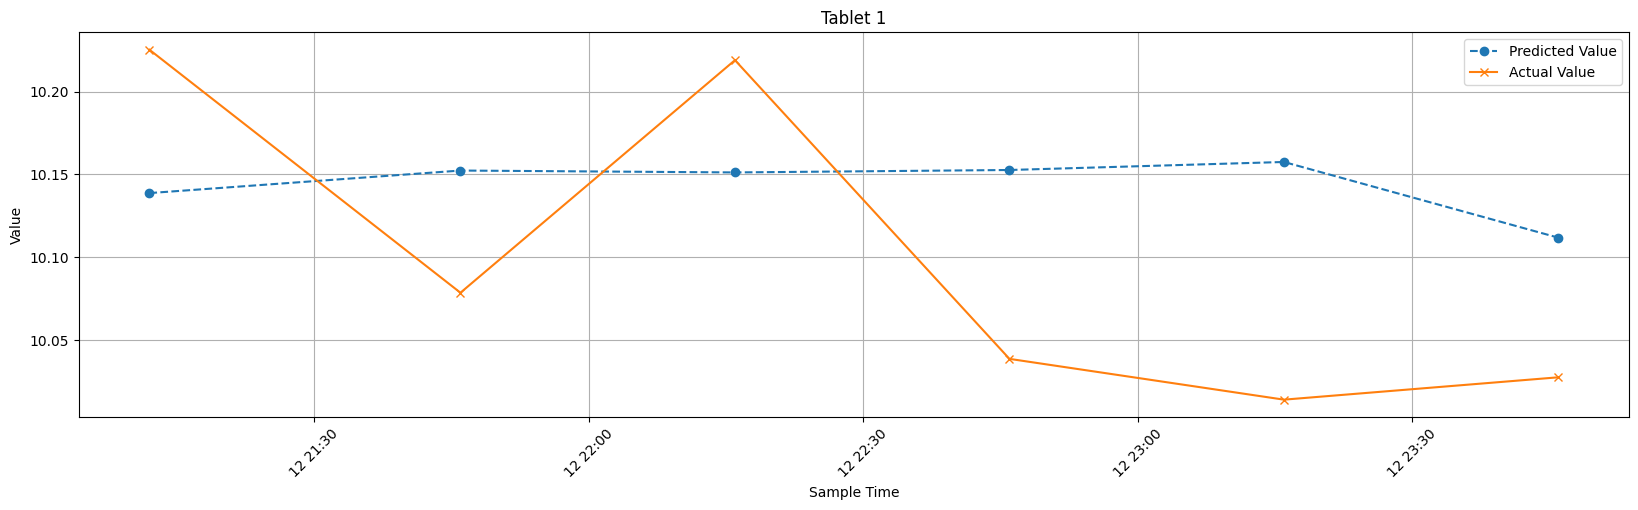

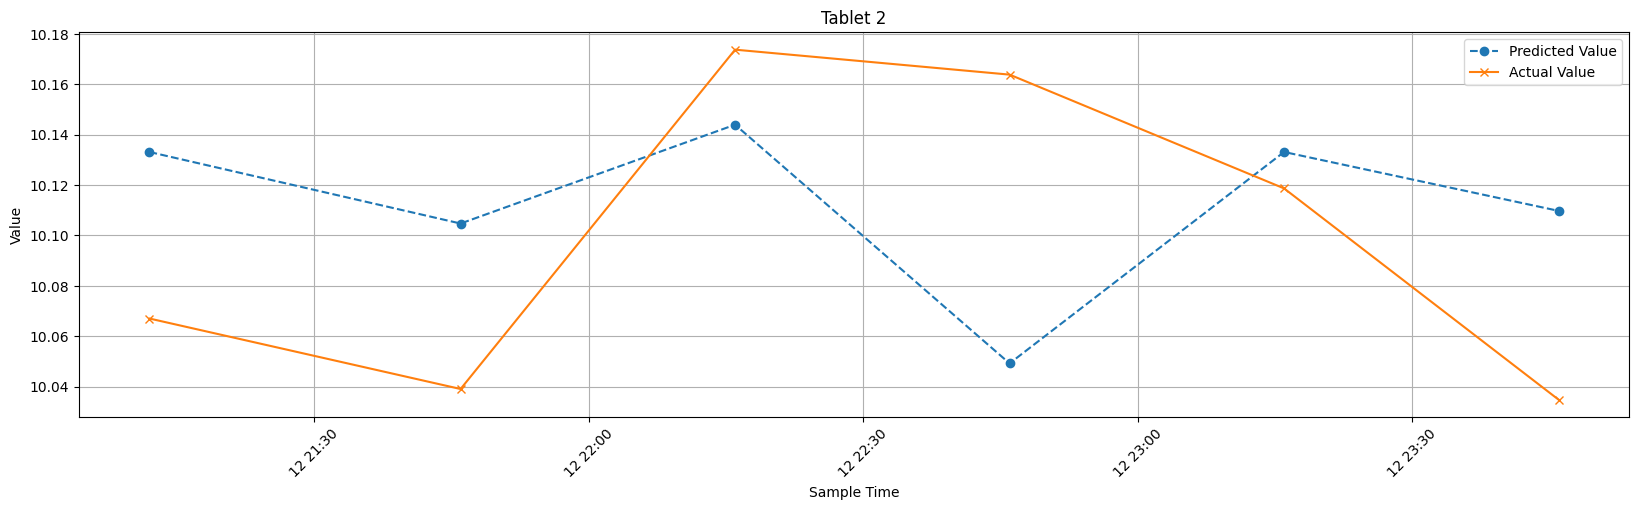

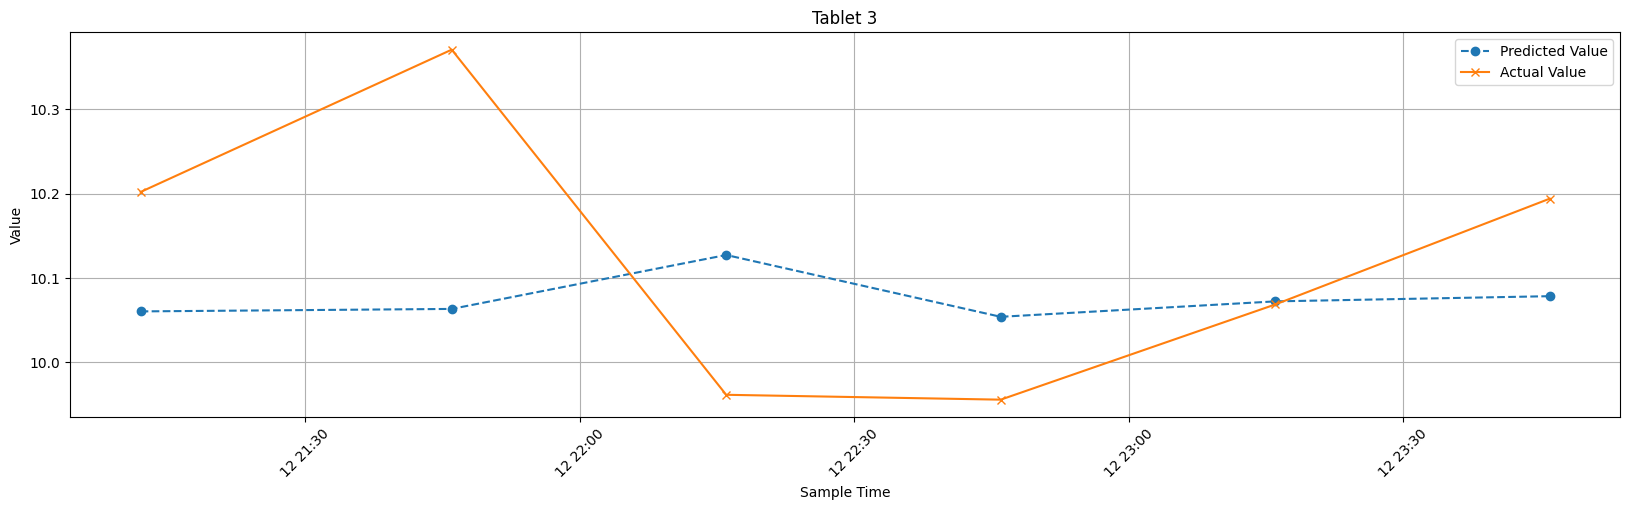

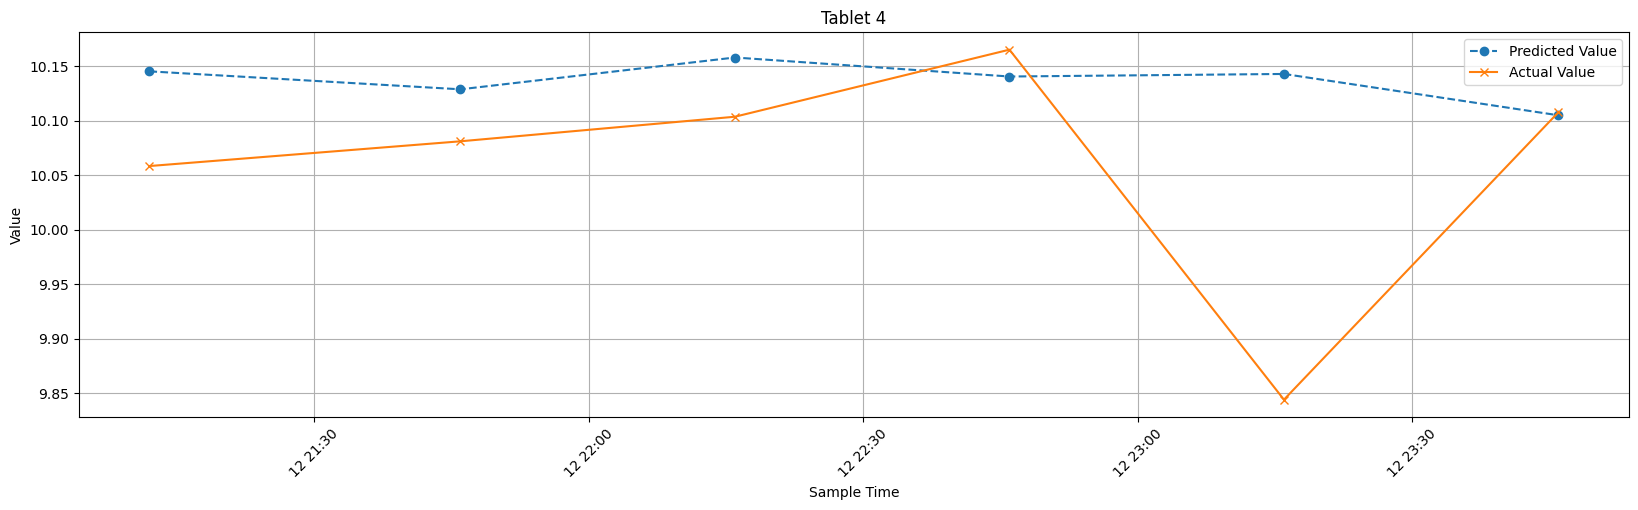

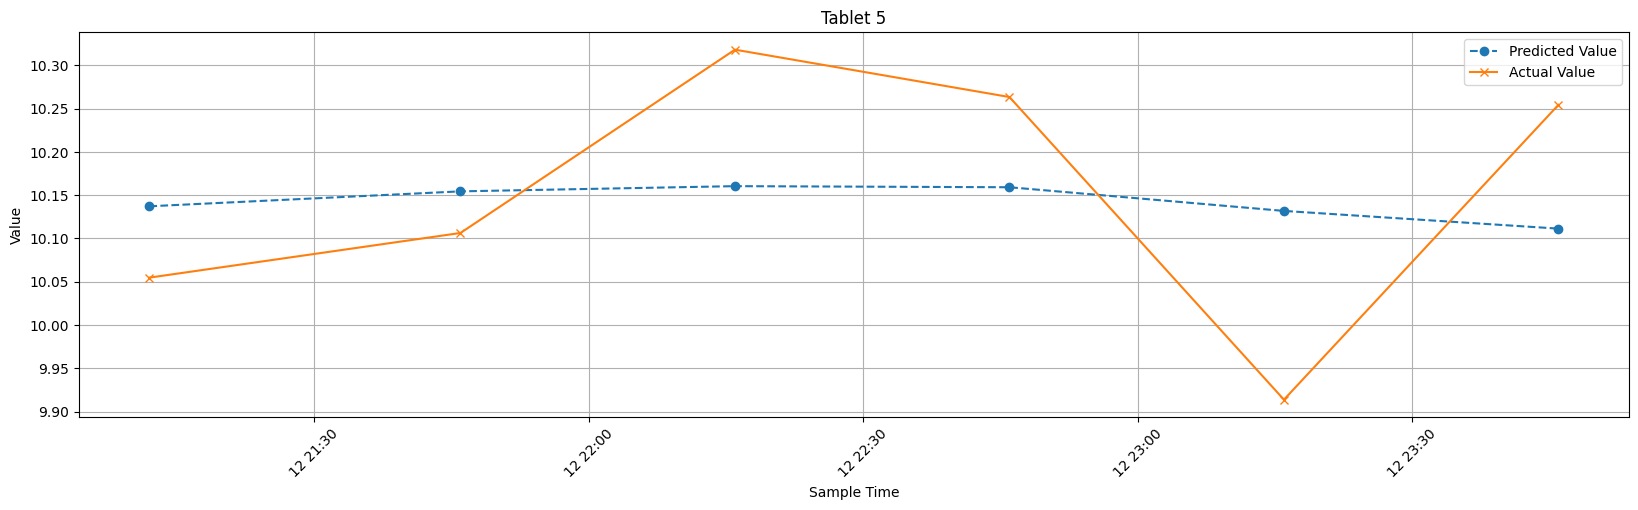

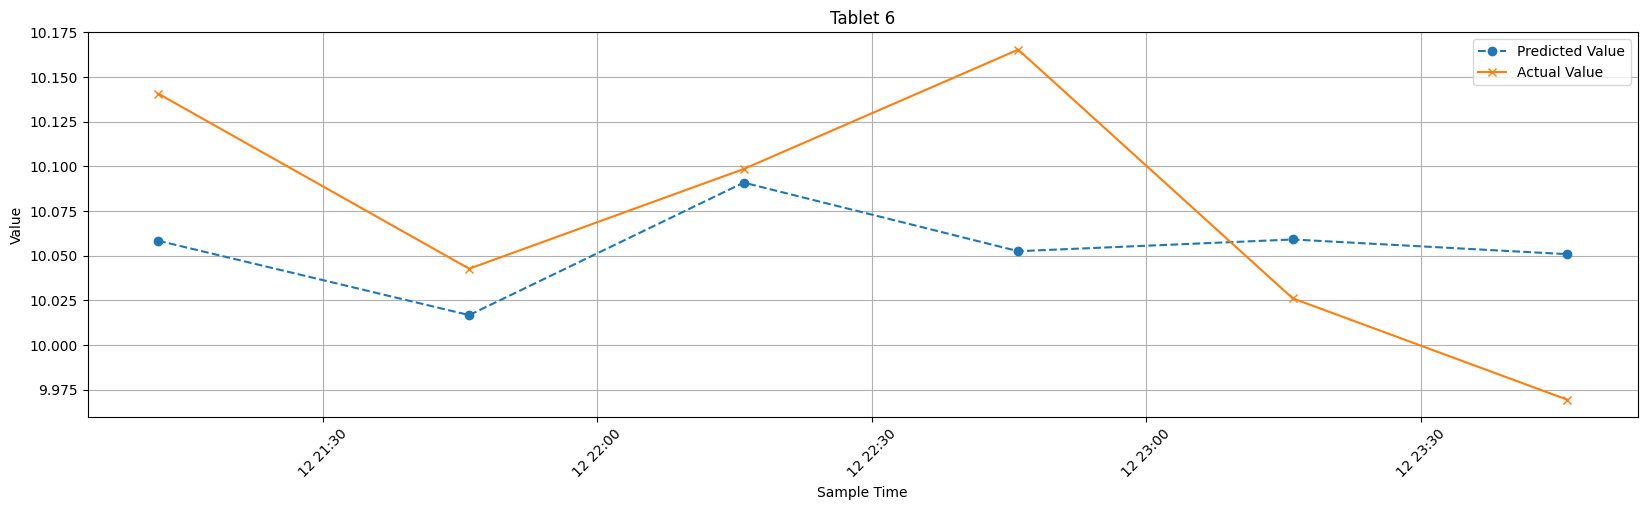

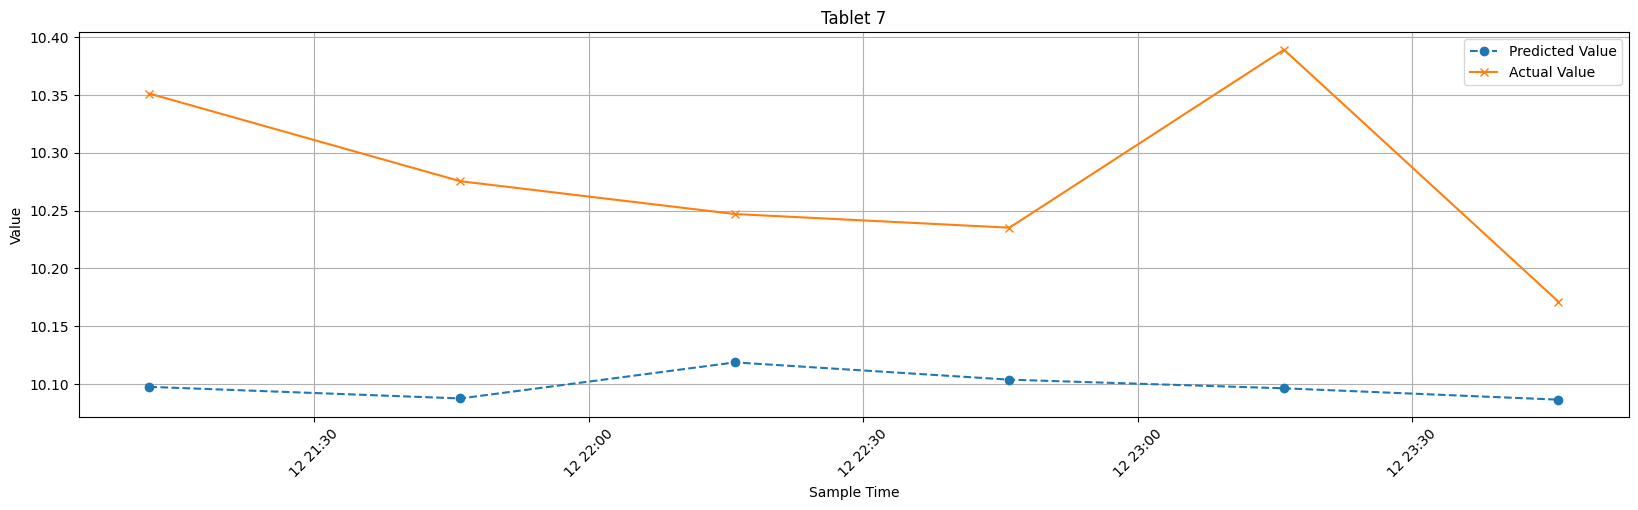

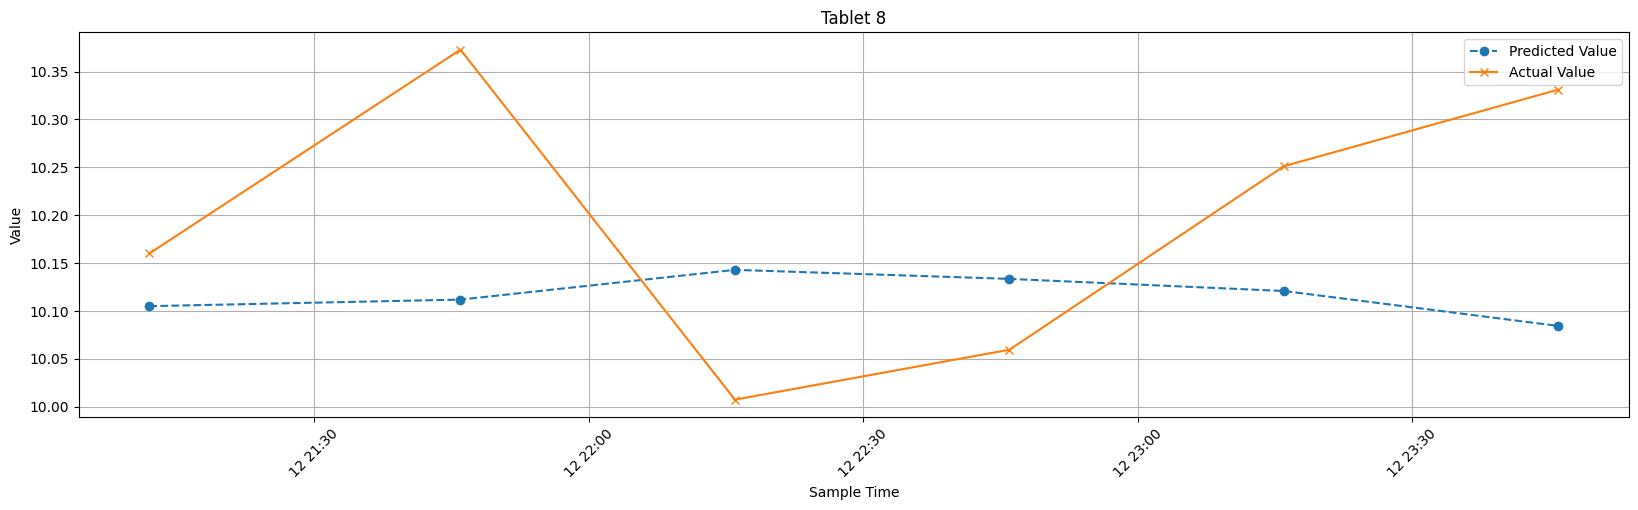

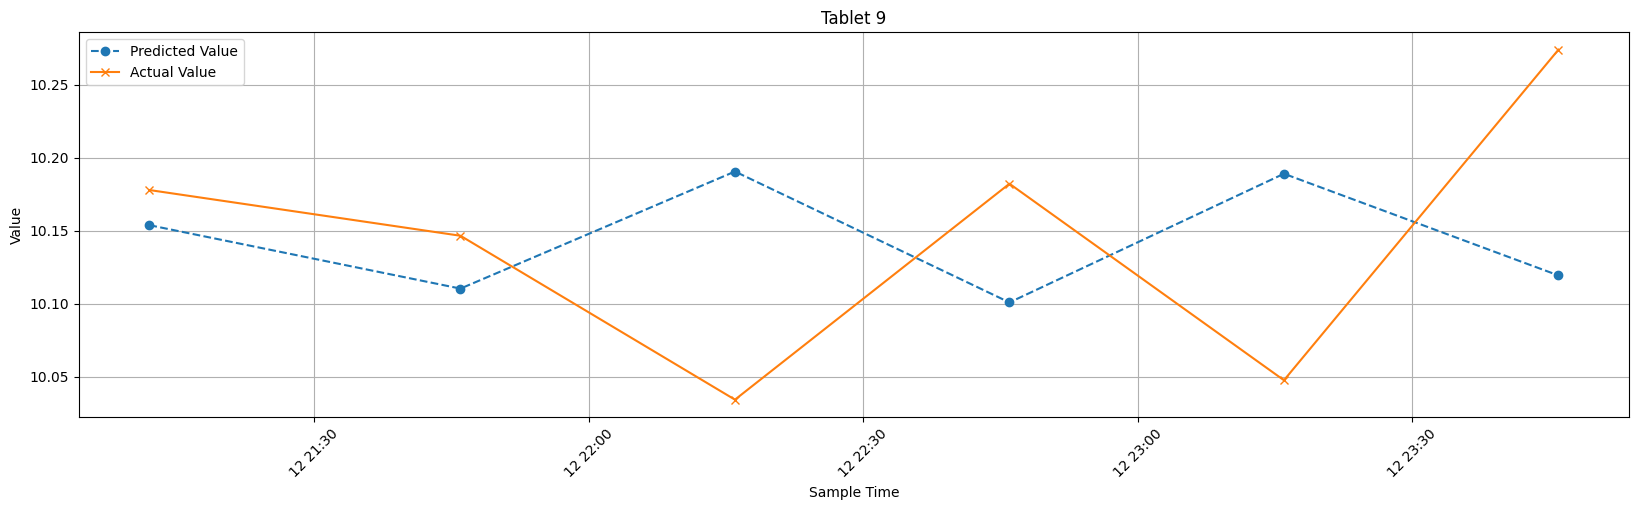

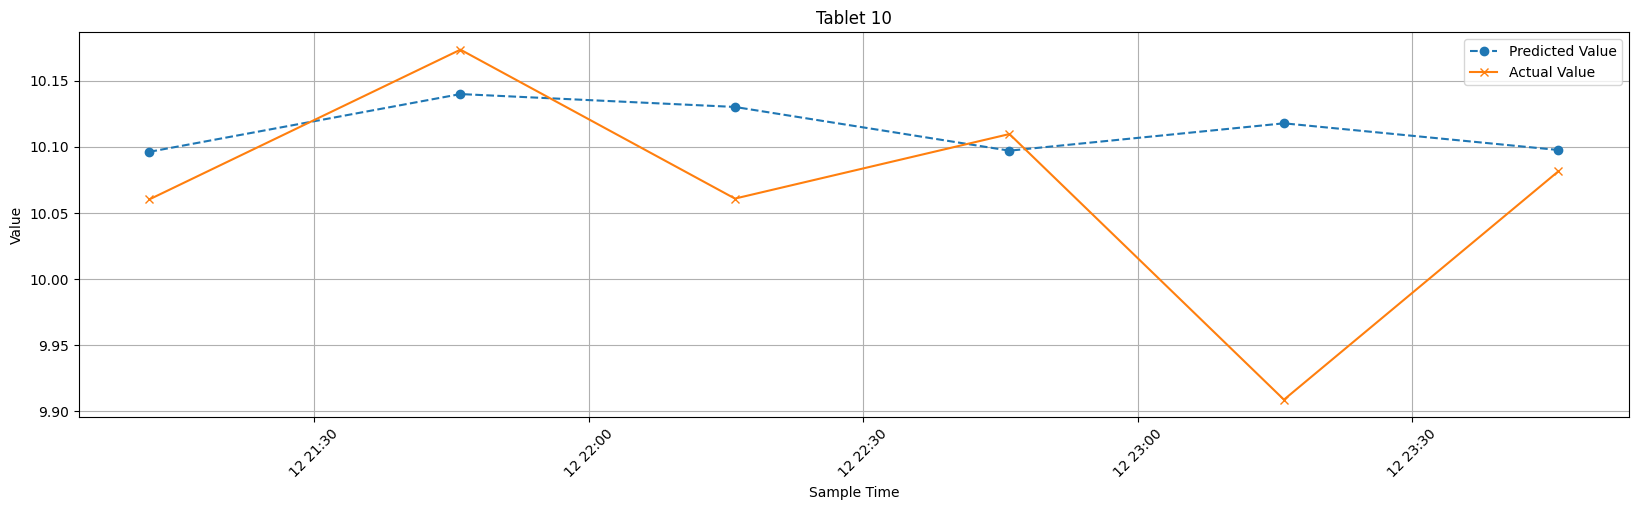

Model saved to ./model/API.pkl


In [136]:
model = TimeSeriesRandomForestRegressor(model_name=f"API", df=result['API'], target=targets, folds=5, n_estimators=100)
model.train()